In [3]:
#All libraries import here
import torch
import torch.nn as nn
import torch.optim as optim
import requests
import json
import pandas as pd
import datetime as dt
import seaborn as sns
import time
from sklearn.preprocessing import MinMaxScaler
import numpy as np
import matplotlib.pyplot as plt
import ray
import torch
import torch.nn as nn
import torch.optim as optim
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import copy
from ray import tune
from ray.tune import CLIReporter
from ray.tune.schedulers import ASHAScheduler
from sklearn.model_selection import train_test_split
from statsmodels.graphics.tsaplots import plot_acf, plot_pacf
from scipy.stats import shapiro, normaltest, jarque_bera
from hurst import compute_Hc
from functools import partial
import statsmodels.api as sm
from statsmodels.stats.diagnostic import acorr_ljungbox, het_arch
from scipy.stats import normaltest
import optuna
from optuna.samplers import TPESampler
import matplotlib.pyplot as plt
import matplotlib.dates as mdates
import random
import time
from scipy.optimize import curve_fit
from scipy.special import expit

import matplotlib.dates as mdates
from matplotlib.patches import Patch
from matplotlib.lines import Line2D


In [4]:
df = pd.read_csv('BTCUSDT_full_features.csv', index_col='Date', parse_dates=True)
df

,log_return,ETH_LogReturns,Volatility,RSI_14,ATR_14,blocksize,cost_per_transaction,difficulty,hash_rate,n_payments_per_block,n_transactions_per_block,n_transactions_total,avgblocksize
Date,,,,,,,,,,,,,
2018-01-16,-0.216880,0.425497,0.468509,0.305204,0.316867,0.000000,0.301796,0.000000,0.001913,0.262038,0.229748,0.000000,0.295511
2018-01-17,0.008113,0.716421,0.188175,0.295717,0.334373,0.000286,0.264873,0.000000,0.002600,0.253494,0.225611,0.000288,0.301318
2018-01-18,-0.002444,0.709120,0.047973,0.286157,0.335334,0.000590,0.306980,0.000000,0.003115,0.233811,0.203865,0.000588,0.295890
2018-01-19,0.045737,0.762522,0.048095,0.186188,0.321884,0.000902,0.364494,0.000000,0.002428,0.158291,0.137143,0.000882,0.294700
2018-01-20,0.109271,0.850073,0.054298,0.275093,0.328421,0.001198,0.423503,0.000000,0.003544,0.129746,0.110513,0.001112,0.322508
...,...,...,...,...,...,...,...,...,...,...,...,...,...
2026-04-22,0.023845,0.740642,0.005239,0.676593,0.409602,0.998542,0.147500,0.867455,0.672572,0.540845,0.706638,0.997949,0.551124
2026-04-23,0.001013,0.693824,0.001336,0.665020,0.398095,0.998898,0.169929,0.867455,0.620335,0.510756,0.617384,0.998461,0.533958
2026-04-24,-0.010538,0.708445,0.000785,0.609541,0.389963,0.999219,0.157646,0.867455,0.766599,0.525360,0.666746,0.998889,0.543127


In [13]:
# Train/Val/Test split 70/15/15
train_size = int(len(df) * 0.70)
val_size = int(len(df) * 0.15)
test_size = len(df) - train_size - val_size

train_df = df.iloc[:train_size]
val_df = df.iloc[train_size:train_size + val_size]
test_df = df.iloc[train_size + val_size:]

print(f"Train: {train_df.index[0].date()} to {train_df.index[-1].date()} ({len(train_df)} rows)")
print(f"Val:   {val_df.index[0].date()} to {val_df.index[-1].date()} ({len(val_df)} rows)")
print(f"Test:  {test_df.index[0].date()} to {test_df.index[-1].date()} ({len(test_df)} rows)")


Train: 2018-01-16 to 2023-11-01 (2116 rows)
Val:   2023-11-02 to 2025-01-27 (453 rows)
Test:  2025-01-28 to 2026-04-26 (454 rows)


In [15]:
def hybrid_qrnn_loss(y, q_hybrid, sigma_al, alpha):
    """
    Hybrid QRNN ALD NLL Loss
    y        : observed returns (tensor), shape (T,)
    q_hybrid : hybrid quantile estimate (tensor), shape (T,)
    sigma_al : scale parameter (scalar tensor)
    alpha    : quantile level in (0,1)
    """
    u = y - q_hybrid
    indicator  = (u < 0).float()
    rho_alpha  = u * (alpha - indicator)
    nll = (- torch.log(torch.tensor(alpha * (1 - alpha), dtype=torch.float32))
           + torch.log(sigma_al)
           + rho_alpha / sigma_al)
    return nll.mean()


def compute_hybrid_quantile_location_self_a(y, X, beta1, beta2, beta3, fnn_model, psi):
    """
    Self-lagged hybrid QRNN location -- A (asymmetric) functional form.
    The CaViaR component uses the previous pure CaViaR output as its autoregressive input.
    A form: q_t = beta1 * q_{t-1}^S + beta2 * y_{t-1}^+ + beta3 * y_{t-1}^-
    y      : raw log returns (T,)
    X      : normalised features (T, input_dim)
    beta1  : quantile persistence, constrained to (0,1)
    beta2  : positive return impact, constrained to >=0
    beta3  : negative return impact, constrained to >=0
    psi    : mixing weight, constrained to (0,1)
    fnn_model : FNN correction network
    """
    T = len(y)
    fnn_out = fnn_model(X).squeeze(-1)

    q_caviar_list = [torch.zeros(1)]
    q_hybrid_list = [torch.zeros(1)]

    for t in range(1, T):
        # CaViaR component -- A self-lagged: uses previous pure CaViaR output
        y_pos    = torch.clamp(y[t-1],  min=0)   # y^+
        y_neg    = torch.clamp(-y[t-1], min=0)   # y^-
        caviar_t = (beta1 * q_caviar_list[t-1]   # self-lagged
                  + beta2 * y_pos
                  + beta3 * y_neg)
        q_caviar_list.append(caviar_t)

        # Hybrid combination
        hybrid_t = psi * caviar_t + (1 - psi) * fnn_out[t]
        q_hybrid_list.append(hybrid_t)

    q_caviar = torch.stack(q_caviar_list).squeeze(-1)
    q_hybrid = torch.stack(q_hybrid_list).squeeze(-1)

    return q_hybrid, q_caviar

In [17]:
# Feature columns for FNN input
feature_cols = ['Volatility', 'RSI_14', 'ATR_14', 'ETH_LogReturns',
                'blocksize', 'cost_per_transaction', 'difficulty',
                'hash_rate', 'n_payments_per_block',
                'n_transactions_per_block', 'n_transactions_total',
                'avgblocksize']

# Convert to tensors
y_train = torch.tensor(train_df['log_return'].values, dtype=torch.float32)
y_val = torch.tensor(val_df['log_return'].values, dtype=torch.float32)
X_train = torch.tensor(train_df[feature_cols].values, dtype=torch.float32)
X_val = torch.tensor(val_df[feature_cols].values, dtype=torch.float32)

# Tuning

In [12]:
class HybridQRNN_A(nn.Module):
    def __init__(self, input_dim, config):
        super().__init__()

        # Fixed initialisations -- estimated during training, not tuned by Optuna
        self.beta1_raw = nn.Parameter(torch.tensor(1.386))   # sigmoid → 0.80
        self.beta2_raw = nn.Parameter(torch.tensor(0.3))     # y^+ impact
        self.beta3_raw = nn.Parameter(torch.tensor(0.3))     # y^- impact
        self.psi_raw   = nn.Parameter(torch.tensor(0.0))     # sigmoid → 0.50
        self.sigma_raw = nn.Parameter(torch.tensor(0.5))

        # Build FNN
        layers = []
        prev_dim = input_dim
        n_hidden = config['n_hidden_layers']

        for i in range(n_hidden):
            hidden_dim = config[f'hidden_dim_{i}']
            layers.append(nn.Linear(prev_dim, hidden_dim))
            if config['layernorm']:
                layers.append(nn.LayerNorm(hidden_dim))
            layers.append(self._get_activation(config['activation']))
            if config['dropout'] > 0:
                layers.append(nn.Dropout(config['dropout']))
            prev_dim = hidden_dim

        layers.append(nn.Linear(prev_dim, 1))
        self.fnn = nn.Sequential(*layers)

        for m in self.fnn.modules():
            if isinstance(m, nn.Linear):
                if config['weight_init'] == 'glorot':
                    nn.init.xavier_uniform_(m.weight)
                elif config['weight_init'] == 'he':
                    nn.init.kaiming_uniform_(m.weight)
                if m.bias is not None:
                    nn.init.zeros_(m.bias)

    def _get_activation(self, name):
        return {
            'relu': nn.ReLU(),
            'elu': nn.ELU(),
            'gelu': nn.GELU(),
            'tanh': nn.Tanh()
        }.get(name, nn.ReLU())

    def forward(self, y, X):
        beta1 = torch.sigmoid(self.beta1_raw)
        beta2 = torch.nn.functional.softplus(self.beta2_raw)
        beta3 = torch.nn.functional.softplus(self.beta3_raw)
        psi   = torch.sigmoid(self.psi_raw)
        sigma = torch.nn.functional.softplus(self.sigma_raw)

        # self-lagged A: uses previous pure CaViaR output
        q_hybrid, q_caviar = compute_hybrid_quantile_location_self_a(
            y, X, beta1, beta2, beta3, self.fnn, psi)

        return q_hybrid, sigma


def compute_crp(y, q, alpha):
    if alpha <= 0.5:
        empirical  = (y <= q).float().mean().item()
        alpha_star = alpha
    else:
        empirical  = (y > q).float().mean().item()
        alpha_star = 1.0 - alpha

    crp     = empirical / alpha_star
    penalty = (crp - 1.0) ** 2
    return crp, penalty


def objective_qrnn(trial, alpha):
    config = {
        'n_hidden_layers': trial.suggest_int('n_hidden_layers', 1, 3),
        'activation':      trial.suggest_categorical('activation', ['relu', 'elu', 'gelu', 'tanh']),
        'dropout':         trial.suggest_float('dropout', 0.0, 0.5),
        'layernorm':       trial.suggest_categorical('layernorm', [True, False]),
        'weight_init':     trial.suggest_categorical('weight_init', ['glorot', 'he']),
        'lr':              trial.suggest_float('lr', 1e-4, 5e-2, log=True),
        'optimizer':       trial.suggest_categorical('optimizer', ['adam', 'adamw']),
        'batch_size':      trial.suggest_categorical('batch_size', [32, 64, 128]),
        'weight_decay':    trial.suggest_float('weight_decay', 0.0, 1e-4),
        'gradient_clip':   trial.suggest_categorical('gradient_clip', [0.1, 1.0, 5.0]),
        'patience':        trial.suggest_categorical('patience', [10, 20, 30]),
    }

    for i in range(config['n_hidden_layers']):
        config[f'hidden_dim_{i}'] = trial.suggest_int(f'hidden_dim_{i}', 32, 256)

    input_dim = X_train.shape[1]
    torch.manual_seed(2026)
    model = HybridQRNN_A(input_dim, config)

    if config['optimizer'] == 'adam':
        optimizer = torch.optim.Adam(model.parameters(), lr=config['lr'],
                                     weight_decay=config['weight_decay'])
    else:
        optimizer = torch.optim.AdamW(model.parameters(), lr=config['lr'],
                                      weight_decay=config['weight_decay'])

    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode='min', patience=10, factor=0.5, min_lr=1e-6)

    best_val_loss    = float('inf')
    patience_counter = 0
    patience         = config['patience']
    max_epochs       = 200
    best_model_state = None

    for epoch in range(max_epochs):
        model.train()
        optimizer.zero_grad()
        q_hybrid, sigma = model(y_train, X_train)
        loss = hybrid_qrnn_loss(y_train, q_hybrid, sigma, alpha)

        if torch.isnan(loss) or torch.isinf(loss):
            return float('inf')

        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), config['gradient_clip'])
        optimizer.step()

        model.eval()
        with torch.no_grad():
            q_val, sigma_val = model(y_val, X_val)
            val_loss = hybrid_qrnn_loss(y_val, q_val, sigma_val, alpha)

        scheduler.step(val_loss)

        if val_loss < best_val_loss:
            best_val_loss    = val_loss.item()
            patience_counter = 0
            best_model_state = {k: v.clone() for k, v in model.state_dict().items()}
        else:
            patience_counter += 1
            if patience_counter >= patience:
                break

    if best_model_state is not None:
        model.load_state_dict(best_model_state)

    with torch.no_grad():
        q_val, sigma_val = model(y_val, X_val)
        val_loss         = hybrid_qrnn_loss(y_val, q_val, sigma_val, alpha)
        crp, crp_penalty = compute_crp(y_val, q_val, alpha)

        beta1 = torch.sigmoid(model.beta1_raw).item()
        beta2 = torch.nn.functional.softplus(model.beta2_raw).item()
        beta3 = torch.nn.functional.softplus(model.beta3_raw).item()
        psi   = torch.sigmoid(model.psi_raw).item()
        sigma = torch.nn.functional.softplus(model.sigma_raw).item()

    trial.set_user_attr('nll',         val_loss.item())
    trial.set_user_attr('crp',         crp)
    trial.set_user_attr('crp_penalty', crp_penalty)
    trial.set_user_attr('beta1',       beta1)
    trial.set_user_attr('beta2',       beta2)
    trial.set_user_attr('beta3',       beta3)
    trial.set_user_attr('psi',         psi)
    trial.set_user_attr('sigma',       sigma)

    print(f"  Trial {trial.number}: "
          f"NLL={val_loss.item():.4f} | "
          f"CRP={crp:.4f} | "
          f"CRP_penalty={crp_penalty:.4f} | "
          f"alpha={alpha} | lr={config['lr']:.5f} | "
          f"layers={config['n_hidden_layers']} | "
          f"activation={config['activation']} | "
          f"dropout={config['dropout']:.3f} | "
          f"psi={psi:.4f} | sigma={sigma:.4f} | "
          f"beta1={beta1:.4f} | beta2={beta2:.4f} | beta3={beta3:.4f}")

    return val_loss.item()


def select_best_trial_by_rank(study):
    trials = [t for t in study.trials
              if t.state == optuna.trial.TrialState.COMPLETE
              and t.value != float('inf')]

    for t in trials:
        t._nll         = t.user_attrs['nll']
        t._crp_penalty = t.user_attrs['crp_penalty']

    for rank, t in enumerate(sorted(trials, key=lambda t: t._nll), start=1):
        t._rank_nll = rank

    for rank, t in enumerate(sorted(trials, key=lambda t: t._crp_penalty), start=1):
        t._rank_crp = rank

    best = min(trials, key=lambda t: (
        t._rank_nll + t._rank_crp,
        t._nll,
        t._crp_penalty,
        t.number
    ))

    return best, trials


# -------------------------
# Run tuning for each alpha level
# -------------------------
alpha_levels              = [0.025, 0.050, 0.250, 0.500, 0.750, 0.950, 0.975]
base_seed                 = 2026
best_configs_qrnn_a_self  = {}  # distinct name for QRNN A self-lagged

for i, alpha in enumerate(alpha_levels):
    print(f"\n{'='*60}")
    print(f"Tuning QRNN A Self-lagged for alpha = {alpha} (seed = {base_seed + i})")
    print(f"{'='*60}")

    sampler = TPESampler(seed=base_seed + i)
    study   = optuna.create_study(direction='minimize', sampler=sampler)
    study.optimize(lambda trial, a=alpha: objective_qrnn(trial, alpha=a),
                   n_trials=200, show_progress_bar=True)

    best_trial, all_trials = select_best_trial_by_rank(study)

    print(f"\nRanking summary for alpha={alpha}:")
    print(f"  {'Trial':>6} {'NLL':>8} {'NLL_rank':>9} {'CRP_pen':>9} {'CRP_rank':>9} {'Sum_rank':>9}")
    sorted_trials = sorted(all_trials, key=lambda t: t._rank_nll + t._rank_crp)
    for t in sorted_trials[:10]:
        print(f"  {t.number:>6} {t._nll:>8.4f} {t._rank_nll:>9} "
              f"{t._crp_penalty:>9.4f} {t._rank_crp:>9} "
              f"{t._rank_nll + t._rank_crp:>9}")

    # save full ranking to CSV
    ranking_records = []
    for t in all_trials:
        record = {
            'alpha':       alpha,
            'trial':       t.number,
            'nll':         t._nll,
            'crp':         t.user_attrs['crp'],
            'crp_penalty': t._crp_penalty,
            'rank_nll':    t._rank_nll,
            'rank_crp':    t._rank_crp,
            'sum_rank':    t._rank_nll + t._rank_crp,
            'beta1':       t.user_attrs['beta1'],
            'beta2':       t.user_attrs['beta2'],
            'beta3':       t.user_attrs['beta3'],
            'psi':         t.user_attrs['psi'],
            'sigma':       t.user_attrs['sigma'],
        }
        record.update(t.params)
        ranking_records.append(record)

    ranking_df = pd.DataFrame(ranking_records)
    ranking_df = ranking_df.sort_values('sum_rank')
    ranking_df.to_csv(f'qrnn_a_self_ranking_alpha_{alpha}.csv', index=False)
    print(f"  Full ranking saved to qrnn_a_self_ranking_alpha_{alpha}.csv")

    best_configs_qrnn_a_self[alpha] = best_trial.params.copy()
    best_configs_qrnn_a_self[alpha]['alpha'] = alpha

    # re-run best config to extract estimated parameters
    torch.manual_seed(2026)
    best_model = HybridQRNN_A(X_train.shape[1], best_configs_qrnn_a_self[alpha])

    if best_configs_qrnn_a_self[alpha]['optimizer'] == 'adam':
        optimizer = torch.optim.Adam(best_model.parameters(),
                                     lr=best_configs_qrnn_a_self[alpha]['lr'],
                                     weight_decay=best_configs_qrnn_a_self[alpha]['weight_decay'])
    else:
        optimizer = torch.optim.AdamW(best_model.parameters(),
                                      lr=best_configs_qrnn_a_self[alpha]['lr'],
                                      weight_decay=best_configs_qrnn_a_self[alpha]['weight_decay'])

    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode='min', patience=10, factor=0.5, min_lr=1e-6)

    best_val_loss    = float('inf')
    patience_counter = 0
    best_model_state = None

    for epoch in range(200):
        best_model.train()
        optimizer.zero_grad()
        q_hybrid, sigma = best_model(y_train, X_train)
        loss = hybrid_qrnn_loss(y_train, q_hybrid, sigma, alpha)
        if torch.isnan(loss) or torch.isinf(loss):
            break
        loss.backward()
        nn.utils.clip_grad_norm_(best_model.parameters(),
                                  best_configs_qrnn_a_self[alpha]['gradient_clip'])
        optimizer.step()

        best_model.eval()
        with torch.no_grad():
            q_val, sigma_val = best_model(y_val, X_val)
            val_loss = hybrid_qrnn_loss(y_val, q_val, sigma_val, alpha)
        scheduler.step(val_loss)

        if val_loss < best_val_loss:
            best_val_loss    = val_loss.item()
            patience_counter = 0
            best_model_state = {k: v.clone() for k, v in best_model.state_dict().items()}
        else:
            patience_counter += 1
            if patience_counter >= best_configs_qrnn_a_self[alpha].get('patience', 20):
                break

    if best_model_state is not None:
        best_model.load_state_dict(best_model_state)

    with torch.no_grad():
        q_val_final, sigma_val_final = best_model(y_val, X_val)
        final_nll                    = hybrid_qrnn_loss(y_val, q_val_final, sigma_val_final, alpha).item()
        final_crp, final_crp_penalty = compute_crp(y_val, q_val_final, alpha)

        est_beta1 = torch.sigmoid(best_model.beta1_raw).item()
        est_beta2 = torch.nn.functional.softplus(best_model.beta2_raw).item()
        est_beta3 = torch.nn.functional.softplus(best_model.beta3_raw).item()
        est_psi   = torch.sigmoid(best_model.psi_raw).item()
        est_sigma = torch.nn.functional.softplus(best_model.sigma_raw).item()

    best_configs_qrnn_a_self[alpha]['est_psi']   = est_psi
    best_configs_qrnn_a_self[alpha]['est_sigma']  = est_sigma
    best_configs_qrnn_a_self[alpha]['est_beta1']  = est_beta1
    best_configs_qrnn_a_self[alpha]['est_beta2']  = est_beta2
    best_configs_qrnn_a_self[alpha]['est_beta3']  = est_beta3
    best_configs_qrnn_a_self[alpha]['est_crp']    = final_crp

    print(f"\nBest trial (rank-based): #{best_trial.number}")
    print(f"  NLL rank: {best_trial._rank_nll} | CRP rank: {best_trial._rank_crp} | "
          f"Sum: {best_trial._rank_nll + best_trial._rank_crp}")
    print(f"Final NLL:          {final_nll:.4f}")
    print(f"Final CRP:          {final_crp:.4f}")
    print(f"Final CRP penalty:  {final_crp_penalty:.4f}")
    print(f"Best params: {best_trial.params}")
    print(f"Estimated psi:   {est_psi:.4f}")
    print(f"Estimated sigma: {est_sigma:.4f}")
    print(f"Estimated beta1: {est_beta1:.4f}")
    print(f"Estimated beta2: {est_beta2:.4f}")
    print(f"Estimated beta3: {est_beta3:.4f}")

print("\n" + "="*60)
print("TUNING COMPLETE -- QRNN A SELF-LAGGED")
print("="*60)
for alpha, config in best_configs_qrnn_a_self.items():
    print(f"alpha={alpha}: {config}")

[I 2026-07-13 23:09:30,234] A new study created in memory with name: no-name-791442eb-98de-45fa-8c39-cb804113cdae



Tuning QRNN A Self-lagged for alpha = 0.025 (seed = 2026)


  0%|          | 0/200 [00:00<?, ?it/s]

  Trial 0: NLL=3.6923 | CRP=0.1766 | CRP_penalty=0.6780 | alpha=0.025 | lr=0.00066 | layers=1 | activation=elu | dropout=0.494 | psi=0.5002 | sigma=0.9737 | beta1=0.7998 | beta2=0.8540 | beta3=0.8540
[I 2026-07-13 23:09:34,351] Trial 0 finished with value: 3.6923327445983887 and parameters: {'n_hidden_layers': 1, 'activation': 'elu', 'dropout': 0.49377524711883497, 'layernorm': False, 'weight_init': 'he', 'lr': 0.0006552020421842752, 'optimizer': 'adam', 'batch_size': 32, 'weight_decay': 5.618938892024055e-05, 'gradient_clip': 5.0, 'patience': 30, 'hidden_dim_0': 176}. Best is trial 0 with value: 3.6923327445983887.
  Trial 1: NLL=3.6977 | CRP=0.0883 | CRP_penalty=0.8312 | alpha=0.025 | lr=0.00050 | layers=1 | activation=relu | dropout=0.341 | psi=0.5001 | sigma=0.9738 | beta1=0.7999 | beta2=0.8541 | beta3=0.8541
[I 2026-07-13 23:09:37,640] Trial 1 finished with value: 3.6977035999298096 and parameters: {'n_hidden_layers': 1, 'activation': 'relu', 'dropout': 0.3412887415864622, 'layern

[I 2026-07-14 00:13:14,151] A new study created in memory with name: no-name-c6d65322-7439-4941-9da3-fc22cea260c3


...

  Trial 0: NLL=1.8948 | CRP=0.0000 | CRP_penalty=1.0000 | alpha=0.95 | lr=0.00703 | layers=2 | activation=tanh | dropout=0.112 | psi=0.5483 | sigma=0.3125 | beta1=0.7638 | beta2=0.6414 | beta3=0.6899
[I 2026-07-14 12:10:49,304] Trial 0 finished with value: 1.894776701927185 and parameters: {'n_hidden_layers': 2, 'activation': 'tanh', 'dropout': 0.11155263989652436, 'layernorm': False, 'weight_init': 'glorot', 'lr': 0.007027131382827591, 'optimizer': 'adam', 'batch_size': 64, 'weight_decay': 3.1297438535544123e-06, 'gradient_clip': 1.0, 'patience': 10, 'hidden_dim_0': 187, 'hidden_dim_1': 217}. Best is trial 0 with value: 1.894776701927185.
  Trial 1: NLL=2.1824 | CRP=0.1766 | CRP_penalty=0.6780 | alpha=0.95 | lr=0.00544 | layers=2 | activation=tanh | dropout=0.041 | psi=0.5264 | sigma=0.4189 | beta1=0.7771 | beta2=0.7181 | beta3=0.7420
[I 2026-07-14 12:11:08,946] Trial 1 finished with value: 2.1824450492858887 and parameters: {'n_hidden_layers': 2, 'activation': 'tanh', 'dropout': 0.04

[I 2026-07-14 15:04:20,817] A new study created in memory with name: no-name-f82bf008-5c1a-4dee-bf9a-c8e9e5c4cd64



Best trial (rank-based): #183
  NLL rank: 4 | CRP rank: 8 | Sum: 12
Final NLL:          -2.3434
Final CRP:          0.9713
Final CRP penalty:  0.0008
Best params: {'n_hidden_layers': 1, 'activation': 'tanh', 'dropout': 0.40695549290720623, 'layernorm': False, 'weight_init': 'he', 'lr': 0.04564889781956726, 'optimizer': 'adam', 'batch_size': 128, 'weight_decay': 5.762435347013839e-06, 'gradient_clip': 1.0, 'patience': 20, 'hidden_dim_0': 66}
Estimated psi:   0.9609
Estimated sigma: 0.0023
Estimated beta1: 0.6974
Estimated beta2: 0.0627
Estimated beta3: 0.0967

Tuning QRNN A Self-lagged for alpha = 0.975 (seed = 2032)


  0%|          | 0/200 [00:00<?, ?it/s]

  Trial 0: NLL=2.4815 | CRP=0.0000 | CRP_penalty=1.0000 | alpha=0.975 | lr=0.00741 | layers=3 | activation=relu | dropout=0.111 | psi=0.5235 | sigma=0.2899 | beta1=0.7450 | beta2=0.6127 | beta3=0.6393
[I 2026-07-14 15:13:09,960] Trial 0 finished with value: 2.4814820289611816 and parameters: {'n_hidden_layers': 3, 'activation': 'relu', 'dropout': 0.11110238679748752, 'layernorm': False, 'weight_init': 'he', 'lr': 0.007412946243424984, 'optimizer': 'adam', 'batch_size': 128, 'weight_decay': 7.766054095562223e-05, 'gradient_clip': 1.0, 'patience': 20, 'hidden_dim_0': 195, 'hidden_dim_1': 201, 'hidden_dim_2': 229}. Best is trial 0 with value: 2.4814820289611816.
  Trial 1: NLL=3.6754 | CRP=0.0000 | CRP_penalty=1.0000 | alpha=0.975 | lr=0.00011 | layers=1 | activation=elu | dropout=0.061 | psi=0.5022 | sigma=0.9562 | beta1=0.8011 | beta2=0.8579 | beta3=0.8588
[I 2026-07-14 15:13:35,094] Trial 1 finished with value: 3.6754229068756104 and parameters: {'n_hidden_layers': 1, 'activation': 'el


Training final model for alpha = 0.025 (A self-lagged)
  Epoch 50: train=1.5987, val=1.5423
  Epoch 100: train=-0.8373, val=-0.8568
  Epoch 150: train=-1.9828, val=-2.0328
  Epoch 200: train=-2.0587, val=-2.2068
  Test loss: -2.3416 | Coverage ratio: 0.176 | beta1=0.3247 | beta2=0.0359 | beta3=0.0923 | psi=0.9517 | sigma=0.0013

Training final model for alpha = 0.05 (A self-lagged)
  Epoch 50: train=0.9295, val=0.8646
  Epoch 100: train=-1.4186, val=-1.4487
  Epoch 150: train=-2.0490, val=-2.2262
  Epoch 200: train=-2.1866, val=-2.3174
  Test loss: -2.5454 | Coverage ratio: 0.573 | beta1=0.3603 | beta2=0.0335 | beta3=0.1002 | psi=0.9434 | sigma=0.0021

Training final model for alpha = 0.25 (A self-lagged)
  Epoch 50: train=0.1368, val=0.0804
  Epoch 100: train=-1.5485, val=-1.6010
  Epoch 150: train=-2.1691, val=-2.3448
  Epoch 200: train=-2.3995, val=-2.4757
  Test loss: -2.5828 | Coverage ratio: 1.392 | beta1=0.5722 | beta2=0.0756 | beta3=0.2313 | psi=0.7426 | sigma=0.0070

Training

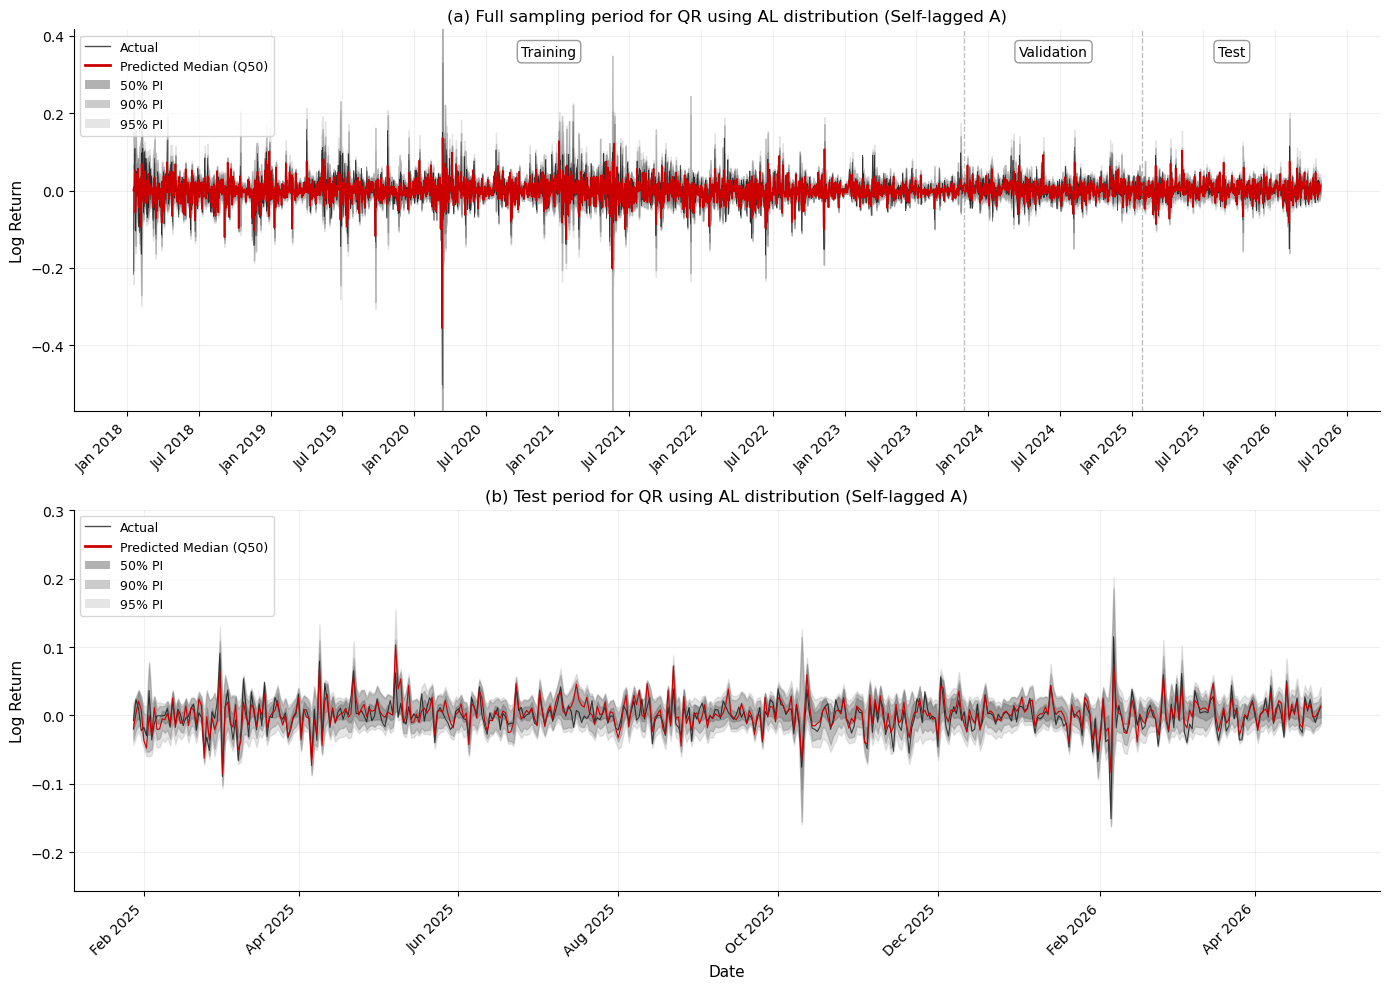

Full period plot saved to hybrid_qrnn_self_a_predictions_full.png
Test period plot saved to hybrid_qrnn_self_a_predictions_test.png

CROSSOVER ANALYSIS -- QRNN Self A (TEST PERIOD, T=454)
              Pair   Violations    Pct (%)
  ------------------------------------------
  (0.025, 0.050):           2      0.44% <-- TAIL
  (0.050, 0.250):           4      0.88%
  (0.250, 0.500):         116     25.55%
  (0.500, 0.750):           4      0.88%
  (0.750, 0.950):          19      4.19%
  (0.950, 0.975):          56     12.33% <-- TAIL
  ------------------------------------------
  Total violations:         201  (7.38% of all pairs)
  Tail violations:           58  (6.39% of tail pairs)

TEST SET METRICS -- QRNN A Self-lagged
   alpha        NLL            HRE
  ----------------------------------
   0.025    -2.3416       0.020595
    0.05    -2.5454       0.021366
    0.25    -2.5828       0.098018
     0.5    -2.8217       0.110132
    0.75    -2.7005       0.144273
    0.95    -2.4092

In [14]:
def train_final_model_qrnn_a(alpha, config, y_train, X_train, y_val, X_val, y_test, X_test):
    torch.manual_seed(2026)
    input_dim = X_train.shape[1]
    model = HybridQRNN_A(input_dim, config)

    if config['optimizer'] == 'adam':
        optimizer = torch.optim.Adam(model.parameters(), lr=config['lr'],
                                     weight_decay=config['weight_decay'])
    else:
        optimizer = torch.optim.AdamW(model.parameters(), lr=config['lr'],
                                      weight_decay=config['weight_decay'])

    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode='min', patience=10, factor=0.5, min_lr=1e-6)

    best_val_loss    = float('inf')
    patience_counter = 0
    patience         = config.get('patience', 30)
    max_epochs       = 200
    best_model_state = None
    train_losses, val_losses = [], []

    for epoch in range(max_epochs):
        model.train()
        optimizer.zero_grad()
        q_hybrid, sigma = model(y_train, X_train)
        loss = hybrid_qrnn_loss(y_train, q_hybrid, sigma, alpha)

        if torch.isnan(loss) or torch.isinf(loss):
            print(f"  NaN/Inf at epoch {epoch}, stopping")
            break

        loss.backward()
        nn.utils.clip_grad_norm_(model.parameters(), config['gradient_clip'])
        optimizer.step()
        train_losses.append(loss.item())

        model.eval()
        with torch.no_grad():
            q_val, sigma_val = model(y_val, X_val)
            val_loss = hybrid_qrnn_loss(y_val, q_val, sigma_val, alpha)

        val_losses.append(val_loss.item())
        scheduler.step(val_loss)

        if (epoch + 1) % 50 == 0:
            print(f"  Epoch {epoch+1}: train={loss.item():.4f}, val={val_loss.item():.4f}")

        if val_loss < best_val_loss:
            best_val_loss    = val_loss.item()
            patience_counter = 0
            best_model_state = {k: v.clone() for k, v in model.state_dict().items()}
        else:
            patience_counter += 1
            if patience_counter >= patience:
                print(f"  Early stopping at epoch {epoch+1}")
                break

    if best_model_state is not None:
        model.load_state_dict(best_model_state)

    model.eval()
    with torch.no_grad():
        q_test, sigma_test = model(y_test, X_test)
        test_loss = hybrid_qrnn_loss(y_test, q_test, sigma_test, alpha)

        if alpha <= 0.5:
            coverage = (y_test <= q_test).float().mean().item()
        else:
            coverage = (y_test > q_test).float().mean().item()
        expected       = alpha if alpha <= 0.5 else 1 - alpha
        coverage_ratio = coverage / expected

    with torch.no_grad():
        est_beta1 = torch.sigmoid(model.beta1_raw).item()
        est_beta2 = torch.nn.functional.softplus(model.beta2_raw).item()
        est_beta3 = torch.nn.functional.softplus(model.beta3_raw).item()
        est_psi   = torch.sigmoid(model.psi_raw).item()
        est_sigma = torch.nn.functional.softplus(model.sigma_raw).item()

    print(f"  Test loss: {test_loss.item():.4f} | Coverage ratio: {coverage_ratio:.3f} | "
          f"beta1={est_beta1:.4f} | beta2={est_beta2:.4f} | beta3={est_beta3:.4f} | "
          f"psi={est_psi:.4f} | sigma={est_sigma:.4f}")

    history_df = pd.DataFrame({
        'epoch':      range(len(train_losses)),
        'train_loss': train_losses,
        'val_loss':   val_losses
    })
    history_df.to_csv(f'qrnn_a_self_history_alpha_{alpha}.csv', index=False)

    return model, train_losses, val_losses, q_test.numpy()


# -------------------------
# Convert test tensors
# -------------------------
X_test_q = torch.tensor(test_df[feature_cols].values, dtype=torch.float32)
y_test_q  = torch.tensor(test_df['log_return'].values, dtype=torch.float32)

# -------------------------
# Train all alpha levels
# -------------------------
alpha_levels          = [0.025, 0.050, 0.250, 0.500, 0.750, 0.950, 0.975]
results_qrnn_a_self   = {}

for alpha in alpha_levels:
    print(f"\n{'='*60}")
    print(f"Training final model for alpha = {alpha} (A self-lagged)")
    print(f"{'='*60}")
    config = best_configs_qrnn_a_self[alpha]
    model, train_losses, val_losses, q_test_pred = train_final_model_qrnn_a(
        alpha, config, y_train, X_train, y_val, X_val, y_test_q, X_test_q
    )
    results_qrnn_a_self[alpha] = {
        'model':        model,
        'train_losses': train_losses,
        'val_losses':   val_losses,
        'q_test':       q_test_pred
    }


# ============================================================
# Plotting
# ============================================================
import matplotlib.dates as mdates
from matplotlib.patches import Patch
from matplotlib.lines import Line2D


def plot_two_panel_qrnn(results_qrnn, train_df, val_df, test_df, feature_cols,
                        title_suffix='QR using AL distribution (Self-lagged A)',
                        save_fname='hybrid_qrnn_self_a_predictions.png'):

    actual_color = '#000000'
    pred_color   = '#CC0000'
    pi_color     = '#808080'

    all_preds = {}
    X_all = torch.tensor(df[feature_cols].values, dtype=torch.float32)
    y_all = torch.tensor(df['log_return'].values, dtype=torch.float32)

    alpha_levels = list(best_configs_qrnn_a_self.keys())

    for alpha in alpha_levels:
        model = results_qrnn[alpha]['model']
        model.eval()
        with torch.no_grad():
            q_all, _ = model(y_all, X_all)
            all_preds[alpha] = q_all.numpy()

    all_dates  = df.index
    train_size = len(train_df)
    val_size   = len(val_df)
    y_all_np   = df['log_return'].values

    have_95 = (0.025 in all_preds) and (0.975 in all_preds)
    have_90 = (0.05  in all_preds) and (0.95  in all_preds)
    have_50 = (0.25  in all_preds) and (0.75  in all_preds)

    legend_elements = [
        Line2D([0], [0], color=actual_color, lw=1, alpha=0.7, label='Actual'),
        Line2D([0], [0], color=pred_color,   lw=2,             label='Predicted Median (Q50)'),
    ]
    if have_50: legend_elements.append(Patch(facecolor=pi_color, alpha=0.6, label='50% PI'))
    if have_90: legend_elements.append(Patch(facecolor=pi_color, alpha=0.4, label='90% PI'))
    if have_95: legend_elements.append(Patch(facecolor=pi_color, alpha=0.2, label='95% PI'))

    y_min, y_max     = y_all_np.min(), y_all_np.max()
    y_range          = y_max - y_min
    y_label          = y_max + 0.25 * y_range
    test_dates       = test_df.index
    y_test_np        = test_df['log_return'].values
    y_min_t, y_max_t = y_test_np.min(), y_test_np.max()
    y_range_t        = y_max_t - y_min_t

    # ============================================================
    # Combined two-panel figure
    # ============================================================
    fig, axes = plt.subplots(2, 1, figsize=(14, 10))

    ax = axes[0]
    ax.set_ylim(y_min - 0.1 * y_range, y_max + 0.35 * y_range)
    ax.plot(all_dates, y_all_np, color=actual_color, linewidth=0.5, alpha=0.7)
    ax.plot(all_dates, all_preds[0.5], color=pred_color, linewidth=1.2)
    if have_95:
        ax.fill_between(all_dates, all_preds[0.025], all_preds[0.975], color=pi_color, alpha=0.2)
    if have_90:
        ax.fill_between(all_dates, all_preds[0.05],  all_preds[0.95],  color=pi_color, alpha=0.4)
    if have_50:
        ax.fill_between(all_dates, all_preds[0.25],  all_preds[0.75],  color=pi_color, alpha=0.6)
    ax.axvline(x=train_df.index[-1], color='gray', linestyle='--', alpha=0.5, linewidth=1)
    ax.axvline(x=val_df.index[-1],   color='gray', linestyle='--', alpha=0.5, linewidth=1)
    ax.text(train_df.index[len(train_df)//2], y_label, 'Training',
            ha='center', fontsize=10,
            bbox=dict(boxstyle='round,pad=0.3', facecolor='white', edgecolor='gray', alpha=0.8))
    ax.text(val_df.index[len(val_df)//2], y_label, 'Validation',
            ha='center', fontsize=10,
            bbox=dict(boxstyle='round,pad=0.3', facecolor='white', edgecolor='gray', alpha=0.8))
    ax.text(test_df.index[len(test_df)//2], y_label, 'Test',
            ha='center', fontsize=10,
            bbox=dict(boxstyle='round,pad=0.3', facecolor='white', edgecolor='gray', alpha=0.8))
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
    ax.xaxis.set_major_locator(mdates.MonthLocator(interval=6))
    plt.setp(ax.xaxis.get_majorticklabels(), rotation=45, ha='right')
    ax.legend(handles=legend_elements, loc='upper left', fontsize=9)
    ax.set_title(f'(a) Full sampling period for {title_suffix}', fontsize=12)
    ax.set_ylabel('Log Return', fontsize=11)
    ax.grid(True, alpha=0.2)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)

    ax2 = axes[1]
    ax2.set_ylim(y_min_t - 0.4 * y_range_t, y_max_t + 0.7 * y_range_t)
    ax2.plot(test_dates, y_test_np, color=actual_color, linewidth=0.8, alpha=0.7)
    ax2.plot(test_dates, all_preds[0.5][train_size + val_size:], color=pred_color, linewidth=0.8)
    if have_95:
        ax2.fill_between(test_dates,
                         all_preds[0.025][train_size + val_size:],
                         all_preds[0.975][train_size + val_size:], color=pi_color, alpha=0.2)
    if have_90:
        ax2.fill_between(test_dates,
                         all_preds[0.05][train_size + val_size:],
                         all_preds[0.95][train_size + val_size:],  color=pi_color, alpha=0.4)
    if have_50:
        ax2.fill_between(test_dates,
                         all_preds[0.25][train_size + val_size:],
                         all_preds[0.75][train_size + val_size:],  color=pi_color, alpha=0.6)
    ax2.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
    ax2.xaxis.set_major_locator(mdates.MonthLocator(interval=2))
    plt.setp(ax2.xaxis.get_majorticklabels(), rotation=45, ha='right')
    ax2.legend(handles=legend_elements, loc='upper left', fontsize=9)
    ax2.set_title(f'(b) Test period for {title_suffix}', fontsize=12)
    ax2.set_xlabel('Date', fontsize=11)
    ax2.set_ylabel('Log Return', fontsize=11)
    ax2.grid(True, alpha=0.2)
    ax2.spines['top'].set_visible(False)
    ax2.spines['right'].set_visible(False)

    plt.tight_layout()
    plt.savefig(save_fname, dpi=300, bbox_inches='tight')
    print(f"Combined plot saved to {save_fname}")
    plt.show()
    plt.close()

    # ============================================================
    # Panel (a) -- full period separately
    # ============================================================
    fig_a, ax_a = plt.subplots(1, 1, figsize=(14, 5))
    ax_a.set_ylim(y_min - 0.1 * y_range, y_max + 0.35 * y_range)
    ax_a.plot(all_dates, y_all_np, color=actual_color, linewidth=0.5, alpha=0.7)
    ax_a.plot(all_dates, all_preds[0.5], color=pred_color, linewidth=1.2)
    if have_95:
        ax_a.fill_between(all_dates, all_preds[0.025], all_preds[0.975], color=pi_color, alpha=0.2)
    if have_90:
        ax_a.fill_between(all_dates, all_preds[0.05],  all_preds[0.95],  color=pi_color, alpha=0.4)
    if have_50:
        ax_a.fill_between(all_dates, all_preds[0.25],  all_preds[0.75],  color=pi_color, alpha=0.6)
    ax_a.axvline(x=train_df.index[-1], color='gray', linestyle='--', alpha=0.5, linewidth=1)
    ax_a.axvline(x=val_df.index[-1],   color='gray', linestyle='--', alpha=0.5, linewidth=1)
    ax_a.text(train_df.index[len(train_df)//2], y_label, 'Training',
              ha='center', fontsize=10,
              bbox=dict(boxstyle='round,pad=0.3', facecolor='white', edgecolor='gray', alpha=0.8))
    ax_a.text(val_df.index[len(val_df)//2], y_label, 'Validation',
              ha='center', fontsize=10,
              bbox=dict(boxstyle='round,pad=0.3', facecolor='white', edgecolor='gray', alpha=0.8))
    ax_a.text(test_df.index[len(test_df)//2], y_label, 'Test',
              ha='center', fontsize=10,
              bbox=dict(boxstyle='round,pad=0.3', facecolor='white', edgecolor='gray', alpha=0.8))
    ax_a.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
    ax_a.xaxis.set_major_locator(mdates.MonthLocator(interval=6))
    plt.setp(ax_a.xaxis.get_majorticklabels(), rotation=45, ha='right')
    ax_a.legend(handles=legend_elements, loc='upper left', fontsize=9)
    ax_a.set_title(f'(a) Full sampling period for {title_suffix}', fontsize=12)
    ax_a.set_ylabel('Log Return', fontsize=11)
    ax_a.grid(True, alpha=0.2)
    ax_a.spines['top'].set_visible(False)
    ax_a.spines['right'].set_visible(False)
    fname_a = save_fname.replace('.png', '_full.png')
    plt.tight_layout()
    plt.savefig(fname_a, dpi=300, bbox_inches='tight')
    print(f"Full period plot saved to {fname_a}")
    plt.close()

    # ============================================================
    # Panel (b) -- test period separately
    # ============================================================
    fig_b, ax_b = plt.subplots(1, 1, figsize=(14, 5))
    ax_b.set_ylim(y_min_t - 0.4 * y_range_t, y_max_t + 0.7 * y_range_t)
    ax_b.plot(test_dates, y_test_np, color=actual_color, linewidth=0.8, alpha=0.7)
    ax_b.plot(test_dates, all_preds[0.5][train_size + val_size:], color=pred_color, linewidth=0.8)
    if have_95:
        ax_b.fill_between(test_dates,
                          all_preds[0.025][train_size + val_size:],
                          all_preds[0.975][train_size + val_size:], color=pi_color, alpha=0.2)
    if have_90:
        ax_b.fill_between(test_dates,
                          all_preds[0.05][train_size + val_size:],
                          all_preds[0.95][train_size + val_size:],  color=pi_color, alpha=0.4)
    if have_50:
        ax_b.fill_between(test_dates,
                          all_preds[0.25][train_size + val_size:],
                          all_preds[0.75][train_size + val_size:],  color=pi_color, alpha=0.6)
    ax_b.xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
    ax_b.xaxis.set_major_locator(mdates.MonthLocator(interval=2))
    plt.setp(ax_b.xaxis.get_majorticklabels(), rotation=45, ha='right')
    ax_b.legend(handles=legend_elements, loc='upper left', fontsize=9)
    ax_b.set_title(f'(b) Test period for {title_suffix}', fontsize=12)
    ax_b.set_xlabel('Date', fontsize=11)
    ax_b.set_ylabel('Log Return', fontsize=11)
    ax_b.grid(True, alpha=0.2)
    ax_b.spines['top'].set_visible(False)
    ax_b.spines['right'].set_visible(False)
    fname_b = save_fname.replace('.png', '_test.png')
    plt.tight_layout()
    plt.savefig(fname_b, dpi=300, bbox_inches='tight')
    print(f"Test period plot saved to {fname_b}")
    plt.close()

    return all_preds, train_size, val_size


# -------------------------
# Run plotting -- A self-lagged
# -------------------------
all_preds_qrnn_a_self, train_size, val_size = plot_two_panel_qrnn(
    results_qrnn_a_self, train_df, val_df, test_df, feature_cols,
    title_suffix='QR using AL distribution (Self-lagged A)',
    save_fname='hybrid_qrnn_self_a_predictions.png'
)


# ============================================================
# Crossover analysis -- test period, tail focused
# ============================================================
import numpy as np

def compute_crossovers(all_preds, levels, train_size, val_size, model_name='QRNN'):
    preds = {lv: all_preds[lv][train_size + val_size:] for lv in levels}
    T = len(preds[levels[0]])

    adjacent_pairs = [
        (0.025, 0.050),
        (0.050, 0.250),
        (0.250, 0.500),
        (0.500, 0.750),
        (0.750, 0.950),
        (0.950, 0.975),
    ]
    tail_pairs = [(0.025, 0.050), (0.950, 0.975)]

    print(f"\n{'='*60}")
    print(f"CROSSOVER ANALYSIS -- {model_name} (TEST PERIOD, T={T})")
    print(f"{'='*60}")
    print(f"  {'Pair':>16} {'Violations':>12} {'Pct (%)':>10}")
    print(f"  {'-'*42}")

    total_violations = 0
    tail_violations  = 0

    for lo, hi in adjacent_pairs:
        violations = int(np.sum(preds[lo] > preds[hi]))
        pct        = violations / T * 100
        total_violations += violations
        marker = ' <-- TAIL' if (lo, hi) in tail_pairs else ''
        print(f"  ({lo:.3f}, {hi:.3f}):  {violations:>10}  {pct:>8.2f}%{marker}")
        if (lo, hi) in tail_pairs:
            tail_violations += violations

    print(f"  {'-'*42}")
    print(f"  Total violations:  {total_violations:>10}  "
          f"({total_violations / (T * len(adjacent_pairs)) * 100:.2f}% of all pairs)")
    print(f"  Tail violations:   {tail_violations:>10}  "
          f"({tail_violations / (T * 2) * 100:.2f}% of tail pairs)")

    return total_violations, tail_violations


def compute_hre(y_true, q_pred, alpha):
    y        = y_true.numpy() if hasattr(y_true, 'numpy') else np.array(y_true)
    q        = q_pred if isinstance(q_pred, np.ndarray) else np.array(q_pred)
    hit_rate = np.mean(q > y)
    hre      = np.abs(hit_rate - alpha)
    return hre


def compute_test_metrics_qrnn(results, alpha_levels, y_test, X_test, model_name='QRNN'):
    print(f"\n{'='*60}")
    print(f"TEST SET METRICS -- {model_name}")
    print(f"{'='*60}")
    print(f"  {'alpha':>6} {'NLL':>10} {'HRE':>14}")
    print(f"  {'-'*34}")

    nll_list = []
    hre_list = []

    for alpha in alpha_levels:
        model = results[alpha]['model']
        model.eval()

        with torch.no_grad():
            q_test, sigma_test = model(y_test, X_test)
            test_nll = hybrid_qrnn_loss(y_test, q_test, sigma_test, alpha).item()

        q_test_np = q_test.numpy()
        y_test_np = y_test.numpy()

        hre = compute_hre(y_test_np, q_test_np, alpha)

        nll_list.append(test_nll)
        hre_list.append(hre)

        print(f"  {alpha:>6} {test_nll:>10.4f} {hre:>14.6f}")

    print(f"  {'-'*34}")
    print(f"  {'Mean':>6} {np.mean(nll_list):>10.4f} {np.mean(hre_list):>14.6f}")
    print(f"\n  --> Average NLL: {np.mean(nll_list):.4f}")
    print(f"  --> Average HRE: {np.mean(hre_list):.6f}")

    return np.mean(nll_list), np.mean(hre_list)


total_viol, tail_viol = compute_crossovers(
    all_preds_qrnn_a_self, alpha_levels, train_size, val_size,
    model_name='QRNN Self A'
)

avg_nll_qrnn_a_self, avg_hre_qrnn_a_self = compute_test_metrics_qrnn(
    results_qrnn_a_self, alpha_levels, y_test_q, X_test_q,
    model_name='QRNN A Self-lagged'
)

# Crossoevr dealing

In [23]:
import copy

import numpy as np
import optuna
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
from optuna.samplers import TPESampler


# ============================================================
# Joint QRNN A Self-lagged
# One model jointly estimates all seven quantile levels
# ============================================================

alpha_levels = [0.025, 0.050, 0.250, 0.500, 0.750, 0.950, 0.975]
alpha_tensor = torch.tensor(alpha_levels, dtype=torch.float32)


class HybridQRNN_A_Joint(nn.Module):
    def __init__(self, input_dim, config):
        super().__init__()

        self.n_levels = len(alpha_levels)
        self.eps = 1e-6

        # Seven level-specific parameter sets.
        # Initial values match the original single-level model.
        self.beta1_raw = nn.Parameter(torch.full((self.n_levels,), 1.386))
        self.beta2_raw = nn.Parameter(torch.full((self.n_levels,), 0.3))
        self.beta3_raw = nn.Parameter(torch.full((self.n_levels,), 0.3))
        self.psi_raw   = nn.Parameter(torch.zeros(self.n_levels))
        self.sigma_raw = nn.Parameter(torch.full((self.n_levels,), 0.5))

        # Shared FNN
        layers = []
        prev_dim = input_dim
        n_hidden = config['n_hidden_layers']

        for i in range(n_hidden):
            hidden_dim = config[f'hidden_dim_{i}']
            layers.append(nn.Linear(prev_dim, hidden_dim))

            if config['layernorm']:
                layers.append(nn.LayerNorm(hidden_dim))

            layers.append(self._get_activation(config['activation']))

            if config['dropout'] > 0:
                layers.append(nn.Dropout(config['dropout']))

            prev_dim = hidden_dim

        # Output:
        # [median, delta12_raw, delta23_raw, delta34_raw,
        #          delta45_raw, delta56_raw, delta67_raw]
        layers.append(nn.Linear(prev_dim, self.n_levels))
        self.fnn = nn.Sequential(*layers)

        for m in self.fnn.modules():
            if isinstance(m, nn.Linear):
                if config['weight_init'] == 'glorot':
                    nn.init.xavier_uniform_(m.weight)
                elif config['weight_init'] == 'he':
                    nn.init.kaiming_uniform_(m.weight)

                if m.bias is not None:
                    nn.init.zeros_(m.bias)

    def _get_activation(self, name):
        return {
            'relu': nn.ReLU(),
            'elu':  nn.ELU(),
            'gelu': nn.GELU(),
            'tanh': nn.Tanh()
        }.get(name, nn.ReLU())

    def reconstruct_fnn_quantiles(self, raw_fnn):
        """
        raw_fnn shape: (T, 7)

        The first output is the median.
        The remaining six outputs become positive adjacent spacings.
        """
        median = raw_fnn[:, 0]
        delta  = F.softplus(raw_fnn[:, 1:]) + self.eps

        f4 = median

        f3 = f4 - delta[:, 2]
        f2 = f3 - delta[:, 1]
        f1 = f2 - delta[:, 0]

        f5 = f4 + delta[:, 3]
        f6 = f5 + delta[:, 4]
        f7 = f6 + delta[:, 5]

        fnn_quantiles = torch.stack(
            [f1, f2, f3, f4, f5, f6, f7],
            dim=1
        )

        return fnn_quantiles

    def forward(self, y, X, initial_caviar=None, initial_y=None):
        beta1 = torch.sigmoid(self.beta1_raw)
        beta2 = F.softplus(self.beta2_raw)
        beta3 = F.softplus(self.beta3_raw)
        psi   = torch.sigmoid(self.psi_raw)
        sigma = F.softplus(self.sigma_raw) + self.eps

        # One shared FNN pass gives all seven neural quantiles.
        raw_fnn       = self.fnn(X)
        fnn_quantiles = self.reconstruct_fnn_quantiles(raw_fnn)

        q_hybrid, q_caviar = compute_hybrid_quantile_location_self_a_joint(
            y=y,
            fnn_quantiles=fnn_quantiles,
            beta1=beta1,
            beta2=beta2,
            beta3=beta3,
            psi=psi,
            initial_caviar=initial_caviar,
            initial_y=initial_y
        )

        return q_hybrid, sigma, q_caviar, fnn_quantiles


def compute_hybrid_quantile_location_self_a_joint(
    y,
    fnn_quantiles,
    beta1,
    beta2,
    beta3,
    psi,
    initial_caviar=None,
    initial_y=None
):
    """
    Joint self-lagged Hybrid QRNN location -- A form.

    The pure CaViaR component uses its own previous output:

        q^S_{k,t}
        = beta1_k q^S_{k,t-1}
        + beta2_k y^+_{t-1}
        + beta3_k y^-_{t-1}

    The final hybrid output is:

        q^H_{k,t}
        = psi_k q^S_{k,t}
        + (1-psi_k) f_{k,t}

    All seven levels are updated together at each time step.
    """
    T        = len(y)
    n_levels = fnn_quantiles.shape[1]
    zero_row = y.new_zeros(n_levels)

    q_caviar_list = []
    q_hybrid_list = []

    has_initial_state = (
        initial_caviar is not None and
        initial_y is not None
    )

    if (initial_caviar is None) != (initial_y is None):
        raise ValueError(
            "initial_caviar and initial_y must be supplied together."
        )

    previous_caviar = (
        initial_caviar if has_initial_state else zero_row
    )

    for t in range(T):

        # Training sample has no preceding state for t=0.
        # This initial row is excluded from the training loss.
        if t == 0 and not has_initial_state:
            q_caviar_list.append(zero_row)
            q_hybrid_list.append(zero_row)
            continue

        previous_y = initial_y if t == 0 else y[t-1]

        y_pos = torch.clamp(previous_y,  min=0)
        y_neg = torch.clamp(-previous_y, min=0)

        caviar_t = (
            beta1 * previous_caviar
            + beta2 * y_pos
            + beta3 * y_neg
        )

        hybrid_t = (
            psi * caviar_t
            + (1 - psi) * fnn_quantiles[t]
        )

        q_caviar_list.append(caviar_t)
        q_hybrid_list.append(hybrid_t)

        # Self-lagged: next step uses previous pure CaViaR output.
        previous_caviar = caviar_t

    q_caviar = torch.stack(q_caviar_list, dim=0)
    q_hybrid = torch.stack(q_hybrid_list, dim=0)

    return q_hybrid, q_caviar


# ============================================================
# Joint ALD NLL, HRE and crossover diagnostic
# ============================================================

def hybrid_qrnn_joint_loss(
    y,
    q_hybrid,
    sigma_al,
    alpha_values=alpha_levels
):
    """
    Joint Hybrid QRNN ALD NLL.

    y        : shape (T,)
    q_hybrid : shape (T, 7)
    sigma_al : shape (7,)

    Returns the average NLL across time and all seven levels.
    """
    alpha = torch.tensor(
        alpha_values,
        dtype=q_hybrid.dtype,
        device=q_hybrid.device
    )

    u         = y.unsqueeze(1) - q_hybrid
    indicator = (u < 0).float()
    rho_alpha = u * (alpha.unsqueeze(0) - indicator)

    nll = (
        -torch.log(alpha * (1 - alpha)).unsqueeze(0)
        + torch.log(sigma_al).unsqueeze(0)
        + rho_alpha / sigma_al.unsqueeze(0)
    )

    return nll.mean()


def compute_hre_joint(
    y,
    q_hybrid,
    alpha_values=alpha_levels
):
    """
    HRE_k = | empirical coverage_k - alpha_k |

    Returns:
        hre_by_level : shape (7,)
        mean_hre     : scalar
    """
    alpha = torch.tensor(
        alpha_values,
        dtype=q_hybrid.dtype,
        device=q_hybrid.device
    )

    empirical_coverage = (
        y.unsqueeze(1) <= q_hybrid
    ).float().mean(dim=0)

    hre_by_level = torch.abs(empirical_coverage - alpha)
    mean_hre     = hre_by_level.mean()

    return hre_by_level, mean_hre


def compute_crossover_joint(q_hybrid):
    """
    Crossover is a diagnostic only.
    It is not added to the training loss.
    """
    violations = q_hybrid[:, :-1] > q_hybrid[:, 1:]

    pair_counts = violations.sum(dim=0)
    T           = q_hybrid.shape[0]

    total_count = int(pair_counts.sum().item())
    total_rate  = total_count / (T * 6)

    tail_count = int(
        pair_counts[0].item() +
        pair_counts[-1].item()
    )
    tail_rate = tail_count / (T * 2)

    return {
        'pair_counts': [
            int(x) for x in pair_counts.tolist()
        ],
        'total_count': total_count,
        'total_rate':  total_rate,
        'tail_count':  tail_count,
        'tail_rate':   tail_rate
    }


# ============================================================
# Model fitting used inside each Optuna trial
# ============================================================

def fit_joint_qrnn_model(
    config,
    max_epochs=800,
    seed=2026
):
    torch.manual_seed(seed)

    model = HybridQRNN_A_Joint(
        input_dim=X_train.shape[1],
        config=config
    )

    if config['optimizer'] == 'adam':
        optimizer = torch.optim.Adam(
            model.parameters(),
            lr=config['lr'],
            weight_decay=config['weight_decay']
        )
    else:
        optimizer = torch.optim.AdamW(
            model.parameters(),
            lr=config['lr'],
            weight_decay=config['weight_decay']
        )

    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer,
        mode='min',
        patience=10,
        factor=0.5,
        min_lr=1e-6
    )

    best_val_loss    = float('inf')
    patience_counter = 0
    best_model_state = None

    for epoch in range(max_epochs):
        model.train()
        optimizer.zero_grad()

        q_train, sigma_train, _, _ = model(
            y_train,
            X_train
        )

        # Exclude t=0 because it is only an initialisation row.
        train_loss = hybrid_qrnn_joint_loss(
            y_train[1:],
            q_train[1:],
            sigma_train
        )

        if torch.isnan(train_loss) or torch.isinf(train_loss):
            return None

        train_loss.backward()

        nn.utils.clip_grad_norm_(
            model.parameters(),
            config['gradient_clip']
        )

        optimizer.step()

        # Validation continues from the final training state.
        model.eval()
        with torch.no_grad():
            _, sigma_val, q_caviar_train, _ = model(
                y_train,
                X_train
            )

            q_val, _, _, _ = model(
                y_val,
                X_val,
                initial_caviar=q_caviar_train[-1],
                initial_y=y_train[-1]
            )

            val_loss = hybrid_qrnn_joint_loss(
                y_val,
                q_val,
                sigma_val
            )

        scheduler.step(val_loss.item())

        if val_loss.item() < best_val_loss:
            best_val_loss    = val_loss.item()
            patience_counter = 0
            best_model_state = copy.deepcopy(
                model.state_dict()
            )
        else:
            patience_counter += 1

            if patience_counter >= config['patience']:
                break

    if best_model_state is None:
        return None

    model.load_state_dict(best_model_state)
    return model


def evaluate_joint_qrnn_model(model):
    model.eval()

    with torch.no_grad():
        _, sigma_val, q_caviar_train, _ = model(
            y_train,
            X_train
        )

        q_val, _, _, fnn_val = model(
            y_val,
            X_val,
            initial_caviar=q_caviar_train[-1],
            initial_y=y_train[-1]
        )

        mean_nll = hybrid_qrnn_joint_loss(
            y_val,
            q_val,
            sigma_val
        ).item()

        hre_levels, mean_hre = compute_hre_joint(
            y_val,
            q_val
        )

        final_crossover = compute_crossover_joint(q_val)
        fnn_crossover   = compute_crossover_joint(fnn_val)

        beta1 = torch.sigmoid(model.beta1_raw)
        beta2 = F.softplus(model.beta2_raw)
        beta3 = F.softplus(model.beta3_raw)
        psi   = torch.sigmoid(model.psi_raw)
        sigma = F.softplus(model.sigma_raw) + model.eps

    return {
        'mean_nll':         mean_nll,
        'hre_by_level':     hre_levels.tolist(),
        'mean_hre':         mean_hre.item(),
        'final_crossover':  final_crossover,
        'fnn_crossover':    fnn_crossover,
        'beta1':            beta1.tolist(),
        'beta2':            beta2.tolist(),
        'beta3':            beta3.tolist(),
        'psi':              psi.tolist(),
        'sigma':            sigma.tolist()
    }


# ============================================================
# Optuna objective
# ============================================================

def objective_qrnn_joint(trial):
    config = {
        'n_hidden_layers': trial.suggest_int(
            'n_hidden_layers', 1, 3
        ),
        'activation': trial.suggest_categorical(
            'activation',
            ['relu', 'elu', 'gelu', 'tanh']
        ),
        'dropout': trial.suggest_float(
            'dropout', 0.0, 0.5
        ),
        'layernorm': trial.suggest_categorical(
            'layernorm', [True, False]
        ),
        'weight_init': trial.suggest_categorical(
            'weight_init', ['glorot', 'he']
        ),
        'lr': trial.suggest_float(
            'lr', 1e-4, 5e-2, log=True
        ),
        'optimizer': trial.suggest_categorical(
            'optimizer', ['adam', 'adamw']
        ),
        'weight_decay': trial.suggest_float(
            'weight_decay', 0.0, 1e-4
        ),
        'gradient_clip': trial.suggest_categorical(
            'gradient_clip', [0.1, 1.0, 5.0]
        ),
        'patience': trial.suggest_categorical(
            'patience', [10, 20, 30]
        )
    }

    for i in range(config['n_hidden_layers']):
        config[f'hidden_dim_{i}'] = trial.suggest_int(
            f'hidden_dim_{i}',
            32,
            256
        )

    model = fit_joint_qrnn_model(
        config=config,
        max_epochs=800,
        seed=2026
    )

    if model is None:
        return float('inf')

    metrics = evaluate_joint_qrnn_model(model)

    trial.set_user_attr(
        'mean_nll',
        metrics['mean_nll']
    )
    trial.set_user_attr(
        'mean_hre',
        metrics['mean_hre']
    )
    trial.set_user_attr(
        'hre_by_level',
        metrics['hre_by_level']
    )

    trial.set_user_attr(
        'final_crossover_count',
        metrics['final_crossover']['total_count']
    )
    trial.set_user_attr(
        'final_crossover_rate',
        metrics['final_crossover']['total_rate']
    )
    trial.set_user_attr(
        'tail_crossover_count',
        metrics['final_crossover']['tail_count']
    )
    trial.set_user_attr(
        'tail_crossover_rate',
        metrics['final_crossover']['tail_rate']
    )
    trial.set_user_attr(
        'pair_crossover_counts',
        metrics['final_crossover']['pair_counts']
    )
    trial.set_user_attr(
        'fnn_crossover_count',
        metrics['fnn_crossover']['total_count']
    )

    trial.set_user_attr('beta1', metrics['beta1'])
    trial.set_user_attr('beta2', metrics['beta2'])
    trial.set_user_attr('beta3', metrics['beta3'])
    trial.set_user_attr('psi',   metrics['psi'])
    trial.set_user_attr('sigma', metrics['sigma'])

    print(
        f"Trial {trial.number}: "
        f"Mean NLL={metrics['mean_nll']:.6f} | "
        f"Mean HRE={metrics['mean_hre']:.6f} | "
        f"Final crossover="
        f"{metrics['final_crossover']['total_rate']:.2%} | "
        f"FNN crossover="
        f"{metrics['fnn_crossover']['total_rate']:.2%}"
    )

    # Optuna requires one scalar objective.
    # Final model selection below uses NLL rank + HRE rank.
    return metrics['mean_nll']


# ============================================================
# Rank trials using Mean NLL rank + Mean HRE rank
# ============================================================

def select_best_trial_by_rank_joint(study):
    trials = [
        t for t in study.trials
        if t.state == optuna.trial.TrialState.COMPLETE
        and t.value is not None
        and np.isfinite(t.value)
        and 'mean_nll' in t.user_attrs
        and 'mean_hre' in t.user_attrs
    ]

    if len(trials) == 0:
        raise RuntimeError(
            "No valid completed Optuna trials."
        )

    for t in trials:
        t._nll = t.user_attrs['mean_nll']
        t._hre = t.user_attrs['mean_hre']

    for rank, t in enumerate(
        sorted(trials, key=lambda x: x._nll),
        start=1
    ):
        t._rank_nll = rank

    for rank, t in enumerate(
        sorted(trials, key=lambda x: x._hre),
        start=1
    ):
        t._rank_hre = rank

    best = min(
        trials,
        key=lambda t: (
            t._rank_nll + t._rank_hre,
            t._nll,
            t._hre,
            t.number
        )
    )

    return best, trials


# ============================================================
# Run one joint Optuna study for all seven levels
# ============================================================

base_seed = 2026

print("\n" + "=" * 70)
print("Tuning Joint QRNN A Self-lagged for all seven alpha levels")
print("=" * 70)

sampler = TPESampler(seed=base_seed)
study   = optuna.create_study(
    direction='minimize',
    sampler=sampler
)

study.optimize(
    objective_qrnn_joint,
    n_trials=800,
    show_progress_bar=True
)

best_trial, all_trials = select_best_trial_by_rank_joint(
    study
)


# ============================================================
# Save full trial ranking
# ============================================================

ranking_records = []

for t in all_trials:
    record = {
        'trial':                  t.number,
        'mean_nll':               t._nll,
        'mean_hre':               t._hre,
        'rank_nll':               t._rank_nll,
        'rank_hre':               t._rank_hre,
        'sum_rank':               t._rank_nll + t._rank_hre,
        'final_crossover_count':  t.user_attrs[
            'final_crossover_count'
        ],
        'final_crossover_rate':   t.user_attrs[
            'final_crossover_rate'
        ],
        'tail_crossover_count':   t.user_attrs[
            'tail_crossover_count'
        ],
        'tail_crossover_rate':    t.user_attrs[
            'tail_crossover_rate'
        ],
        'fnn_crossover_count':    t.user_attrs[
            'fnn_crossover_count'
        ]
    }

    for k, alpha in enumerate(alpha_levels):
        suffix = f'alpha_{alpha}'

        record[f'hre_{suffix}'] = (
            t.user_attrs['hre_by_level'][k]
        )
        record[f'beta1_{suffix}'] = (
            t.user_attrs['beta1'][k]
        )
        record[f'beta2_{suffix}'] = (
            t.user_attrs['beta2'][k]
        )
        record[f'beta3_{suffix}'] = (
            t.user_attrs['beta3'][k]
        )
        record[f'psi_{suffix}'] = (
            t.user_attrs['psi'][k]
        )
        record[f'sigma_{suffix}'] = (
            t.user_attrs['sigma'][k]
        )

    record.update(t.params)
    ranking_records.append(record)


ranking_df = pd.DataFrame(ranking_records)
ranking_df = ranking_df.sort_values(
    ['sum_rank', 'mean_nll', 'mean_hre']
)

ranking_df.to_csv(
    'joint_qrnn_a_self_ranking.csv',
    index=False
)


# ============================================================
# Refit the selected configuration
# ============================================================

best_config = best_trial.params.copy()

best_model_joint = fit_joint_qrnn_model(
    config=best_config,
    max_epochs=800,
    seed=2026
)

best_metrics_joint = evaluate_joint_qrnn_model(
    best_model_joint
)


# Save selected model
torch.save(
    {
        'model_state_dict': best_model_joint.state_dict(),
        'config':           best_config,
        'alpha_levels':     alpha_levels,
        'validation_metrics': best_metrics_joint
    },
    'joint_qrnn_a_self_best.pt'
)


# ============================================================
# Final summary
# ============================================================

print("\n" + "=" * 70)
print("TUNING COMPLETE -- JOINT QRNN A SELF-LAGGED")
print("=" * 70)

print(f"Best trial: #{best_trial.number}")
print(
    f"NLL rank: {best_trial._rank_nll} | "
    f"HRE rank: {best_trial._rank_hre} | "
    f"Sum rank: "
    f"{best_trial._rank_nll + best_trial._rank_hre}"
)

print(
    f"Mean validation NLL: "
    f"{best_metrics_joint['mean_nll']:.6f}"
)
print(
    f"Mean validation HRE: "
    f"{best_metrics_joint['mean_hre']:.6f}"
)

print("\nHRE by alpha:")
for alpha, hre in zip(
    alpha_levels,
    best_metrics_joint['hre_by_level']
):
    print(f"  alpha={alpha:.3f}: HRE={hre:.6f}")

print(
    "\nFinal hybrid crossover: "
    f"{best_metrics_joint['final_crossover']['total_count']} "
    f"({best_metrics_joint['final_crossover']['total_rate']:.2%})"
)

print(
    "Tail crossover: "
    f"{best_metrics_joint['final_crossover']['tail_count']} "
    f"({best_metrics_joint['final_crossover']['tail_rate']:.2%})"
)

print(
    "FNN crossover count: "
    f"{best_metrics_joint['fnn_crossover']['total_count']}"
)

print("\nEstimated parameters by level:")
for k, alpha in enumerate(alpha_levels):
    print(
        f"  alpha={alpha:.3f} | "
        f"beta1={best_metrics_joint['beta1'][k]:.4f} | "
        f"beta2={best_metrics_joint['beta2'][k]:.4f} | "
        f"beta3={best_metrics_joint['beta3'][k]:.4f} | "
        f"psi={best_metrics_joint['psi'][k]:.4f} | "
        f"sigma={best_metrics_joint['sigma'][k]:.4f}"
    )

print(f"\nBest hyperparameters: {best_config}")
print(
    "Full ranking saved to: "
    "joint_qrnn_a_self_ranking.csv"
)
print(
    "Best model saved to: "
    "joint_qrnn_a_self_best.pt"
)

[I 2026-07-26 15:44:57,490] A new study created in memory with name: no-name-dba00d7d-4855-4576-b776-5388164d5543



Tuning Joint QRNN A Self-lagged for all seven alpha levels


  0%|          | 0/800 [00:00<?, ?it/s]

Trial 0: Mean NLL=2.215685 | Mean HRE=0.069284 | Final crossover=0.00% | FNN crossover=0.00%
[I 2026-07-26 15:46:24,442] Trial 0 finished with value: 2.2156853675842285 and parameters: {'n_hidden_layers': 1, 'activation': 'elu', 'dropout': 0.49377524711883497, 'layernorm': False, 'weight_init': 'he', 'lr': 0.0006552020421842752, 'optimizer': 'adam', 'weight_decay': 8.940884610144999e-05, 'gradient_clip': 5.0, 'patience': 30, 'hidden_dim_0': 38}. Best is trial 0 with value: 2.2156853675842285.
Trial 1: Mean NLL=-1.590959 | Mean HRE=0.082955 | Final crossover=6.18% | FNN crossover=0.00%
[I 2026-07-26 15:47:51,117] Trial 1 finished with value: -1.5909591913223267 and parameters: {'n_hidden_layers': 1, 'activation': 'tanh', 'dropout': 0.07458356653667625, 'layernorm': False, 'weight_init': 'he', 'lr': 0.006969178688110181, 'optimizer': 'adam', 'weight_decay': 2.574006001095316e-05, 'gradient_clip': 1.0, 'patience': 30, 'hidden_dim_0': 102}. Best is trial 1 with value: -1.5909591913223267.


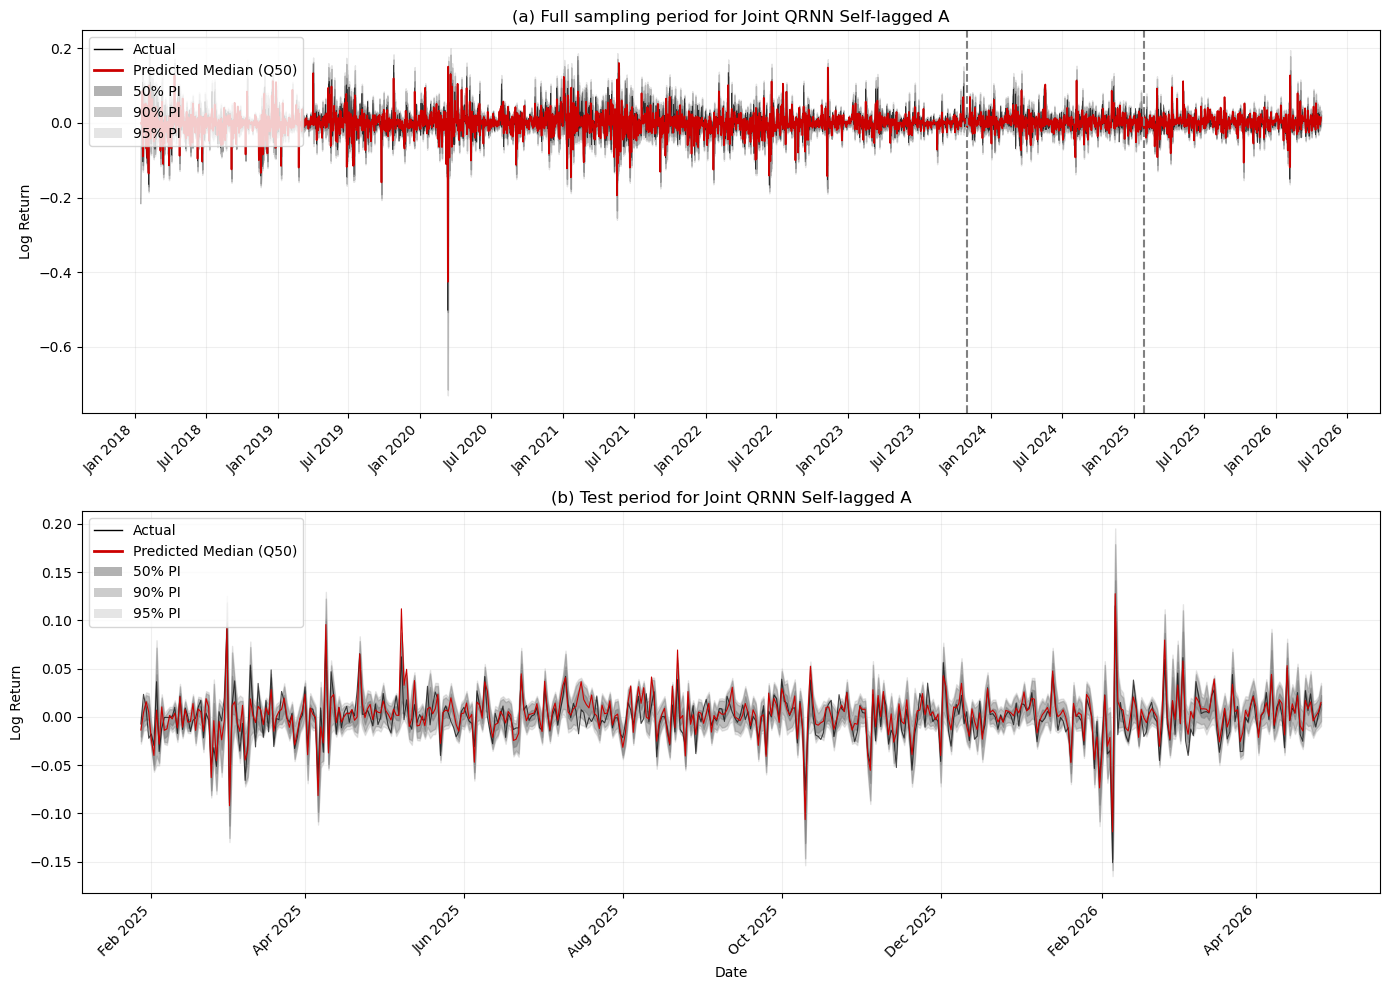

Plot saved to hybrid_qrnn_self_a_joint_predictions.png

TEST METRICS -- JOINT QRNN A SELF-LAGGED
 alpha       NLL  Hit_Rate      HRE
 0.025 -2.552901  0.041850 0.016850
 0.050 -2.648045  0.090308 0.040308
 0.250 -2.921150  0.303965 0.053965
 0.500 -2.937765  0.636564 0.136564
 0.750 -2.971813  0.801762 0.051762
 0.950 -2.643591  0.955947 0.005947
 0.975 -2.509716  0.966960 0.008040

Average NLL: -2.740712
Average HRE: 0.044777

CROSSOVER ANALYSIS -- FINAL HYBRID OUTPUT
(0.025, 0.050): 0 (0.00%) <-- TAIL
(0.050, 0.250): 2 (0.44%)
(0.250, 0.500): 0 (0.00%)
(0.500, 0.750): 28 (6.17%)
(0.750, 0.950): 1 (0.22%)
(0.950, 0.975): 0 (0.00%) <-- TAIL

Total violations: 31 (1.14%)
Tail violations: 0 (0.00%)

CROSSOVER ANALYSIS -- MONOTONIC FNN OUTPUT
(0.025, 0.050): 0 (0.00%) <-- TAIL
(0.050, 0.250): 0 (0.00%)
(0.250, 0.500): 0 (0.00%)
(0.500, 0.750): 0 (0.00%)
(0.750, 0.950): 0 (0.00%)
(0.950, 0.975): 0 (0.00%) <-- TAIL

Total violations: 0 (0.00%)
Tail violations: 0 (0.00%)


In [25]:
import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

from matplotlib.patches import Patch
from matplotlib.lines import Line2D


# ============================================================
# Joint QRNN A Self-lagged -- plotting and test evaluation
# Run directly after the joint tuning code
# ============================================================

X_test_q = torch.tensor(
    test_df[feature_cols].values,
    dtype=torch.float32
)
y_test_q = torch.tensor(
    test_df['log_return'].values,
    dtype=torch.float32
)

model = best_model_joint
model.eval()


# -------------------------
# Sequential predictions
# -------------------------
with torch.no_grad():
    q_train, sigma, caviar_train, fnn_train = model(
        y_train, X_train
    )

    q_val, _, caviar_val, fnn_val = model(
        y_val,
        X_val,
        initial_caviar=caviar_train[-1],
        initial_y=y_train[-1]
    )

    q_test, _, _, fnn_test = model(
        y_test_q,
        X_test_q,
        initial_caviar=caviar_val[-1],
        initial_y=y_val[-1]
    )

q_train_np = q_train.numpy()
q_val_np   = q_val.numpy()
q_test_np  = q_test.numpy()

q_all = np.concatenate(
    [q_train_np, q_val_np, q_test_np],
    axis=0
)

y_all = np.concatenate([
    train_df['log_return'].values,
    val_df['log_return'].values,
    test_df['log_return'].values
])

all_dates = (
    train_df.index
    .append(val_df.index)
    .append(test_df.index)
)

level_index = {
    alpha: k
    for k, alpha in enumerate(alpha_levels)
}

all_preds_qrnn_a_self = {
    alpha: q_all[:, k]
    for k, alpha in enumerate(alpha_levels)
}


# ============================================================
# Plotting
# ============================================================
def plot_two_panel_qrnn_joint(
    all_preds,
    train_df,
    val_df,
    test_df,
    save_fname='hybrid_qrnn_self_a_joint_predictions.png'
):
    actual_color = '#000000'
    pred_color   = '#CC0000'
    pi_color     = '#808080'

    train_size = len(train_df)
    val_size   = len(val_df)
    test_start = train_size + val_size

    test_dates = test_df.index
    y_test_np  = test_df['log_return'].values

    legend_elements = [
        Line2D(
            [0], [0],
            color=actual_color,
            lw=1,
            label='Actual'
        ),
        Line2D(
            [0], [0],
            color=pred_color,
            lw=2,
            label='Predicted Median (Q50)'
        ),
        Patch(
            facecolor=pi_color,
            alpha=0.6,
            label='50% PI'
        ),
        Patch(
            facecolor=pi_color,
            alpha=0.4,
            label='90% PI'
        ),
        Patch(
            facecolor=pi_color,
            alpha=0.2,
            label='95% PI'
        )
    ]

    fig, axes = plt.subplots(
        2, 1, figsize=(14, 10)
    )

    # -------------------------
    # Full sample
    # -------------------------
    ax = axes[0]

    ax.plot(
        all_dates,
        y_all,
        color=actual_color,
        linewidth=0.5,
        alpha=0.7
    )
    ax.plot(
        all_dates,
        all_preds[0.500],
        color=pred_color,
        linewidth=1.2
    )
    ax.fill_between(
        all_dates,
        all_preds[0.025],
        all_preds[0.975],
        color=pi_color,
        alpha=0.2
    )
    ax.fill_between(
        all_dates,
        all_preds[0.050],
        all_preds[0.950],
        color=pi_color,
        alpha=0.4
    )
    ax.fill_between(
        all_dates,
        all_preds[0.250],
        all_preds[0.750],
        color=pi_color,
        alpha=0.6
    )

    ax.axvline(
        train_df.index[-1],
        color='gray',
        linestyle='--'
    )
    ax.axvline(
        val_df.index[-1],
        color='gray',
        linestyle='--'
    )

    ax.xaxis.set_major_formatter(
        mdates.DateFormatter('%b %Y')
    )
    ax.xaxis.set_major_locator(
        mdates.MonthLocator(interval=6)
    )
    plt.setp(
        ax.xaxis.get_majorticklabels(),
        rotation=45,
        ha='right'
    )

    ax.set_title(
        '(a) Full sampling period for '
        'Joint QRNN Self-lagged A'
    )
    ax.set_ylabel('Log Return')
    ax.legend(
        handles=legend_elements,
        loc='upper left'
    )
    ax.grid(True, alpha=0.2)

    # -------------------------
    # Test sample
    # -------------------------
    ax2 = axes[1]

    ax2.plot(
        test_dates,
        y_test_np,
        color=actual_color,
        linewidth=0.8,
        alpha=0.7
    )
    ax2.plot(
        test_dates,
        all_preds[0.500][test_start:],
        color=pred_color,
        linewidth=0.8
    )
    ax2.fill_between(
        test_dates,
        all_preds[0.025][test_start:],
        all_preds[0.975][test_start:],
        color=pi_color,
        alpha=0.2
    )
    ax2.fill_between(
        test_dates,
        all_preds[0.050][test_start:],
        all_preds[0.950][test_start:],
        color=pi_color,
        alpha=0.4
    )
    ax2.fill_between(
        test_dates,
        all_preds[0.250][test_start:],
        all_preds[0.750][test_start:],
        color=pi_color,
        alpha=0.6
    )

    ax2.xaxis.set_major_formatter(
        mdates.DateFormatter('%b %Y')
    )
    ax2.xaxis.set_major_locator(
        mdates.MonthLocator(interval=2)
    )
    plt.setp(
        ax2.xaxis.get_majorticklabels(),
        rotation=45,
        ha='right'
    )

    ax2.set_title(
        '(b) Test period for '
        'Joint QRNN Self-lagged A'
    )
    ax2.set_xlabel('Date')
    ax2.set_ylabel('Log Return')
    ax2.legend(
        handles=legend_elements,
        loc='upper left'
    )
    ax2.grid(True, alpha=0.2)

    plt.tight_layout()
    plt.savefig(
        save_fname,
        dpi=300,
        bbox_inches='tight'
    )
    plt.show()

    print(f'Plot saved to {save_fname}')


plot_two_panel_qrnn_joint(
    all_preds_qrnn_a_self,
    train_df,
    val_df,
    test_df
)


# ============================================================
# Test NLL and HRE
# ============================================================
def compute_test_metrics_joint(
    y_test,
    q_test,
    sigma,
    alpha_levels
):
    records = []

    for k, alpha in enumerate(alpha_levels):
        y = y_test
        q = q_test[:, k]
        sigma_k = sigma[k]

        u = y - q
        indicator = (u < 0).float()
        rho = u * (alpha - indicator)

        nll = (
            -np.log(alpha * (1 - alpha))
            + torch.log(sigma_k)
            + rho / sigma_k
        ).mean().item()

        hit_rate = (
            y <= q
        ).float().mean().item()

        hre = abs(hit_rate - alpha)

        records.append({
            'alpha': alpha,
            'NLL': nll,
            'Hit_Rate': hit_rate,
            'HRE': hre
        })

    results = pd.DataFrame(records)

    print('\n' + '=' * 60)
    print('TEST METRICS -- JOINT QRNN A SELF-LAGGED')
    print('=' * 60)
    print(results.to_string(index=False))
    print(f"\nAverage NLL: {results['NLL'].mean():.6f}")
    print(f"Average HRE: {results['HRE'].mean():.6f}")

    results.to_csv(
        'joint_qrnn_a_self_test_metrics.csv',
        index=False
    )

    return results


test_metrics_qrnn_a_self = compute_test_metrics_joint(
    y_test_q,
    q_test,
    sigma,
    alpha_levels
)


# ============================================================
# Test crossover analysis
# ============================================================
def compute_crossovers_joint(
    q_pred,
    levels,
    model_name
):
    q = q_pred.numpy()
    T = len(q)

    total_violations = 0
    tail_violations  = 0

    print('\n' + '=' * 60)
    print(f'CROSSOVER ANALYSIS -- {model_name}')
    print('=' * 60)

    for k in range(len(levels) - 1):
        lo = levels[k]
        hi = levels[k + 1]

        violations = int(
            np.sum(q[:, k] > q[:, k + 1])
        )
        percentage = violations / T * 100

        total_violations += violations

        if k == 0 or k == len(levels) - 2:
            tail_violations += violations
            marker = ' <-- TAIL'
        else:
            marker = ''

        print(
            f'({lo:.3f}, {hi:.3f}): '
            f'{violations} ({percentage:.2f}%){marker}'
        )

    total_rate = (
        total_violations /
        (T * (len(levels) - 1))
    )
    tail_rate = tail_violations / (T * 2)

    print(
        f'\nTotal violations: {total_violations} '
        f'({total_rate:.2%})'
    )
    print(
        f'Tail violations: {tail_violations} '
        f'({tail_rate:.2%})'
    )

    return total_violations, tail_violations


# Final hybrid forecasts: crossing may remain
final_crossovers = compute_crossovers_joint(
    q_test,
    alpha_levels,
    'FINAL HYBRID OUTPUT'
)

# FNN forecasts: crossing should be zero
fnn_crossovers = compute_crossovers_joint(
    fnn_test,
    alpha_levels,
    'MONOTONIC FNN OUTPUT'
)

# Cross over dealing 1b

In [ ]:
import copy

import numpy as np
import optuna
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
from optuna.samplers import TPESampler


# ============================================================
# METHOD 1B -- JOINT QRNN A SELF-LAGGED
#
# One joint model estimates:
#   1. one central (median) Hybrid QRNN forecast; and
#   2. six positive, time-varying adjacent spacings.
#
# Unlike Method 1a, the constraint is imposed on the COMPLETE
# final forecasts, not only on the unrestricted FNN component.
# ============================================================

alpha_levels = [0.025, 0.050, 0.250, 0.500, 0.750, 0.950, 0.975]
median_index = alpha_levels.index(0.500)


class HybridQRNN_A_Joint_Method1B(nn.Module):
    def __init__(self, input_dim, config):
        super().__init__()

        self.n_levels = len(alpha_levels)
        self.eps = 1e-6

        # Only the median has an independently identifiable hybrid
        # statistical-neural decomposition. For every non-median level,
        # Method 1b directly estimates a positive adjacent spacing.
        self.beta1_raw = nn.Parameter(torch.tensor(1.386))
        self.beta2_raw = nn.Parameter(torch.tensor(0.3))
        self.beta3_raw = nn.Parameter(torch.tensor(0.3))
        self.psi_raw = nn.Parameter(torch.tensor(0.0))

        # One ALD scale for each of the seven final quantiles.
        self.sigma_raw = nn.Parameter(
            torch.full((self.n_levels,), 0.5)
        )

        layers = []
        previous_dim = input_dim

        for i in range(config['n_hidden_layers']):
            hidden_dim = config[f'hidden_dim_{i}']
            layers.append(nn.Linear(previous_dim, hidden_dim))

            if config['layernorm']:
                layers.append(nn.LayerNorm(hidden_dim))

            layers.append(self._get_activation(config['activation']))

            if config['dropout'] > 0:
                layers.append(nn.Dropout(config['dropout']))

            previous_dim = hidden_dim

        self.feature_extractor = nn.Sequential(*layers)

        # The median head uses the common features. As in Method 3,
        # every spacing head also receives its adjacent reference forecast.
        self.median_head = nn.Linear(previous_dim, 1)
        self.spacing_heads = nn.ModuleDict({
            name: nn.Linear(previous_dim + 1, 1)
            for name in [
                'delta12', 'delta23', 'delta34',
                'delta45', 'delta56', 'delta67'
            ]
        })

        for module in self.modules():
            if isinstance(module, nn.Linear):
                if config['weight_init'] == 'glorot':
                    nn.init.xavier_uniform_(module.weight)
                elif config['weight_init'] == 'he':
                    nn.init.kaiming_uniform_(module.weight)

                if module.bias is not None:
                    nn.init.zeros_(module.bias)

    @staticmethod
    def _get_activation(name):
        return {
            'relu': nn.ReLU(),
            'elu': nn.ELU(),
            'gelu': nn.GELU(),
            'tanh': nn.Tanh()
        }.get(name, nn.ReLU())

    def positive_spacing(self, features, reference, name):
        """Method 3 gap head: delta=softplus(g(X, reference))>0."""
        head_input = torch.cat(
            [features, reference.unsqueeze(1)],
            dim=1
        )
        raw_delta = self.spacing_heads[name](head_input).squeeze(1)
        return F.softplus(raw_delta) + self.eps

    def forward(
        self,
        y,
        X,
        initial_caviar=None,
        initial_y=None
    ):
        beta1 = torch.sigmoid(self.beta1_raw)
        beta2 = F.softplus(self.beta2_raw)
        beta3 = F.softplus(self.beta3_raw)
        psi = torch.sigmoid(self.psi_raw)
        sigma = F.softplus(self.sigma_raw) + self.eps

        features = self.feature_extractor(X)
        median_fnn = self.median_head(features).squeeze(1)

        q50, q50_caviar = compute_median_hybrid_location_self_a(
            y=y,
            median_fnn=median_fnn,
            beta1=beta1,
            beta2=beta2,
            beta3=beta3,
            psi=psi,
            initial_caviar=initial_caviar,
            initial_y=initial_y
        )

        # Reconstruct outwards exactly as in Method 3. Unlike the
        # sequential Method 3 fits, references are NOT detached here.
        # Consequently, the complete seven-level objective is joint.
        delta34 = self.positive_spacing(
            features, q50, 'delta34'
        )
        q3 = q50 - delta34

        delta23 = self.positive_spacing(
            features, q3, 'delta23'
        )
        q2 = q3 - delta23

        delta12 = self.positive_spacing(
            features, q2, 'delta12'
        )
        q1 = q2 - delta12

        delta45 = self.positive_spacing(
            features, q50, 'delta45'
        )
        q5 = q50 + delta45

        delta56 = self.positive_spacing(
            features, q5, 'delta56'
        )
        q6 = q5 + delta56

        delta67 = self.positive_spacing(
            features, q6, 'delta67'
        )
        q7 = q6 + delta67

        q_final = torch.stack(
            [q1, q2, q3, q50, q5, q6, q7],
            dim=1
        )
        delta = torch.stack(
            [
                delta12, delta23, delta34,
                delta45, delta56, delta67
            ],
            dim=1
        )

        return q_final, sigma, q50_caviar, q50, delta


def compute_median_hybrid_location_self_a(
    y,
    median_fnn,
    beta1,
    beta2,
    beta3,
    psi,
    initial_caviar=None,
    initial_y=None
):
    """Self-lagged asymmetric CAViaR-Hybrid recursion for alpha=0.50."""
    if (initial_caviar is None) != (initial_y is None):
        raise ValueError(
            'initial_caviar and initial_y must be supplied together.'
        )

    has_initial_state = (
        initial_caviar is not None and initial_y is not None
    )

    previous_caviar = (
        initial_caviar
        if has_initial_state
        else y.new_zeros(())
    )

    caviar_values = []
    hybrid_values = []

    for t in range(len(y)):
        # The first training row has no lagged state and is excluded
        # from the training loss.
        if t == 0 and not has_initial_state:
            zero = y.new_zeros(())
            caviar_values.append(zero)
            hybrid_values.append(zero)
            continue

        previous_y = initial_y if t == 0 else y[t - 1]
        y_positive = torch.clamp(previous_y, min=0)
        y_negative = torch.clamp(-previous_y, min=0)

        caviar_t = (
            beta1 * previous_caviar
            + beta2 * y_positive
            + beta3 * y_negative
        )

        hybrid_t = (
            psi * caviar_t
            + (1 - psi) * median_fnn[t]
        )

        caviar_values.append(caviar_t)
        hybrid_values.append(hybrid_t)
        previous_caviar = caviar_t

    return (
        torch.stack(hybrid_values),
        torch.stack(caviar_values)
    )


# ============================================================
# Joint ALD NLL and diagnostics
# ============================================================

def hybrid_qrnn_joint_loss(
    y,
    q_final,
    sigma_al,
    alpha_values=alpha_levels
):
    """Average ALD NLL over observations and all seven levels."""
    alpha = q_final.new_tensor(alpha_values)
    residual = y.unsqueeze(1) - q_final
    indicator = (residual < 0).to(q_final.dtype)
    check_loss = residual * (alpha.unsqueeze(0) - indicator)

    nll = (
        -torch.log(alpha * (1 - alpha)).unsqueeze(0)
        + torch.log(sigma_al).unsqueeze(0)
        + check_loss / sigma_al.unsqueeze(0)
    )

    return nll.mean()


def compute_hre_joint(
    y,
    q_final,
    alpha_values=alpha_levels
):
    alpha = q_final.new_tensor(alpha_values)
    hit_rate = (y.unsqueeze(1) <= q_final).float().mean(dim=0)
    hre_by_level = torch.abs(hit_rate - alpha)
    return hit_rate, hre_by_level, hre_by_level.mean()


def compute_crossover_joint(q_final):
    violations = q_final[:, :-1] > q_final[:, 1:]
    pair_counts = violations.sum(dim=0)
    sample_size = q_final.shape[0]

    total_count = int(pair_counts.sum().item())
    tail_count = int(
        pair_counts[0].item() + pair_counts[-1].item()
    )

    return {
        'pair_counts': [int(value) for value in pair_counts.tolist()],
        'total_count': total_count,
        'total_rate': total_count / (sample_size * 6),
        'tail_count': tail_count,
        'tail_rate': tail_count / (sample_size * 2)
    }


def compute_spacing_diagnostics(delta):
    """Diagnostics for delta12,...,delta67."""
    return {
        'mean': delta.mean(dim=0).tolist(),
        'minimum': delta.min(dim=0).values.tolist(),
        'maximum': delta.max(dim=0).values.tolist(),
        'std': delta.std(dim=0, unbiased=False).tolist(),
        'near_zero_count': (
            delta <= 1e-5
        ).sum(dim=0).tolist()
    }


# ============================================================
# Model fitting inside each Optuna trial
# ============================================================

def fit_joint_qrnn_model(config, max_epochs=800, seed=2026):
    torch.manual_seed(seed)
    np.random.seed(seed)

    model = HybridQRNN_A_Joint_Method1B(
        input_dim=X_train.shape[1],
        config=config
    )

    optimizer_class = (
        torch.optim.Adam
        if config['optimizer'] == 'adam'
        else torch.optim.AdamW
    )
    optimizer = optimizer_class(
        model.parameters(),
        lr=config['lr'],
        weight_decay=config['weight_decay']
    )

    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer,
        mode='min',
        patience=10,
        factor=0.5,
        min_lr=1e-6
    )

    best_validation_loss = float('inf')
    patience_counter = 0
    best_model_state = None

    for _ in range(max_epochs):
        model.train()
        optimizer.zero_grad()

        q_train, sigma_train, _, _, _ = model(y_train, X_train)

        # The t=0 training forecast is an initialisation row.
        train_loss = hybrid_qrnn_joint_loss(
            y_train[1:],
            q_train[1:],
            sigma_train
        )

        if not torch.isfinite(train_loss):
            return None

        train_loss.backward()
        nn.utils.clip_grad_norm_(
            model.parameters(),
            config['gradient_clip']
        )
        optimizer.step()

        model.eval()
        with torch.no_grad():
            _, _, final_train_caviar, _, _ = model(
                y_train,
                X_train
            )

            q_validation, sigma_validation, _, _, _ = model(
                y_val,
                X_val,
                initial_caviar=final_train_caviar[-1],
                initial_y=y_train[-1]
            )

            validation_loss = hybrid_qrnn_joint_loss(
                y_val,
                q_validation,
                sigma_validation
            )

        if not torch.isfinite(validation_loss):
            return None

        scheduler.step(validation_loss.item())

        if validation_loss.item() < best_validation_loss:
            best_validation_loss = validation_loss.item()
            patience_counter = 0
            best_model_state = copy.deepcopy(model.state_dict())
        else:
            patience_counter += 1
            if patience_counter >= config['patience']:
                break

    if best_model_state is None:
        return None

    model.load_state_dict(best_model_state)
    return model


def evaluate_joint_qrnn_model(model):
    model.eval()

    with torch.no_grad():
        _, _, final_train_caviar, _, _ = model(y_train, X_train)

        q_validation, sigma, _, _, delta = model(
            y_val,
            X_val,
            initial_caviar=final_train_caviar[-1],
            initial_y=y_train[-1]
        )

        mean_nll = hybrid_qrnn_joint_loss(
            y_val,
            q_validation,
            sigma
        ).item()

        hit_rate, hre_by_level, mean_hre = compute_hre_joint(
            y_val,
            q_validation
        )

        crossover = compute_crossover_joint(q_validation)
        spacing = compute_spacing_diagnostics(delta)

        beta1 = torch.sigmoid(model.beta1_raw).item()
        beta2 = F.softplus(model.beta2_raw).item()
        beta3 = F.softplus(model.beta3_raw).item()
        psi = torch.sigmoid(model.psi_raw).item()
        sigma_values = (
            F.softplus(model.sigma_raw) + model.eps
        ).tolist()

    return {
        'mean_nll': mean_nll,
        'hit_rate': hit_rate.tolist(),
        'hre_by_level': hre_by_level.tolist(),
        'mean_hre': mean_hre.item(),
        'final_crossover': crossover,
        'spacing': spacing,
        'median_beta1': beta1,
        'median_beta2': beta2,
        'median_beta3': beta3,
        'median_psi': psi,
        'sigma': sigma_values
    }


# ============================================================
# Optuna objective
# ============================================================

def objective_qrnn_joint_method1b(trial):
    config = {
        'n_hidden_layers': trial.suggest_int(
            'n_hidden_layers', 1, 3
        ),
        'activation': trial.suggest_categorical(
            'activation', ['relu', 'elu', 'gelu', 'tanh']
        ),
        'dropout': trial.suggest_float('dropout', 0.0, 0.5),
        'layernorm': trial.suggest_categorical(
            'layernorm', [True, False]
        ),
        'weight_init': trial.suggest_categorical(
            'weight_init', ['glorot', 'he']
        ),
        'lr': trial.suggest_float('lr', 1e-4, 5e-2, log=True),
        'optimizer': trial.suggest_categorical(
            'optimizer', ['adam', 'adamw']
        ),
        'weight_decay': trial.suggest_float(
            'weight_decay', 0.0, 1e-4
        ),
        'gradient_clip': trial.suggest_categorical(
            'gradient_clip', [0.1, 1.0, 5.0]
        ),
        'patience': trial.suggest_categorical(
            'patience', [10, 20, 30]
        )
    }

    for i in range(config['n_hidden_layers']):
        config[f'hidden_dim_{i}'] = trial.suggest_int(
            f'hidden_dim_{i}', 32, 256
        )

    model = fit_joint_qrnn_model(
        config=config,
        max_epochs=800,
        seed=2026
    )

    if model is None:
        return float('inf')

    metrics = evaluate_joint_qrnn_model(model)

    for name in [
        'mean_nll',
        'mean_hre',
        'hit_rate',
        'hre_by_level',
        'spacing',
        'sigma',
        'median_beta1',
        'median_beta2',
        'median_beta3',
        'median_psi'
    ]:
        trial.set_user_attr(name, metrics[name])

    trial.set_user_attr(
        'final_crossover_count',
        metrics['final_crossover']['total_count']
    )
    trial.set_user_attr(
        'final_crossover_rate',
        metrics['final_crossover']['total_rate']
    )
    trial.set_user_attr(
        'tail_crossover_count',
        metrics['final_crossover']['tail_count']
    )
    trial.set_user_attr(
        'tail_crossover_rate',
        metrics['final_crossover']['tail_rate']
    )
    trial.set_user_attr(
        'pair_crossover_counts',
        metrics['final_crossover']['pair_counts']
    )

    print(
        f"Trial {trial.number}: "
        f"Mean NLL={metrics['mean_nll']:.6f} | "
        f"Mean HRE={metrics['mean_hre']:.6f} | "
        f"Final crossover="
        f"{metrics['final_crossover']['total_rate']:.2%}"
    )

    # Optuna requires one scalar. The final selection below uses
    # the sum of validation NLL rank and validation HRE rank.
    return metrics['mean_nll']


def select_best_trial_by_rank_joint(study):
    trials = [
        trial for trial in study.trials
        if trial.state == optuna.trial.TrialState.COMPLETE
        and trial.value is not None
        and np.isfinite(trial.value)
        and 'mean_nll' in trial.user_attrs
        and 'mean_hre' in trial.user_attrs
    ]

    if not trials:
        raise RuntimeError('No valid completed Optuna trials.')

    nll_order = sorted(
        trials,
        key=lambda trial: (
            trial.user_attrs['mean_nll'],
            trial.number
        )
    )
    hre_order = sorted(
        trials,
        key=lambda trial: (
            trial.user_attrs['mean_hre'],
            trial.number
        )
    )

    rank_nll = {
        trial.number: rank
        for rank, trial in enumerate(nll_order, start=1)
    }
    rank_hre = {
        trial.number: rank
        for rank, trial in enumerate(hre_order, start=1)
    }

    best = min(
        trials,
        key=lambda trial: (
            rank_nll[trial.number] + rank_hre[trial.number],
            trial.user_attrs['mean_nll'],
            trial.user_attrs['mean_hre'],
            trial.number
        )
    )

    return best, trials, rank_nll, rank_hre


# ============================================================
# Run the joint study
# ============================================================

base_seed = 2026

print('\n' + '=' * 70)
print('Tuning Method 1b Joint QRNN A Self-lagged')
print('=' * 70)

sampler = TPESampler(seed=base_seed)
study = optuna.create_study(
    direction='minimize',
    sampler=sampler
)

study.optimize(
    objective_qrnn_joint_method1b,
    n_trials=800,
    show_progress_bar=True
)

best_trial, all_trials, rank_nll, rank_hre = (
    select_best_trial_by_rank_joint(study)
)


# ============================================================
# Save full trial ranking
# ============================================================

spacing_names = [
    'delta12', 'delta23', 'delta34',
    'delta45', 'delta56', 'delta67'
]
ranking_records = []

for trial in all_trials:
    record = {
        'trial': trial.number,
        'mean_nll': trial.user_attrs['mean_nll'],
        'mean_hre': trial.user_attrs['mean_hre'],
        'rank_nll': rank_nll[trial.number],
        'rank_hre': rank_hre[trial.number],
        'sum_rank': (
            rank_nll[trial.number] + rank_hre[trial.number]
        ),
        'final_crossover_count': trial.user_attrs[
            'final_crossover_count'
        ],
        'final_crossover_rate': trial.user_attrs[
            'final_crossover_rate'
        ],
        'tail_crossover_count': trial.user_attrs[
            'tail_crossover_count'
        ],
        'tail_crossover_rate': trial.user_attrs[
            'tail_crossover_rate'
        ],
        'median_beta1': trial.user_attrs['median_beta1'],
        'median_beta2': trial.user_attrs['median_beta2'],
        'median_beta3': trial.user_attrs['median_beta3'],
        'median_psi': trial.user_attrs['median_psi']
    }

    for k, alpha in enumerate(alpha_levels):
        suffix = f'alpha_{alpha:.3f}'
        record[f'hit_rate_{suffix}'] = (
            trial.user_attrs['hit_rate'][k]
        )
        record[f'hre_{suffix}'] = (
            trial.user_attrs['hre_by_level'][k]
        )
        record[f'sigma_{suffix}'] = (
            trial.user_attrs['sigma'][k]
        )

    spacing = trial.user_attrs['spacing']
    for k, name in enumerate(spacing_names):
        record[f'{name}_mean'] = spacing['mean'][k]
        record[f'{name}_minimum'] = spacing['minimum'][k]
        record[f'{name}_maximum'] = spacing['maximum'][k]
        record[f'{name}_std'] = spacing['std'][k]
        record[f'{name}_near_zero_count'] = (
            spacing['near_zero_count'][k]
        )

    record.update(trial.params)
    ranking_records.append(record)


ranking_df = pd.DataFrame(ranking_records).sort_values(
    ['sum_rank', 'mean_nll', 'mean_hre', 'trial']
)
ranking_df.to_csv(
    'method1b_joint_qrnn_a_self_ranking.csv',
    index=False
)


# ============================================================
# Refit and save the selected configuration
# ============================================================

best_config = best_trial.params.copy()
best_model_method1b = fit_joint_qrnn_model(
    config=best_config,
    max_epochs=800,
    seed=2026
)

if best_model_method1b is None:
    raise RuntimeError('The selected Method 1b configuration failed to refit.')

best_metrics_method1b = evaluate_joint_qrnn_model(
    best_model_method1b
)

torch.save(
    {
        'model_state_dict': best_model_method1b.state_dict(),
        'config': best_config,
        'alpha_levels': alpha_levels,
        'method': 'Method 1b joint positive adjacent spacing',
        'validation_metrics': best_metrics_method1b
    },
    'method1b_joint_qrnn_a_self_best.pt'
)


# ============================================================
# Final summary
# ============================================================

print('\n' + '=' * 70)
print('TUNING COMPLETE -- METHOD 1B JOINT QRNN A SELF-LAGGED')
print('=' * 70)
print(f'Best trial: #{best_trial.number}')
print(
    f'NLL rank: {rank_nll[best_trial.number]} | '
    f'HRE rank: {rank_hre[best_trial.number]} | '
    f'Sum rank: '
    f'{rank_nll[best_trial.number] + rank_hre[best_trial.number]}'
)
print(
    f"Mean validation NLL: "
    f"{best_metrics_method1b['mean_nll']:.6f}"
)
print(
    f"Mean validation HRE: "
    f"{best_metrics_method1b['mean_hre']:.6f}"
)

print('\nCoverage diagnostics by alpha:')
for alpha, hit_rate, hre in zip(
    alpha_levels,
    best_metrics_method1b['hit_rate'],
    best_metrics_method1b['hre_by_level']
):
    print(
        f'  alpha={alpha:.3f} | '
        f'hit rate={hit_rate:.6f} | HRE={hre:.6f}'
    )

print(
    '\nFinal hybrid crossover: '
    f"{best_metrics_method1b['final_crossover']['total_count']} "
    f"({best_metrics_method1b['final_crossover']['total_rate']:.2%})"
)
print(
    'Tail crossover: '
    f"{best_metrics_method1b['final_crossover']['tail_count']} "
    f"({best_metrics_method1b['final_crossover']['tail_rate']:.2%})"
)

print('\nMedian hybrid parameters:')
print(
    f"  beta1={best_metrics_method1b['median_beta1']:.6f} | "
    f"beta2={best_metrics_method1b['median_beta2']:.6f} | "
    f"beta3={best_metrics_method1b['median_beta3']:.6f} | "
    f"psi={best_metrics_method1b['median_psi']:.6f}"
)

print('\nLearned-spacing diagnostics:')
spacing = best_metrics_method1b['spacing']
for k, name in enumerate(spacing_names):
    print(
        f'  {name} | '
        f"mean={spacing['mean'][k]:.6f} | "
        f"min={spacing['minimum'][k]:.6f} | "
        f"max={spacing['maximum'][k]:.6f} | "
        f"std={spacing['std'][k]:.6f} | "
        f"near-zero={spacing['near_zero_count'][k]}"
    )

print(f'\nBest hyperparameters: {best_config}')
print(
    'Full ranking saved to: '
    'method1b_joint_qrnn_a_self_ranking.csv'
)
print(
    'Best model saved to: '
    'method1b_joint_qrnn_a_self_best.pt'
)

[I 2026-08-18 14:53:12,007] A new study created in memory with name: no-name-160f78b4-94b7-4b2b-aff9-a1c865b4f333



Tuning Method 1b Joint QRNN A Self-lagged


  0%|          | 0/800 [00:00<?, ?it/s]

Trial 0: Mean NLL=2.217076 | Mean HRE=0.237638 | Final crossover=0.00%
[I 2026-08-18 14:54:35,457] Trial 0 finished with value: 2.217075824737549 and parameters: {'n_hidden_layers': 1, 'activation': 'elu', 'dropout': 0.49377524711883497, 'layernorm': False, 'weight_init': 'he', 'lr': 0.0006552020421842752, 'optimizer': 'adam', 'weight_decay': 8.940884610144999e-05, 'gradient_clip': 5.0, 'patience': 30, 'hidden_dim_0': 38}. Best is trial 0 with value: 2.217075824737549.
Trial 1: Mean NLL=-1.530809 | Mean HRE=0.117960 | Final crossover=0.00%
[I 2026-08-18 14:55:59,916] Trial 1 finished with value: -1.5308085680007935 and parameters: {'n_hidden_layers': 1, 'activation': 'tanh', 'dropout': 0.07458356653667625, 'layernorm': False, 'weight_init': 'he', 'lr': 0.006969178688110181, 'optimizer': 'adam', 'weight_decay': 2.574006001095316e-05, 'gradient_clip': 1.0, 'patience': 30, 'hidden_dim_0': 102}. Best is trial 1 with value: -1.5308085680007935.
Trial 2: Mean NLL=2.545123 | Mean HRE=0.156402

# Cross over dealing 2

In [28]:
# ============================================================
# SEQUENTIAL HYBRID QRNN — A SELF-LAGGED
# Overall hybrid-output constraint implemented through FNN
# ============================================================

import copy
import numpy as np
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
import optuna

from optuna.samplers import TPESampler


# ------------------------------------------------------------
# Settings
# ------------------------------------------------------------

alpha_levels = [
    0.025, 0.050, 0.250, 0.500,
    0.750, 0.950, 0.975
]

# Median-outward estimation order
estimation_order = [
    0.500,
    0.750,
    0.950,
    0.975,
    0.250,
    0.050,
    0.025
]

reference_level = {
    0.500: None,
    0.750: 0.500,
    0.950: 0.750,
    0.975: 0.950,
    0.250: 0.500,
    0.050: 0.250,
    0.025: 0.050
}

constraint_direction = {
    0.500: None,
    0.750: 'upper',
    0.950: 'upper',
    0.975: 'upper',
    0.250: 'lower',
    0.050: 'lower',
    0.025: 'lower'
}

# Small minimum final-output spacing
DELTA = 1e-6

# Scaled-softplus smoothing parameter
SMOOTH_A = 1e-3

# Prevent psi from reaching exactly one
PSI_MARGIN = 1e-4

N_TRIALS = 200
MAX_EPOCHS = 200
BASE_SEED = 2026


# ------------------------------------------------------------
# Scaled softplus
# ------------------------------------------------------------

def scaled_softplus(x, smooth_a=SMOOTH_A):
    """
    Smooth approximation to max(0, x).

    smooth_a * softplus(x / smooth_a)
    """
    return smooth_a * F.softplus(
        x / smooth_a
    )


# ------------------------------------------------------------
# Sequential Hybrid QRNN A Self-lagged
# ------------------------------------------------------------

class SequentialHybridQRNNSelfA(nn.Module):

    def __init__(
        self,
        input_dim,
        config,
        direction=None
    ):
        super().__init__()

        self.direction = direction

        # Estimated during training
        self.beta1_raw = nn.Parameter(
            torch.tensor(1.386)
        )

        self.beta2_raw = nn.Parameter(
            torch.tensor(0.3)
        )

        self.beta3_raw = nn.Parameter(
            torch.tensor(0.3)
        )

        self.psi_raw = nn.Parameter(
            torch.tensor(0.0)
        )

        self.sigma_raw = nn.Parameter(
            torch.tensor(0.5)
        )

        # Non-median FNNs receive the reference forecast
        # as one additional input.
        fnn_input_dim = (
            input_dim
            if direction is None
            else input_dim + 1
        )

        layers = []
        prev_dim = fnn_input_dim

        for i in range(
            config['n_hidden_layers']
        ):

            hidden_dim = config[
                f'hidden_dim_{i}'
            ]

            layers.append(
                nn.Linear(
                    prev_dim,
                    hidden_dim
                )
            )

            if config['layernorm']:
                layers.append(
                    nn.LayerNorm(hidden_dim)
                )

            layers.append(
                self._get_activation(
                    config['activation']
                )
            )

            if config['dropout'] > 0:
                layers.append(
                    nn.Dropout(
                        config['dropout']
                    )
                )

            prev_dim = hidden_dim

        layers.append(
            nn.Linear(prev_dim, 1)
        )

        self.fnn = nn.Sequential(*layers)

        for module in self.fnn.modules():

            if isinstance(module, nn.Linear):

                if config['weight_init'] == 'glorot':
                    nn.init.xavier_uniform_(
                        module.weight
                    )

                elif config['weight_init'] == 'he':
                    nn.init.kaiming_uniform_(
                        module.weight
                    )

                if module.bias is not None:
                    nn.init.zeros_(
                        module.bias
                    )


    def _get_activation(self, name):

        return {
            'relu': nn.ReLU(),
            'elu': nn.ELU(),
            'gelu': nn.GELU(),
            'tanh': nn.Tanh()
        }.get(name, nn.ReLU())


    def constrain_fnn_output(
        self,
        f_raw,
        caviar,
        q_reference,
        psi
    ):

        denominator = 1.0 - psi

        if self.direction == 'upper':

            # Required FNN lower bound derived from
            # q_current > q_reference + DELTA
            fnn_boundary = (
                q_reference
                + DELTA
                - psi * caviar
            ) / denominator

            f_constrained = (
                fnn_boundary
                + scaled_softplus(
                    f_raw - fnn_boundary
                )
            )

        elif self.direction == 'lower':

            # Required FNN upper bound derived from
            # q_current < q_reference - DELTA
            fnn_boundary = (
                q_reference
                - DELTA
                - psi * caviar
            ) / denominator

            f_constrained = (
                fnn_boundary
                - scaled_softplus(
                    fnn_boundary - f_raw
                )
            )

        else:

            f_constrained = f_raw

        return f_constrained


    def forward(
        self,
        y,
        X,
        q_reference=None
    ):

        beta1 = torch.sigmoid(
            self.beta1_raw
        )

        beta2 = F.softplus(
            self.beta2_raw
        )

        beta3 = F.softplus(
            self.beta3_raw
        )

        # Strictly below one
        psi = (
            1.0 - PSI_MARGIN
        ) * torch.sigmoid(
            self.psi_raw
        )

        sigma = (
            F.softplus(self.sigma_raw)
            + 1e-6
        )

        if self.direction is None:

            X_fnn = X

        else:

            if q_reference is None:
                raise ValueError(
                    "A reference forecast is required "
                    "for a non-median model."
                )

            # Reference forecasts are frozen
            q_reference = (
                q_reference.detach()
            )

            X_fnn = torch.cat(
                [
                    X,
                    q_reference.unsqueeze(1)
                ],
                dim=1
            )

        f_raw = (
            self.fnn(X_fnn)
            .squeeze(-1)
        )

        q_caviar_list = []
        q_hybrid_list = []
        f_constrained_list = []

        initial_caviar = torch.zeros(
            (),
            dtype=y.dtype,
            device=y.device
        )

        q_caviar_list.append(
            initial_caviar
        )

        # Median retains the original zero initialisation.
        if self.direction is None:

            initial_hybrid = torch.zeros(
                (),
                dtype=y.dtype,
                device=y.device
            )

            initial_f_constrained = f_raw[0]

        else:

            # Apply the adjacent-level constraint at t=0
            initial_f_constrained = (
                self.constrain_fnn_output(
                    f_raw=f_raw[0],
                    caviar=initial_caviar,
                    q_reference=q_reference[0],
                    psi=psi
                )
            )

            initial_hybrid = (
                psi * initial_caviar
                + (1.0 - psi)
                * initial_f_constrained
            )

        q_hybrid_list.append(
            initial_hybrid
        )

        f_constrained_list.append(
            initial_f_constrained
        )

        for t in range(1, len(y)):

            y_pos = torch.clamp(
                y[t - 1],
                min=0
            )

            y_neg = torch.clamp(
                -y[t - 1],
                min=0
            )

            # Self-lagged A:
            # previous pure CAViaR output
            caviar_t = (
                beta1
                * q_caviar_list[t - 1]
                + beta2 * y_pos
                + beta3 * y_neg
            )

            q_caviar_list.append(
                caviar_t
            )

            if self.direction is None:

                f_constrained_t = (
                    f_raw[t]
                )

            else:

                f_constrained_t = (
                    self.constrain_fnn_output(
                        f_raw=f_raw[t],
                        caviar=caviar_t,
                        q_reference=q_reference[t],
                        psi=psi
                    )
                )

            hybrid_t = (
                psi * caviar_t
                + (1.0 - psi)
                * f_constrained_t
            )

            f_constrained_list.append(
                f_constrained_t
            )

            q_hybrid_list.append(
                hybrid_t
            )

        q_caviar = torch.stack(
            q_caviar_list
        )

        q_hybrid = torch.stack(
            q_hybrid_list
        )

        f_constrained = torch.stack(
            f_constrained_list
        )

        return (
            q_hybrid,
            q_caviar,
            f_raw,
            f_constrained,
            sigma
        )


# ------------------------------------------------------------
# Original ALD loss remains unchanged
# ------------------------------------------------------------

def hybrid_qrnn_loss(
    y,
    q_hybrid,
    sigma_al,
    alpha
):

    u = y - q_hybrid

    indicator = (
        u < 0
    ).float()

    rho_alpha = u * (
        alpha - indicator
    )

    alpha_constant = torch.tensor(
        alpha * (1.0 - alpha),
        dtype=y.dtype,
        device=y.device
    )

    nll = (
        -torch.log(alpha_constant)
        + torch.log(sigma_al)
        + rho_alpha / sigma_al
    )

    return nll.mean()


# ------------------------------------------------------------
# Coverage-ratio penalty
# ------------------------------------------------------------

def compute_crp(
    y,
    q,
    alpha
):

    if alpha <= 0.5:

        empirical = (
            y <= q
        ).float().mean().item()

        alpha_star = alpha

    else:

        empirical = (
            y > q
        ).float().mean().item()

        alpha_star = 1.0 - alpha

    crp = empirical / alpha_star

    penalty = (
        crp - 1.0
    ) ** 2

    return crp, penalty


# ------------------------------------------------------------
# Construct trial configuration
# ------------------------------------------------------------

def suggest_config(trial):

    config = {
        'n_hidden_layers':
            trial.suggest_int(
                'n_hidden_layers',
                1,
                3
            ),

        'activation':
            trial.suggest_categorical(
                'activation',
                ['relu', 'elu', 'gelu', 'tanh']
            ),

        'dropout':
            trial.suggest_float(
                'dropout',
                0.0,
                0.5
            ),

        'layernorm':
            trial.suggest_categorical(
                'layernorm',
                [True, False]
            ),

        'weight_init':
            trial.suggest_categorical(
                'weight_init',
                ['glorot', 'he']
            ),

        'lr':
            trial.suggest_float(
                'lr',
                1e-4,
                5e-2,
                log=True
            ),

        'optimizer':
            trial.suggest_categorical(
                'optimizer',
                ['adam', 'adamw']
            ),

        # Retained from the original search space
        'batch_size':
            trial.suggest_categorical(
                'batch_size',
                [32, 64, 128]
            ),

        'weight_decay':
            trial.suggest_float(
                'weight_decay',
                0.0,
                1e-4
            ),

        'gradient_clip':
            trial.suggest_categorical(
                'gradient_clip',
                [0.1, 1.0, 5.0]
            ),

        'patience':
            trial.suggest_categorical(
                'patience',
                [10, 20, 30]
            )
    }

    for i in range(
        config['n_hidden_layers']
    ):

        config[f'hidden_dim_{i}'] = (
            trial.suggest_int(
                f'hidden_dim_{i}',
                32,
                256
            )
        )

    return config


# ------------------------------------------------------------
# Train one configuration
# ------------------------------------------------------------

def train_sequential_qrnn_config(
    config,
    alpha,
    direction,
    q_reference_train=None,
    q_reference_val=None
):

    torch.manual_seed(BASE_SEED)

    model = SequentialHybridQRNNSelfA(
        input_dim=X_train.shape[1],
        config=config,
        direction=direction
    )

    if config['optimizer'] == 'adam':

        optimizer = torch.optim.Adam(
            model.parameters(),
            lr=config['lr'],
            weight_decay=config[
                'weight_decay'
            ]
        )

    else:

        optimizer = torch.optim.AdamW(
            model.parameters(),
            lr=config['lr'],
            weight_decay=config[
                'weight_decay'
            ]
        )

    scheduler = (
        torch.optim.lr_scheduler
        .ReduceLROnPlateau(
            optimizer,
            mode='min',
            patience=10,
            factor=0.5,
            min_lr=1e-6
        )
    )

    best_val_loss = float('inf')
    patience_counter = 0
    best_model_state = None

    for epoch in range(MAX_EPOCHS):

        model.train()
        optimizer.zero_grad()

        q_train, _, _, _, sigma_train = model(
            y_train,
            X_train,
            q_reference_train
        )

        train_loss = hybrid_qrnn_loss(
            y_train,
            q_train,
            sigma_train,
            alpha
        )

        if (
            torch.isnan(train_loss)
            or torch.isinf(train_loss)
        ):
            return None, float('inf')

        train_loss.backward()

        nn.utils.clip_grad_norm_(
            model.parameters(),
            config['gradient_clip']
        )

        optimizer.step()

        model.eval()

        with torch.no_grad():

            q_val, _, _, _, sigma_val = model(
                y_val,
                X_val,
                q_reference_val
            )

            val_loss = hybrid_qrnn_loss(
                y_val,
                q_val,
                sigma_val,
                alpha
            )

        scheduler.step(val_loss)

        if val_loss.item() < best_val_loss:

            best_val_loss = val_loss.item()
            patience_counter = 0

            best_model_state = copy.deepcopy(
                model.state_dict()
            )

        else:

            patience_counter += 1

            if (
                patience_counter
                >= config['patience']
            ):
                break

    if best_model_state is None:
        return None, float('inf')

    model.load_state_dict(
        best_model_state
    )

    return model, best_val_loss


# ------------------------------------------------------------
# Rank completed trials
# ------------------------------------------------------------

def select_best_trial_by_rank(study):

    trials = [
        trial for trial in study.trials
        if (
            trial.state
            == optuna.trial.TrialState.COMPLETE
            and trial.value is not None
            and np.isfinite(trial.value)
            and 'nll' in trial.user_attrs
            and 'crp_penalty'
            in trial.user_attrs
        )
    ]

    if len(trials) == 0:
        raise RuntimeError(
            "No valid Optuna trials were completed."
        )

    sorted_nll = sorted(
        trials,
        key=lambda trial:
            trial.user_attrs['nll']
    )

    nll_rank = {
        trial.number: rank
        for rank, trial in enumerate(
            sorted_nll,
            start=1
        )
    }

    sorted_crp = sorted(
        trials,
        key=lambda trial:
            trial.user_attrs[
                'crp_penalty'
            ]
    )

    crp_rank = {
        trial.number: rank
        for rank, trial in enumerate(
            sorted_crp,
            start=1
        )
    }

    for trial in trials:

        trial._rank_nll = (
            nll_rank[trial.number]
        )

        trial._rank_crp = (
            crp_rank[trial.number]
        )

        trial._sum_rank = (
            trial._rank_nll
            + trial._rank_crp
        )

    best_trial = min(
        trials,
        key=lambda trial: (
            trial._sum_rank,
            trial.user_attrs['nll'],
            trial.user_attrs[
                'crp_penalty'
            ],
            trial.number
        )
    )

    return best_trial, trials


# ------------------------------------------------------------
# Containers for sequential results
# ------------------------------------------------------------

best_models_sequential_qrnn_a_self = {}
best_configs_sequential_qrnn_a_self = {}

# Frozen forecasts used by the next model
train_predictions = {}
val_predictions = {}

all_studies_sequential_qrnn_a_self = {}


# ------------------------------------------------------------
# Sequential tuning
# ------------------------------------------------------------

for order_index, alpha in enumerate(
    estimation_order
):

    ref_alpha = reference_level[alpha]
    direction = constraint_direction[alpha]

    if ref_alpha is None:

        q_reference_train = None
        q_reference_val = None

    else:

        q_reference_train = (
            train_predictions[ref_alpha]
            .detach()
        )

        q_reference_val = (
            val_predictions[ref_alpha]
            .detach()
        )

    print("\n" + "=" * 70)
    print(
        f"Sequential QRNN A Self-lagged: "
        f"alpha={alpha:.3f}"
    )

    print(
        f"Reference level: {ref_alpha} | "
        f"Direction: {direction}"
    )

    print(
        f"Trials: {N_TRIALS} | "
        f"Seed: {BASE_SEED + order_index}"
    )

    print("=" * 70)


    def objective(trial):

        config = suggest_config(trial)

        model, _ = train_sequential_qrnn_config(
            config=config,
            alpha=alpha,
            direction=direction,
            q_reference_train=q_reference_train,
            q_reference_val=q_reference_val
        )

        if model is None:
            return float('inf')

        model.eval()

        with torch.no_grad():

            q_val, _, _, _, sigma_val = model(
                y_val,
                X_val,
                q_reference_val
            )

            val_nll = hybrid_qrnn_loss(
                y_val,
                q_val,
                sigma_val,
                alpha
            ).item()

            crp, crp_penalty = compute_crp(
                y_val,
                q_val,
                alpha
            )

            beta1 = torch.sigmoid(
                model.beta1_raw
            ).item()

            beta2 = F.softplus(
                model.beta2_raw
            ).item()

            beta3 = F.softplus(
                model.beta3_raw
            ).item()

            psi = (
                (1.0 - PSI_MARGIN)
                * torch.sigmoid(
                    model.psi_raw
                )
            ).item()

            sigma = (
                F.softplus(
                    model.sigma_raw
                )
                + 1e-6
            ).item()

        trial.set_user_attr(
            'nll',
            val_nll
        )

        trial.set_user_attr(
            'crp',
            crp
        )

        trial.set_user_attr(
            'crp_penalty',
            crp_penalty
        )

        trial.set_user_attr(
            'beta1',
            beta1
        )

        trial.set_user_attr(
            'beta2',
            beta2
        )

        trial.set_user_attr(
            'beta3',
            beta3
        )

        trial.set_user_attr(
            'psi',
            psi
        )

        trial.set_user_attr(
            'sigma',
            sigma
        )

        print(
            f"Trial {trial.number}: "
            f"NLL={val_nll:.4f} | "
            f"CRP={crp:.4f} | "
            f"CRP_penalty="
            f"{crp_penalty:.4f} | "
            f"alpha={alpha:.3f} | "
            f"direction={direction} | "
            f"psi={psi:.4f}"
        )

        return val_nll


    sampler = TPESampler(
        seed=BASE_SEED + order_index
    )

    study = optuna.create_study(
        direction='minimize',
        sampler=sampler
    )

    study.optimize(
        objective,
        n_trials=N_TRIALS,
        show_progress_bar=True
    )

    all_studies_sequential_qrnn_a_self[
        alpha
    ] = study

    best_trial, all_trials = (
        select_best_trial_by_rank(
            study
        )
    )


    # --------------------------------------------------------
    # Print top 10 trials
    # --------------------------------------------------------

    sorted_trials = sorted(
        all_trials,
        key=lambda trial: (
            trial._sum_rank,
            trial.user_attrs['nll'],
            trial.user_attrs[
                'crp_penalty'
            ]
        )
    )

    print(
        f"\nRanking summary for "
        f"alpha={alpha:.3f}:"
    )

    print(
        f"{'Trial':>7}"
        f"{'NLL':>12}"
        f"{'NLL rank':>12}"
        f"{'CRP pen':>12}"
        f"{'CRP rank':>12}"
        f"{'Sum':>8}"
    )

    for trial in sorted_trials[:10]:

        print(
            f"{trial.number:>7}"
            f"{trial.user_attrs['nll']:>12.5f}"
            f"{trial._rank_nll:>12}"
            f"{trial.user_attrs['crp_penalty']:>12.5f}"
            f"{trial._rank_crp:>12}"
            f"{trial._sum_rank:>8}"
        )


    # --------------------------------------------------------
    # Save ranking CSV
    # --------------------------------------------------------

    ranking_records = []

    for trial in all_trials:

        record = {
            'alpha': alpha,
            'reference_alpha': ref_alpha,
            'direction': direction,
            'trial': trial.number,
            'nll': trial.user_attrs['nll'],
            'crp': trial.user_attrs['crp'],
            'crp_penalty':
                trial.user_attrs[
                    'crp_penalty'
                ],
            'rank_nll': trial._rank_nll,
            'rank_crp': trial._rank_crp,
            'sum_rank': trial._sum_rank,
            'beta1':
                trial.user_attrs['beta1'],
            'beta2':
                trial.user_attrs['beta2'],
            'beta3':
                trial.user_attrs['beta3'],
            'psi':
                trial.user_attrs['psi'],
            'sigma':
                trial.user_attrs['sigma']
        }

        record.update(trial.params)
        ranking_records.append(record)

    ranking_df = pd.DataFrame(
        ranking_records
    )

    ranking_df = ranking_df.sort_values(
        [
            'sum_rank',
            'nll',
            'crp_penalty'
        ]
    )

    ranking_filename = (
        f'qrnn_a_self_sequential_'
        f'ranking_alpha_{alpha}.csv'
    )

    ranking_df.to_csv(
        ranking_filename,
        index=False
    )

    print(
        f"Full ranking saved to "
        f"{ranking_filename}"
    )


    # --------------------------------------------------------
    # Refit selected architecture
    # --------------------------------------------------------

    best_config = (
        best_trial.params.copy()
    )

    best_model, _ = (
        train_sequential_qrnn_config(
            config=best_config,
            alpha=alpha,
            direction=direction,
            q_reference_train=
                q_reference_train,
            q_reference_val=
                q_reference_val
        )
    )

    if best_model is None:
        raise RuntimeError(
            f"Best model refit failed "
            f"for alpha={alpha}."
        )

    best_model.eval()

    with torch.no_grad():

        q_train_final, _, _, _, _ = (
            best_model(
                y_train,
                X_train,
                q_reference_train
            )
        )

        q_val_final, _, _, _, sigma_final = (
            best_model(
                y_val,
                X_val,
                q_reference_val
            )
        )

        final_nll = hybrid_qrnn_loss(
            y_val,
            q_val_final,
            sigma_final,
            alpha
        ).item()

        final_crp, final_crp_penalty = (
            compute_crp(
                y_val,
                q_val_final,
                alpha
            )
        )


    # Freeze predictions for the next level
    train_predictions[alpha] = (
        q_train_final.detach().clone()
    )

    val_predictions[alpha] = (
        q_val_final.detach().clone()
    )

    best_models_sequential_qrnn_a_self[
        alpha
    ] = best_model

    best_config['alpha'] = alpha
    best_config['reference_alpha'] = ref_alpha
    best_config['direction'] = direction

    best_configs_sequential_qrnn_a_self[
        alpha
    ] = best_config


    # --------------------------------------------------------
    # Verify adjacent-level ordering
    # --------------------------------------------------------

    if ref_alpha is not None:

        if direction == 'upper':

            train_violations = int(
                torch.sum(
                    q_train_final
                    <= q_reference_train
                ).item()
            )

            val_violations = int(
                torch.sum(
                    q_val_final
                    <= q_reference_val
                ).item()
            )

        else:

            train_violations = int(
                torch.sum(
                    q_train_final
                    >= q_reference_train
                ).item()
            )

            val_violations = int(
                torch.sum(
                    q_val_final
                    >= q_reference_val
                ).item()
            )

    else:

        train_violations = 0
        val_violations = 0


    print(
        f"\nBest trial: "
        f"#{best_trial.number}"
    )

    print(
        f"Final validation NLL: "
        f"{final_nll:.6f}"
    )

    print(
        f"Final validation CRP: "
        f"{final_crp:.6f}"
    )

    print(
        f"Final validation CRP penalty: "
        f"{final_crp_penalty:.6f}"
    )

    print(
        f"Train ordering violations: "
        f"{train_violations}"
    )

    print(
        f"Validation ordering violations: "
        f"{val_violations}"
    )

    print(
        f"Best architecture: "
        f"{best_trial.params}"
    )


# ------------------------------------------------------------
# Save all seven fitted models
# ------------------------------------------------------------

checkpoint_models = {}

for alpha in estimation_order:

    checkpoint_models[str(alpha)] = {
        'alpha': alpha,
        'reference_alpha':
            reference_level[alpha],
        'direction':
            constraint_direction[alpha],
        'config':
            best_configs_sequential_qrnn_a_self[
                alpha
            ],
        'model_state_dict':
            best_models_sequential_qrnn_a_self[
                alpha
            ].state_dict()
    }

sequential_checkpoint = {
    'model_name':
        'Sequential Hybrid QRNN A Self-lagged',

    'alpha_levels':
        alpha_levels,

    'estimation_order':
        estimation_order,

    'reference_level':
        reference_level,

    'constraint_direction':
        constraint_direction,

    'delta':
        DELTA,

    'smooth_a':
        SMOOTH_A,

    'psi_margin':
        PSI_MARGIN,

    'models':
        checkpoint_models
}

torch.save(
    sequential_checkpoint,
    'hybrid_qrnn_a_self_sequential_best.pt'
)


print("\n" + "=" * 70)
print(
    "SEQUENTIAL TUNING COMPLETE — "
    "QRNN A SELF-LAGGED"
)
print("=" * 70)

for alpha in estimation_order:

    config = (
        best_configs_sequential_qrnn_a_self[
            alpha
        ]
    )

    print(
        f"alpha={alpha:.3f} | "
        f"reference="
        f"{config['reference_alpha']} | "
        f"direction="
        f"{config['direction']} | "
        f"layers="
        f"{config['n_hidden_layers']} | "
        f"activation="
        f"{config['activation']}"
    )

print(
    "\nCheckpoint saved to "
    "hybrid_qrnn_a_self_sequential_best.pt"
)

[I 2026-08-02 13:40:02,955] A new study created in memory with name: no-name-13cad574-ea02-4323-85a0-89b6759223f5



Sequential QRNN A Self-lagged: alpha=0.500
Reference level: None | Direction: None
Trials: 200 | Seed: 2026


  0%|          | 0/200 [00:00<?, ?it/s]

Trial 0: NLL=1.3288 | CRP=0.8698 | CRP_penalty=0.0170 | alpha=0.500 | direction=None | psi=0.5150
[I 2026-08-02 13:40:20,914] Trial 0 finished with value: 1.3288346529006958 and parameters: {'n_hidden_layers': 1, 'activation': 'elu', 'dropout': 0.49377524711883497, 'layernorm': False, 'weight_init': 'he', 'lr': 0.0006552020421842752, 'optimizer': 'adam', 'batch_size': 32, 'weight_decay': 5.618938892024055e-05, 'gradient_clip': 5.0, 'patience': 30, 'hidden_dim_0': 176}. Best is trial 0 with value: 1.3288346529006958.
Trial 1: NLL=1.3843 | CRP=0.0971 | CRP_penalty=0.8152 | alpha=0.500 | direction=None | psi=0.5049
[I 2026-08-02 13:40:37,324] Trial 1 finished with value: 1.3843438625335693 and parameters: {'n_hidden_layers': 1, 'activation': 'relu', 'dropout': 0.3412887415864622, 'layernorm': True, 'weight_init': 'glorot', 'lr': 0.0004951268735691401, 'optimizer': 'adamw', 'batch_size': 32, 'weight_decay': 9.399288607089528e-05, 'gradient_clip': 0.1, 'patience': 30, 'hidden_dim_0': 199}. 

[I 2026-08-02 14:29:52,362] A new study created in memory with name: no-name-da313d6d-8f7f-41fc-b31c-089bdfb1a076


...

Trial 0: NLL=1.9073 | CRP=7.5055 | CRP_penalty=42.3218 | alpha=0.050 | direction=lower | psi=0.5114
[I 2026-08-02 22:38:20,309] Trial 0 finished with value: 1.9073359966278076 and parameters: {'n_hidden_layers': 2, 'activation': 'tanh', 'dropout': 0.11155263989652436, 'layernorm': False, 'weight_init': 'glorot', 'lr': 0.007027131382827591, 'optimizer': 'adam', 'batch_size': 64, 'weight_decay': 3.1297438535544123e-06, 'gradient_clip': 1.0, 'patience': 10, 'hidden_dim_0': 187, 'hidden_dim_1': 217}. Best is trial 0 with value: 1.9073359966278076.
Trial 1: NLL=2.1950 | CRP=7.5055 | CRP_penalty=42.3218 | alpha=0.050 | direction=lower | psi=0.5081
[I 2026-08-02 22:38:54,371] Trial 1 finished with value: 2.195042371749878 and parameters: {'n_hidden_layers': 2, 'activation': 'tanh', 'dropout': 0.04083183838368104, 'layernorm': False, 'weight_init': 'glorot', 'lr': 0.005442613251438251, 'optimizer': 'adam', 'batch_size': 64, 'weight_decay': 4.985259063631786e-07, 'gradient_clip': 1.0, 'patience

[I 2026-08-03 00:34:18,496] A new study created in memory with name: no-name-43524e42-1bf0-489b-9f63-5992de152898



Best trial: #6
Final validation NLL: -1.496256
Final validation CRP: 7.505519
Final validation CRP penalty: 42.321775
Train ordering violations: 0
Validation ordering violations: 0
Best architecture: {'n_hidden_layers': 1, 'activation': 'gelu', 'dropout': 0.051381750657002234, 'layernorm': False, 'weight_init': 'he', 'lr': 0.04184633759286946, 'optimizer': 'adam', 'batch_size': 128, 'weight_decay': 7.874342312784144e-06, 'gradient_clip': 0.1, 'patience': 20, 'hidden_dim_0': 90}

Sequential QRNN A Self-lagged: alpha=0.025
Reference level: 0.05 | Direction: lower
Trials: 200 | Seed: 2032


  0%|          | 0/200 [00:00<?, ?it/s]

Trial 0: NLL=2.5011 | CRP=15.0110 | CRP_penalty=196.3092 | alpha=0.025 | direction=lower | psi=0.5076
[I 2026-08-03 00:34:55,576] Trial 0 finished with value: 2.501065492630005 and parameters: {'n_hidden_layers': 3, 'activation': 'relu', 'dropout': 0.11110238679748752, 'layernorm': False, 'weight_init': 'he', 'lr': 0.007412946243424984, 'optimizer': 'adam', 'batch_size': 128, 'weight_decay': 7.766054095562223e-05, 'gradient_clip': 1.0, 'patience': 20, 'hidden_dim_0': 195, 'hidden_dim_1': 201, 'hidden_dim_2': 229}. Best is trial 0 with value: 2.501065492630005.
Trial 1: NLL=3.6779 | CRP=15.0110 | CRP_penalty=196.3092 | alpha=0.025 | direction=lower | psi=0.5000
[I 2026-08-03 00:35:31,093] Trial 1 finished with value: 3.6778507232666016 and parameters: {'n_hidden_layers': 1, 'activation': 'elu', 'dropout': 0.061175951335688705, 'layernorm': True, 'weight_init': 'he', 'lr': 0.00010874878820068809, 'optimizer': 'adam', 'batch_size': 128, 'weight_decay': 6.633376845018915e-05, 'gradient_cli

Loaded Method 2 checkpoint: hybrid_qrnn_a_self_sequential_best.pt
Estimation order: [0.5, 0.75, 0.95, 0.975, 0.25, 0.05, 0.025]
Loaded 7 sequential models.


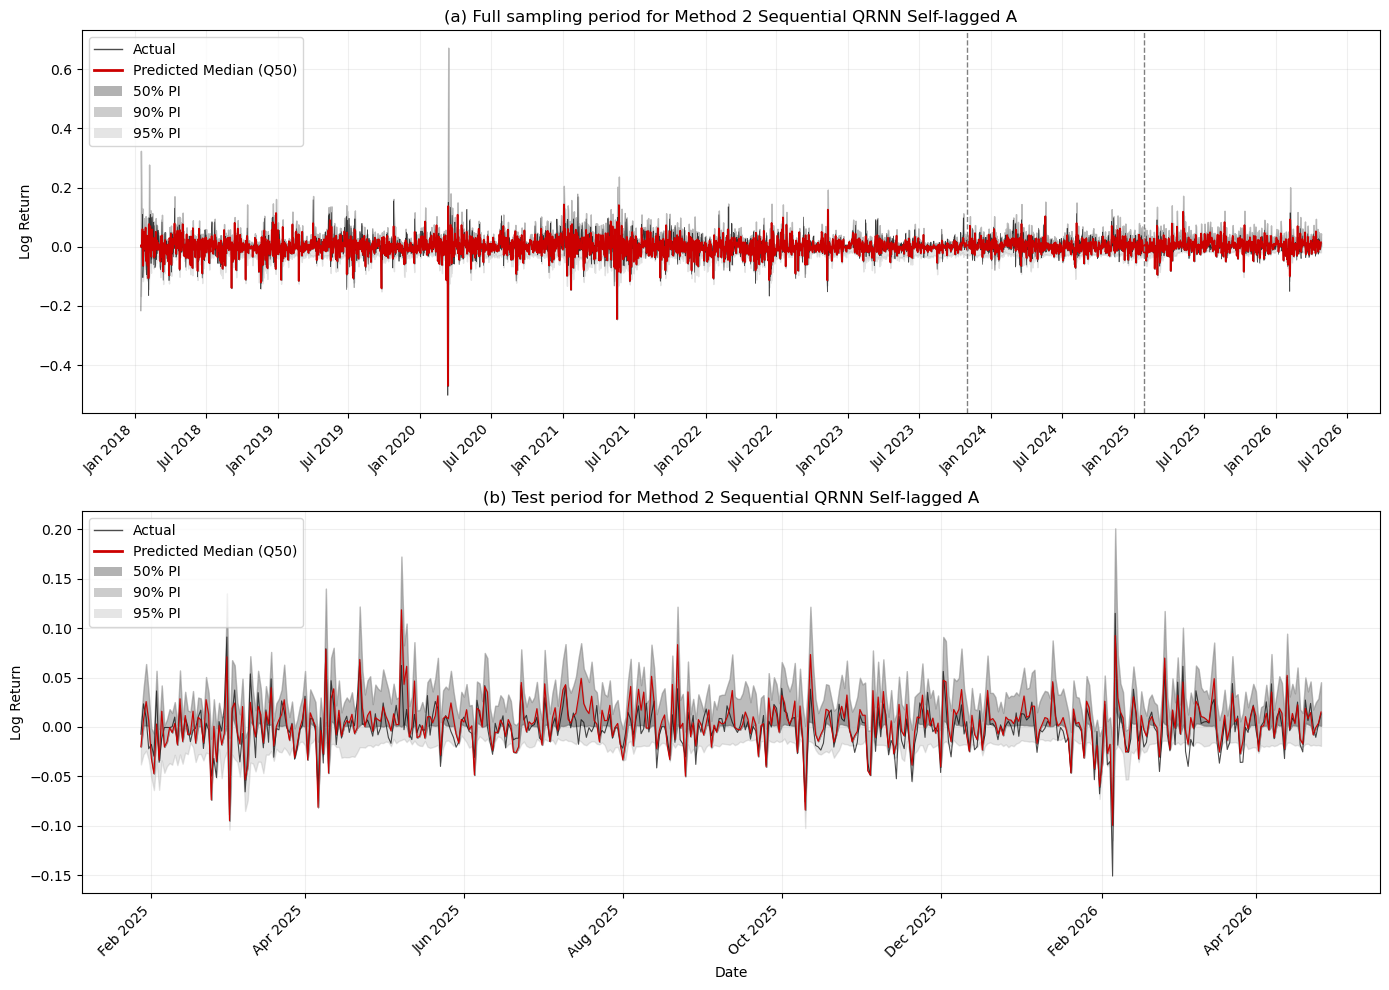

Plot saved to method2_sequential_qrnn_a_self_predictions.png

TEST METRICS — METHOD 2 SEQUENTIAL QRNN A SELF-LAGGED
   alpha           NLL      Hit Rate           HRE
   0.025     -1.919361      0.090308      0.065308
   0.050     -1.545417      0.422907      0.372907
   0.250     -2.666912      0.422907      0.172907
   0.500     -2.746618      0.654185      0.154185
   0.750     -2.752536      0.654185      0.095815
   0.950     -2.246062      0.995595      0.045595
   0.975     -2.274922      0.995595      0.020595

Average NLL: -2.307404
Average HRE: 0.132473

CROSSOVER ANALYSIS — METHOD 2 FINAL HYBRID OUTPUT
(0.025, 0.050): 0 (0.00%) <-- TAIL
(0.050, 0.250): 0 (0.00%)
(0.250, 0.500): 0 (0.00%)
(0.500, 0.750): 0 (0.00%)
(0.750, 0.950): 0 (0.00%)
(0.950, 0.975): 0 (0.00%) <-- TAIL

Total violations: 0 (0.00%)
Tail violations: 0 (0.00%)

Saved Method 2 outputs:
  method2_sequential_qrnn_a_self_predictions.png
  method2_sequential_qrnn_a_self_test_metrics.csv
  method2_sequential_qrnn

In [30]:
# ============================================================
# METHOD 2 PLOTTING
# SEQUENTIAL HYBRID QRNN — A SELF-LAGGED
# ============================================================

import os
import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

from matplotlib.patches import Patch
from matplotlib.lines import Line2D


# ------------------------------------------------------------
# Locate Method 2 checkpoint
# ------------------------------------------------------------

method2_checkpoint_filename = (
    'method2_sequential_qrnn_a_self_best.pt'
)

# Supports the filename from the previous tuning code
if not os.path.exists(
    method2_checkpoint_filename
):

    method2_checkpoint_filename = (
        'hybrid_qrnn_a_self_sequential_best.pt'
    )

if not os.path.exists(
    method2_checkpoint_filename
):
    raise FileNotFoundError(
        "Method 2 checkpoint was not found."
    )


# ------------------------------------------------------------
# Load Method 2 checkpoint
# ------------------------------------------------------------

method2_checkpoint = torch.load(
    method2_checkpoint_filename,
    map_location='cpu',
    weights_only=False
)

method2_alpha_levels = (
    method2_checkpoint['alpha_levels']
)

method2_estimation_order = (
    method2_checkpoint[
        'estimation_order'
    ]
)

method2_reference_level = (
    method2_checkpoint[
        'reference_level'
    ]
)

method2_constraint_direction = (
    method2_checkpoint[
        'constraint_direction'
    ]
)

# Restore constants used by the model class
DELTA = method2_checkpoint['delta']
SMOOTH_A = method2_checkpoint['smooth_a']
PSI_MARGIN = method2_checkpoint[
    'psi_margin'
]

print(
    "Loaded Method 2 checkpoint:",
    method2_checkpoint_filename
)

print(
    "Estimation order:",
    method2_estimation_order
)


# ------------------------------------------------------------
# Reconstruct all seven models
# ------------------------------------------------------------

method2_sequential_models = {}

for alpha in method2_estimation_order:

    saved_model = (
        method2_checkpoint['models'][
            str(alpha)
        ]
    )

    config = saved_model['config']
    direction = saved_model['direction']

    model = SequentialHybridQRNNSelfA(
        input_dim=X_train.shape[1],
        config=config,
        direction=direction
    )

    model.load_state_dict(
        saved_model['model_state_dict']
    )

    model.eval()

    method2_sequential_models[
        alpha
    ] = model

print(
    f"Loaded {len(method2_sequential_models)} "
    f"sequential models."
)


# ------------------------------------------------------------
# Full-sample tensors
# ------------------------------------------------------------

method2_X_all = torch.tensor(
    df[feature_cols].values,
    dtype=torch.float32
)

method2_y_all = torch.tensor(
    df['log_return'].values,
    dtype=torch.float32
)

method2_train_size = len(train_df)
method2_val_size = len(val_df)

method2_test_start = (
    method2_train_size
    + method2_val_size
)


# ------------------------------------------------------------
# Sequential full-sample forecasting
# ------------------------------------------------------------

method2_all_predictions = {}
method2_raw_fnn_outputs = {}
method2_constrained_fnn_outputs = {}
method2_caviar_outputs = {}
method2_sigma = {}

with torch.no_grad():

    for alpha in method2_estimation_order:

        ref_alpha = (
            method2_reference_level[
                alpha
            ]
        )

        if ref_alpha is None:

            q_reference = None

        else:

            q_reference = (
                method2_all_predictions[
                    ref_alpha
                ]
            )

        model = (
            method2_sequential_models[
                alpha
            ]
        )

        (
            q_prediction,
            q_caviar,
            f_raw,
            f_constrained,
            sigma
        ) = model(
            method2_y_all,
            method2_X_all,
            q_reference
        )

        method2_all_predictions[
            alpha
        ] = q_prediction.detach()

        method2_caviar_outputs[
            alpha
        ] = q_caviar.detach()

        method2_raw_fnn_outputs[
            alpha
        ] = f_raw.detach()

        method2_constrained_fnn_outputs[
            alpha
        ] = (
            f_constrained.detach()
        )

        method2_sigma[
            alpha
        ] = sigma.detach()


# ------------------------------------------------------------
# Convert test forecasts to NumPy
# ------------------------------------------------------------

method2_test_predictions = {}

for alpha in method2_alpha_levels:

    method2_test_predictions[
        alpha
    ] = (
        method2_all_predictions[
            alpha
        ][method2_test_start:]
        .cpu()
        .numpy()
    )

method2_y_test = (
    method2_y_all[
        method2_test_start:
    ]
    .cpu()
    .numpy()
)

method2_test_dates = test_df.index
method2_all_dates = df.index

if len(method2_test_dates) != len(
    method2_y_test
):
    raise ValueError(
        "The test date length does not match "
        "the extracted test predictions."
    )


# ============================================================
# Two-panel prediction plot
# ============================================================

method2_actual_color = '#000000'
method2_pred_color = '#CC0000'
method2_pi_color = '#808080'

method2_legend = [
    Line2D(
        [0], [0],
        color=method2_actual_color,
        lw=1,
        alpha=0.7,
        label='Actual'
    ),
    Line2D(
        [0], [0],
        color=method2_pred_color,
        lw=2,
        label='Predicted Median (Q50)'
    ),
    Patch(
        facecolor=method2_pi_color,
        alpha=0.6,
        label='50% PI'
    ),
    Patch(
        facecolor=method2_pi_color,
        alpha=0.4,
        label='90% PI'
    ),
    Patch(
        facecolor=method2_pi_color,
        alpha=0.2,
        label='95% PI'
    )
]

fig, axes = plt.subplots(
    2,
    1,
    figsize=(14, 10)
)


# ------------------------------------------------------------
# Panel (a): full sample
# ------------------------------------------------------------

ax = axes[0]

ax.plot(
    method2_all_dates,
    method2_y_all.cpu().numpy(),
    color=method2_actual_color,
    linewidth=0.5,
    alpha=0.7
)

ax.plot(
    method2_all_dates,
    method2_all_predictions[
        0.500
    ].cpu().numpy(),
    color=method2_pred_color,
    linewidth=1.2
)

ax.fill_between(
    method2_all_dates,
    method2_all_predictions[
        0.025
    ].cpu().numpy(),
    method2_all_predictions[
        0.975
    ].cpu().numpy(),
    color=method2_pi_color,
    alpha=0.2
)

ax.fill_between(
    method2_all_dates,
    method2_all_predictions[
        0.050
    ].cpu().numpy(),
    method2_all_predictions[
        0.950
    ].cpu().numpy(),
    color=method2_pi_color,
    alpha=0.4
)

ax.fill_between(
    method2_all_dates,
    method2_all_predictions[
        0.250
    ].cpu().numpy(),
    method2_all_predictions[
        0.750
    ].cpu().numpy(),
    color=method2_pi_color,
    alpha=0.6
)

ax.axvline(
    train_df.index[-1],
    color='gray',
    linestyle='--',
    linewidth=1
)

ax.axvline(
    val_df.index[-1],
    color='gray',
    linestyle='--',
    linewidth=1
)

ax.set_title(
    '(a) Full sampling period for Method 2 '
    'Sequential QRNN Self-lagged A',
    fontsize=12
)

ax.set_ylabel('Log Return')

ax.legend(
    handles=method2_legend,
    loc='upper left'
)

ax.grid(True, alpha=0.2)

ax.xaxis.set_major_formatter(
    mdates.DateFormatter('%b %Y')
)

ax.xaxis.set_major_locator(
    mdates.MonthLocator(interval=6)
)

plt.setp(
    ax.xaxis.get_majorticklabels(),
    rotation=45,
    ha='right'
)


# ------------------------------------------------------------
# Panel (b): test period
# ------------------------------------------------------------

ax2 = axes[1]

ax2.plot(
    method2_test_dates,
    method2_y_test,
    color=method2_actual_color,
    linewidth=0.8,
    alpha=0.7
)

ax2.plot(
    method2_test_dates,
    method2_test_predictions[
        0.500
    ],
    color=method2_pred_color,
    linewidth=0.8
)

ax2.fill_between(
    method2_test_dates,
    method2_test_predictions[
        0.025
    ],
    method2_test_predictions[
        0.975
    ],
    color=method2_pi_color,
    alpha=0.2
)

ax2.fill_between(
    method2_test_dates,
    method2_test_predictions[
        0.050
    ],
    method2_test_predictions[
        0.950
    ],
    color=method2_pi_color,
    alpha=0.4
)

ax2.fill_between(
    method2_test_dates,
    method2_test_predictions[
        0.250
    ],
    method2_test_predictions[
        0.750
    ],
    color=method2_pi_color,
    alpha=0.6
)

ax2.set_title(
    '(b) Test period for Method 2 '
    'Sequential QRNN Self-lagged A',
    fontsize=12
)

ax2.set_xlabel('Date')
ax2.set_ylabel('Log Return')

ax2.legend(
    handles=method2_legend,
    loc='upper left'
)

ax2.grid(True, alpha=0.2)

ax2.xaxis.set_major_formatter(
    mdates.DateFormatter('%b %Y')
)

ax2.xaxis.set_major_locator(
    mdates.MonthLocator(interval=2)
)

plt.setp(
    ax2.xaxis.get_majorticklabels(),
    rotation=45,
    ha='right'
)

plt.tight_layout()

method2_plot_filename = (
    'method2_sequential_qrnn_a_self_'
    'predictions.png'
)

plt.savefig(
    method2_plot_filename,
    dpi=300,
    bbox_inches='tight'
)

plt.show()
plt.close()

print(
    f"Plot saved to "
    f"{method2_plot_filename}"
)


# ============================================================
# Test metrics
# ============================================================

def method2_qrnn_a_self_test_metrics(
    y_test,
    test_predictions,
    sigma_values,
    alpha_levels
):

    y_tensor = torch.tensor(
        y_test,
        dtype=torch.float32
    )

    nll_values = []
    hit_rates = []
    hre_values = []

    print("\n" + "=" * 70)
    print(
        "TEST METRICS — METHOD 2 SEQUENTIAL "
        "QRNN A SELF-LAGGED"
    )
    print("=" * 70)

    print(
        f"{'alpha':>8}"
        f"{'NLL':>14}"
        f"{'Hit Rate':>14}"
        f"{'HRE':>14}"
    )

    for alpha in alpha_levels:

        q_tensor = torch.tensor(
            test_predictions[alpha],
            dtype=torch.float32
        )

        sigma = sigma_values[
            alpha
        ].cpu()

        test_nll = hybrid_qrnn_loss(
            y_tensor,
            q_tensor,
            sigma,
            alpha
        ).item()

        hit_rate = np.mean(
            y_test
            <= test_predictions[alpha]
        )

        hre = abs(
            hit_rate - alpha
        )

        nll_values.append(
            test_nll
        )

        hit_rates.append(
            hit_rate
        )

        hre_values.append(
            hre
        )

        print(
            f"{alpha:>8.3f}"
            f"{test_nll:>14.6f}"
            f"{hit_rate:>14.6f}"
            f"{hre:>14.6f}"
        )

    average_nll = np.mean(
        nll_values
    )

    average_hre = np.mean(
        hre_values
    )

    print(
        f"\nAverage NLL: "
        f"{average_nll:.6f}"
    )

    print(
        f"Average HRE: "
        f"{average_hre:.6f}"
    )

    return {
        'nll_by_level': nll_values,
        'hit_rate_by_level': hit_rates,
        'hre_by_level': hre_values,
        'average_nll': average_nll,
        'average_hre': average_hre
    }


method2_test_metrics = (
    method2_qrnn_a_self_test_metrics(
        y_test=method2_y_test,
        test_predictions=
            method2_test_predictions,
        sigma_values=method2_sigma,
        alpha_levels=
            method2_alpha_levels
    )
)


# ============================================================
# Final hybrid crossover analysis
# ============================================================

def method2_crossover_analysis(
    test_predictions,
    alpha_levels
):

    T = len(
        test_predictions[
            alpha_levels[0]
        ]
    )

    adjacent_pairs = [
        (0.025, 0.050),
        (0.050, 0.250),
        (0.250, 0.500),
        (0.500, 0.750),
        (0.750, 0.950),
        (0.950, 0.975)
    ]

    tail_pairs = [
        (0.025, 0.050),
        (0.950, 0.975)
    ]

    total_violations = 0
    tail_violations = 0
    crossover_records = []

    print("\n" + "=" * 70)
    print(
        "CROSSOVER ANALYSIS — METHOD 2 "
        "FINAL HYBRID OUTPUT"
    )
    print("=" * 70)

    for lower, upper in adjacent_pairs:

        lower_prediction = (
            test_predictions[lower]
        )

        upper_prediction = (
            test_predictions[upper]
        )

        violations = int(
            np.sum(
                lower_prediction
                > upper_prediction
            )
        )

        percentage = (
            violations / T * 100
        )

        is_tail = (
            lower,
            upper
        ) in tail_pairs

        marker = (
            " <-- TAIL"
            if is_tail
            else ""
        )

        print(
            f"({lower:.3f}, "
            f"{upper:.3f}): "
            f"{violations} "
            f"({percentage:.2f}%)"
            f"{marker}"
        )

        total_violations += (
            violations
        )

        if is_tail:
            tail_violations += (
                violations
            )

        crossover_records.append({
            'lower_alpha': lower,
            'upper_alpha': upper,
            'violations': violations,
            'percentage': percentage,
            'is_tail': is_tail
        })

    total_rate = (
        total_violations
        / (T * 6)
        * 100
    )

    tail_rate = (
        tail_violations
        / (T * 2)
        * 100
    )

    print(
        f"\nTotal violations: "
        f"{total_violations} "
        f"({total_rate:.2f}%)"
    )

    print(
        f"Tail violations: "
        f"{tail_violations} "
        f"({tail_rate:.2f}%)"
    )

    return {
        'records': crossover_records,
        'total_violations':
            total_violations,
        'total_rate':
            total_rate,
        'tail_violations':
            tail_violations,
        'tail_rate':
            tail_rate
    }


method2_crossover_results = (
    method2_crossover_analysis(
        test_predictions=
            method2_test_predictions,
        alpha_levels=
            method2_alpha_levels
    )
)


# ============================================================
# Save Method 2 test metrics
# ============================================================

method2_metrics_df = pd.DataFrame({
    'alpha':
        method2_alpha_levels,

    'NLL':
        method2_test_metrics[
            'nll_by_level'
        ],

    'Hit_Rate':
        method2_test_metrics[
            'hit_rate_by_level'
        ],

    'HRE':
        method2_test_metrics[
            'hre_by_level'
        ]
})

method2_metrics_filename = (
    'method2_sequential_qrnn_a_self_'
    'test_metrics.csv'
)

method2_metrics_df.to_csv(
    method2_metrics_filename,
    index=False
)


# ------------------------------------------------------------
# Save crossover results
# ------------------------------------------------------------

method2_crossover_df = pd.DataFrame(
    method2_crossover_results[
        'records'
    ]
)

method2_crossover_filename = (
    'method2_sequential_qrnn_a_self_'
    'crossover.csv'
)

method2_crossover_df.to_csv(
    method2_crossover_filename,
    index=False
)


print("\nSaved Method 2 outputs:")

print(
    f"  {method2_plot_filename}"
)

print(
    f"  {method2_metrics_filename}"
)

print(
    f"  {method2_crossover_filename}"
)

See the problem of straight line, we look into more details about the overlapped lines

In [36]:
# ============================================================
# Detailed test-period quantile predictions
# ============================================================

method2_prediction_table = pd.DataFrame({
    'Date': pd.to_datetime(method2_test_dates),
    'Actual': method2_y_test,
    'Q025': method2_test_predictions[0.025],
    'Q050': method2_test_predictions[0.050],
    'Q250': method2_test_predictions[0.250],
    'Q500': method2_test_predictions[0.500],
    'Q750': method2_test_predictions[0.750],
    'Q950': method2_test_predictions[0.950],
    'Q975': method2_test_predictions[0.975]
})

# Add the six adjacent quantile gaps
method2_prediction_table['Gap_025_050'] = (
    method2_prediction_table['Q050']
    - method2_prediction_table['Q025']
)

method2_prediction_table['Gap_050_250'] = (
    method2_prediction_table['Q250']
    - method2_prediction_table['Q050']
)

method2_prediction_table['Gap_250_500'] = (
    method2_prediction_table['Q500']
    - method2_prediction_table['Q250']
)

method2_prediction_table['Gap_500_750'] = (
    method2_prediction_table['Q750']
    - method2_prediction_table['Q500']
)

method2_prediction_table['Gap_750_950'] = (
    method2_prediction_table['Q950']
    - method2_prediction_table['Q750']
)

method2_prediction_table['Gap_950_975'] = (
    method2_prediction_table['Q975']
    - method2_prediction_table['Q950']
)

gap_columns = [
    'Gap_025_050',
    'Gap_050_250',
    'Gap_250_500',
    'Gap_500_750',
    'Gap_750_950',
    'Gap_950_975'
]

method2_prediction_table['Minimum_Gap'] = (
    method2_prediction_table[gap_columns].min(axis=1)
)

# Indicates levels that will visually appear overlapped
overlap_tolerance = 1e-5

method2_prediction_table['Near_Overlap'] = (
    method2_prediction_table['Minimum_Gap']
    <= overlap_tolerance
)

# Improve displayed formatting
method2_prediction_table_display = (
    method2_prediction_table.copy()
)

method2_prediction_table_display['Date'] = (
    method2_prediction_table_display['Date']
    .dt.strftime('%Y-%m-%d')
)

numeric_columns = (
    ['Actual', 'Q025', 'Q050', 'Q250',
     'Q500', 'Q750', 'Q950', 'Q975']
    + gap_columns
    + ['Minimum_Gap']
)

method2_prediction_table_display[numeric_columns] = (
    method2_prediction_table_display[numeric_columns]
    .round(8)
)

# Display the complete table clearly in Jupyter
display(
    method2_prediction_table_display.style
    .format({
        column: '{:.8f}'
        for column in numeric_columns
    })
    .set_properties(**{
        'text-align': 'center',
        'font-size': '10pt'
    })
    .set_table_styles([
        {
            'selector': 'th',
            'props': [
                ('text-align', 'center'),
                ('background-color', '#D9EAF7'),
                ('font-weight', 'bold')
            ]
        },
        {
            'selector': 'tr:hover',
            'props': [
                ('background-color', '#FFF4CC')
            ]
        }
    ])
)

# Save the complete unrounded table
method2_prediction_table.to_csv(
    'method2_qrnn_a_self_test_predictions_detailed.csv',
    index=False
)

print(
    '\nDetailed prediction table saved to: '
    'method2_qrnn_a_self_test_predictions_detailed.csv'
)

,Date,Actual,Q025,Q050,Q250,Q500,Q750,Q950,Q975,Gap_025_050,Gap_050_250,Gap_250_500,Gap_500_750,Gap_750_950,Gap_950_975,Minimum_Gap,Near_Overlap
0,2025-01-28,-0.00734755,-0.03792428,-0.02006782,-0.02006682,-0.02006582,-0.02006482,0.00571465,0.00571565,0.01785646,0.00000100,0.00000100,0.00000100,0.02577947,0.00000100,0.00000100,True
1,2025-01-29,0.02338561,-0.02788097,0.00145777,0.00145877,0.00744693,0.00744793,0.03847542,0.03847642,0.02933874,0.00000100,0.00598816,0.00000100,0.03102750,0.00000099,0.00000099,True
2,2025-01-30,0.00949559,-0.02404409,0.00170142,0.00170242,0.02573486,0.02573586,0.06371750,0.06371852,0.02574552,0.00000100,0.02403244,0.00000100,0.03798164,0.00000101,0.00000100,True
3,2025-01-31,-0.02214285,-0.03341102,0.00116258,0.00116358,0.00646388,0.00646488,0.03338535,0.03338634,0.03457360,0.00000100,0.00530031,0.00000100,0.02692046,0.00000100,0.00000100,True
4,2025-02-01,-0.01766877,-0.05165508,-0.03165177,-0.03165077,-0.03164977,-0.03164877,-0.00139779,-0.00139679,0.02000331,0.00000100,0.00000100,0.00000100,0.03025098,0.00000100,0.00000100,True
5,2025-02-02,-0.02959897,-0.06397315,-0.04726090,-0.04725990,-0.04725890,-0.04725790,-0.00660986,-0.00660886,0.01671226,0.00000099,0.00000100,0.00000100,0.04064805,0.00000100,0.00000099,True
6,2025-02-03,0.03646032,-0.03400998,0.00297669,0.00297769,0.00298175,0.00298275,0.05686125,0.05686225,0.03698666,0.00000100,0.00000406,0.00000100,0.05387850,0.00000100,0.00000100,True
7,2025-02-04,-0.03582040,-0.06370157,-0.03354487,-0.03354387,-0.03354287,-0.03354188,-0.00193577,-0.00193477,0.03015670,0.00000100,0.00000100,0.00000099,0.03160611,0.00000100,0.00000099,True
8,2025-02-05,-0.01184010,-0.03389084,0.00515090,0.00515190,0.01596068,0.01596168,0.04200418,0.04200518,0.03904174,0.00000100,0.01080878,0.00000100,0.02604250,0.00000100,0.00000100,True
9,2025-02-06,-0.00060135,-0.04653176,-0.02026448,-0.02026348,-0.02026248,-0.02026148,0.00123748,0.00123848,0.02626728,0.00000100,0.00000100,0.00000100,0.02149896,0.00000100,0.00000100,True



Detailed prediction table saved to: method2_qrnn_a_self_test_predictions_detailed.csv


the unconstrained predictions frequently violate the required ordering. The constraint then replaces them with q+epsilon

# Cross over dealing 3

First we try the specfication 1

In [39]:
import copy

import numpy as np
import optuna
import pandas as pd
import torch
import torch.nn as nn
import torch.nn.functional as F
from optuna.samplers import TPESampler


# ============================================================
# METHOD 3 -- SPECIFICATION 1
# SEQUENTIAL QRNN A SELF-LAGGED WITH LEARNED SPACING
# Median: original hybrid QRNN
# Non-median levels: q_k = q_reference +/- delta_k,t
# delta_k,t = softplus(raw_delta_k,t) > 0
# ============================================================

m3_spacing_alpha_levels = [
    0.025, 0.050, 0.250, 0.500, 0.750, 0.950, 0.975
]

m3_spacing_estimation_order = [
    0.500, 0.750, 0.950, 0.975, 0.250, 0.050, 0.025
]

m3_spacing_reference_level = {
    0.500: None,
    0.750: 0.500,
    0.950: 0.750,
    0.975: 0.950,
    0.250: 0.500,
    0.050: 0.250,
    0.025: 0.050,
}

m3_spacing_direction = {
    0.500: None,
    0.750: 'upper',
    0.950: 'upper',
    0.975: 'upper',
    0.250: 'lower',
    0.050: 'lower',
    0.025: 'lower',
}

M3_SPACING_N_TRIALS = 200
M3_SPACING_MAX_EPOCHS = 200
M3_SPACING_BASE_SEED = 2026
M3_SPACING_PSI_MARGIN = 1e-4


class M3SpacingQRNNSelfA(nn.Module):
    def __init__(self, input_dim, config, direction=None):
        super().__init__()

        self.direction = direction

        # These parameters are required only for the median hybrid model.
        if direction is None:
            self.beta1_raw = nn.Parameter(torch.tensor(1.386))
            self.beta2_raw = nn.Parameter(torch.tensor(0.3))
            self.beta3_raw = nn.Parameter(torch.tensor(0.3))
            self.psi_raw = nn.Parameter(torch.tensor(0.0))

        self.sigma_raw = nn.Parameter(torch.tensor(0.5))

        # Each non-median spacing network also receives its frozen
        # adjacent reference forecast as an input.
        fnn_input_dim = input_dim if direction is None else input_dim + 1
        layers = []
        prev_dim = fnn_input_dim

        for i in range(config['n_hidden_layers']):
            hidden_dim = config[f'hidden_dim_{i}']
            layers.append(nn.Linear(prev_dim, hidden_dim))

            if config['layernorm']:
                layers.append(nn.LayerNorm(hidden_dim))

            layers.append(self._get_activation(config['activation']))

            if config['dropout'] > 0:
                layers.append(nn.Dropout(config['dropout']))

            prev_dim = hidden_dim

        layers.append(nn.Linear(prev_dim, 1))
        self.fnn = nn.Sequential(*layers)

        for module in self.fnn.modules():
            if isinstance(module, nn.Linear):
                if config['weight_init'] == 'glorot':
                    nn.init.xavier_uniform_(module.weight)
                elif config['weight_init'] == 'he':
                    nn.init.kaiming_uniform_(module.weight)

                if module.bias is not None:
                    nn.init.zeros_(module.bias)

        # softplus(0) is about 0.693, which is too large for daily returns.
        # A negative trainable output bias gives a sensible starting gap;
        # it is an initialisation, not a fixed spacing constraint.
        if direction is not None:
            nn.init.constant_(self.fnn[-1].bias, -4.6)

    def _get_activation(self, name):
        return {
            'relu': nn.ReLU(),
            'elu': nn.ELU(),
            'gelu': nn.GELU(),
            'tanh': nn.Tanh(),
        }.get(name, nn.ReLU())

    def forward(
        self,
        y,
        X,
        q_reference=None,
        initial_caviar=None,
        initial_y=None,
    ):
        sigma = F.softplus(self.sigma_raw) + 1e-6

        # ----------------------------------------------------
        # Median: original Hybrid QRNN A self-lagged model
        # ----------------------------------------------------
        if self.direction is None:
            beta1 = torch.sigmoid(self.beta1_raw)
            beta2 = F.softplus(self.beta2_raw)
            beta3 = F.softplus(self.beta3_raw)
            psi = (
                1.0 - M3_SPACING_PSI_MARGIN
            ) * torch.sigmoid(self.psi_raw)

            f_median = self.fnn(X).squeeze(-1)

            if (initial_caviar is None) != (initial_y is None):
                raise ValueError(
                    'initial_caviar and initial_y must be supplied together.'
                )

            has_initial_state = initial_caviar is not None
            previous_caviar = (
                initial_caviar
                if has_initial_state
                else torch.zeros((), dtype=y.dtype, device=y.device)
            )

            q_list = []
            caviar_list = []

            for t in range(len(y)):
                if t == 0 and not has_initial_state:
                    caviar_t = torch.zeros(
                        (), dtype=y.dtype, device=y.device
                    )
                    q_t = torch.zeros((), dtype=y.dtype, device=y.device)
                else:
                    previous_y = initial_y if t == 0 else y[t - 1]
                    y_pos = torch.clamp(previous_y, min=0)
                    y_neg = torch.clamp(-previous_y, min=0)

                    caviar_t = (
                        beta1 * previous_caviar
                        + beta2 * y_pos
                        + beta3 * y_neg
                    )
                    q_t = psi * caviar_t + (1.0 - psi) * f_median[t]

                caviar_list.append(caviar_t)
                q_list.append(q_t)
                previous_caviar = caviar_t

            q_prediction = torch.stack(q_list)
            caviar_output = torch.stack(caviar_list)

            # The fourth output is None because the median does not
            # produce an adjacent spacing.
            return q_prediction, caviar_output, f_median, None, sigma

        # ----------------------------------------------------
        # Non-median: directly model a positive adjacent gap
        # ----------------------------------------------------
        if q_reference is None:
            raise ValueError(
                'A reference forecast is required for non-median levels.'
            )

        q_reference = q_reference.detach()
        fnn_input = torch.cat([X, q_reference.unsqueeze(1)], dim=1)
        raw_delta = self.fnn(fnn_input).squeeze(-1)
        delta = F.softplus(raw_delta)

        if self.direction == 'upper':
            q_prediction = q_reference + delta
        elif self.direction == 'lower':
            q_prediction = q_reference - delta
        else:
            raise ValueError("direction must be None, 'upper', or 'lower'.")

        # The statistical output is not defined for a pure spacing model.
        zero_statistical_output = torch.zeros_like(q_prediction)

        return (
            q_prediction,
            zero_statistical_output,
            raw_delta,
            delta,
            sigma,
        )


def m3_spacing_qrnn_loss(y, q, sigma, alpha):
    residual = y - q
    indicator = (residual < 0).float()
    rho = residual * (alpha - indicator)
    alpha_constant = torch.tensor(
        alpha * (1.0 - alpha), dtype=y.dtype, device=y.device
    )

    return (
        -torch.log(alpha_constant)
        + torch.log(sigma)
        + rho / sigma
    ).mean()


def m3_spacing_compute_crp(y, q, alpha):
    if alpha <= 0.5:
        empirical = (y <= q).float().mean().item()
        alpha_star = alpha
    else:
        empirical = (y > q).float().mean().item()
        alpha_star = 1.0 - alpha

    crp = empirical / alpha_star
    return crp, (crp - 1.0) ** 2


def m3_spacing_suggest_config(trial):
    config = {
        'n_hidden_layers': trial.suggest_int('n_hidden_layers', 1, 3),
        'activation': trial.suggest_categorical(
            'activation', ['relu', 'elu', 'gelu', 'tanh']
        ),
        'dropout': trial.suggest_float('dropout', 0.0, 0.5),
        'layernorm': trial.suggest_categorical('layernorm', [True, False]),
        'weight_init': trial.suggest_categorical(
            'weight_init', ['glorot', 'he']
        ),
        'lr': trial.suggest_float('lr', 1e-4, 5e-2, log=True),
        'optimizer': trial.suggest_categorical(
            'optimizer', ['adam', 'adamw']
        ),
        'weight_decay': trial.suggest_float('weight_decay', 0.0, 1e-4),
        'gradient_clip': trial.suggest_categorical(
            'gradient_clip', [0.1, 1.0, 5.0]
        ),
        'patience': trial.suggest_categorical('patience', [10, 20, 30]),
    }

    for i in range(config['n_hidden_layers']):
        config[f'hidden_dim_{i}'] = trial.suggest_int(
            f'hidden_dim_{i}', 32, 256
        )

    return config


def m3_spacing_make_optimizer(model, config):
    optimizer_class = (
        torch.optim.Adam
        if config['optimizer'] == 'adam'
        else torch.optim.AdamW
    )
    return optimizer_class(
        model.parameters(),
        lr=config['lr'],
        weight_decay=config['weight_decay'],
    )


def m3_spacing_train_config(
    config,
    alpha,
    direction,
    q_reference_train=None,
    q_reference_val=None,
    seed=2026,
):
    torch.manual_seed(seed)

    model = M3SpacingQRNNSelfA(
        input_dim=X_train.shape[1],
        config=config,
        direction=direction,
    )
    optimizer = m3_spacing_make_optimizer(model, config)
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
        optimizer, mode='min', patience=10, factor=0.5, min_lr=1e-6
    )

    best_val_loss = float('inf')
    patience_counter = 0
    best_model_state = None

    for epoch in range(M3_SPACING_MAX_EPOCHS):
        model.train()
        optimizer.zero_grad()

        q_train, _, _, _, sigma = model(
            y_train, X_train, q_reference_train
        )
        train_loss = m3_spacing_qrnn_loss(
            y_train[1:], q_train[1:], sigma, alpha
        )

        if torch.isnan(train_loss) or torch.isinf(train_loss):
            return None

        train_loss.backward()
        nn.utils.clip_grad_norm_(
            model.parameters(), config['gradient_clip']
        )
        optimizer.step()

        model.eval()
        with torch.no_grad():
            if direction is None:
                _, caviar_train, _, _, _ = model(y_train, X_train)
                q_val, _, _, _, sigma_val = model(
                    y_val,
                    X_val,
                    initial_caviar=caviar_train[-1],
                    initial_y=y_train[-1],
                )
            else:
                q_val, _, _, _, sigma_val = model(
                    y_val, X_val, q_reference_val
                )

            val_loss = m3_spacing_qrnn_loss(
                y_val, q_val, sigma_val, alpha
            )

        scheduler.step(val_loss.item())

        if val_loss.item() < best_val_loss:
            best_val_loss = val_loss.item()
            patience_counter = 0
            best_model_state = copy.deepcopy(model.state_dict())
        else:
            patience_counter += 1
            if patience_counter >= config['patience']:
                break

    if best_model_state is None:
        return None

    model.load_state_dict(best_model_state)
    return model


def m3_spacing_predict_train_val(
    model,
    direction,
    q_reference_train=None,
    q_reference_val=None,
):
    model.eval()

    with torch.no_grad():
        q_train, caviar_train, _, delta_train, _ = model(
            y_train, X_train, q_reference_train
        )

        if direction is None:
            q_val, _, _, delta_val, sigma = model(
                y_val,
                X_val,
                initial_caviar=caviar_train[-1],
                initial_y=y_train[-1],
            )
        else:
            q_val, _, _, delta_val, sigma = model(
                y_val, X_val, q_reference_val
            )

    return (
        q_train.detach(),
        q_val.detach(),
        None if delta_train is None else delta_train.detach(),
        None if delta_val is None else delta_val.detach(),
        sigma.detach(),
    )


def m3_spacing_evaluate(
    model,
    alpha,
    direction,
    q_reference_train=None,
    q_reference_val=None,
):
    _, q_val, _, delta_val, sigma = m3_spacing_predict_train_val(
        model,
        direction,
        q_reference_train,
        q_reference_val,
    )
    nll = m3_spacing_qrnn_loss(y_val, q_val, sigma, alpha).item()
    crp, crp_penalty = m3_spacing_compute_crp(y_val, q_val, alpha)

    metrics = {
        'nll': nll,
        'crp': crp,
        'crp_penalty': crp_penalty,
        'sigma': (F.softplus(model.sigma_raw) + 1e-6).item(),
    }

    if direction is None:
        metrics.update({
            'beta1': torch.sigmoid(model.beta1_raw).item(),
            'beta2': F.softplus(model.beta2_raw).item(),
            'beta3': F.softplus(model.beta3_raw).item(),
            'psi': (
                (1.0 - M3_SPACING_PSI_MARGIN)
                * torch.sigmoid(model.psi_raw)
            ).item(),
            'mean_delta': np.nan,
            'min_delta': np.nan,
            'max_delta': np.nan,
        })
    else:
        metrics.update({
            'beta1': np.nan,
            'beta2': np.nan,
            'beta3': np.nan,
            'psi': np.nan,
            'mean_delta': delta_val.mean().item(),
            'min_delta': delta_val.min().item(),
            'max_delta': delta_val.max().item(),
        })

    return metrics


def m3_spacing_select_by_rank(study):
    trials = [
        trial
        for trial in study.trials
        if trial.state == optuna.trial.TrialState.COMPLETE
        and trial.value is not None
        and np.isfinite(trial.value)
        and 'nll' in trial.user_attrs
        and 'crp_penalty' in trial.user_attrs
    ]

    if not trials:
        raise RuntimeError('No valid completed Optuna trials.')

    for trial in trials:
        trial._nll = trial.user_attrs['nll']
        trial._crp_penalty = trial.user_attrs['crp_penalty']

    for rank, trial in enumerate(
        sorted(trials, key=lambda item: item._nll), start=1
    ):
        trial._rank_nll = rank

    for rank, trial in enumerate(
        sorted(trials, key=lambda item: item._crp_penalty), start=1
    ):
        trial._rank_crp = rank

    best = min(
        trials,
        key=lambda trial: (
            trial._rank_nll + trial._rank_crp,
            trial._nll,
            trial._crp_penalty,
            trial.number,
        ),
    )
    return best, trials


# ============================================================
# Sequential tuning
# ============================================================

m3_spacing_final_models = {}
m3_spacing_best_configs = {}
m3_spacing_validation_metrics = {}
m3_spacing_train_predictions = {}
m3_spacing_val_predictions = {}
m3_spacing_train_deltas = {}
m3_spacing_val_deltas = {}


for order_index, alpha in enumerate(m3_spacing_estimation_order):
    reference_alpha = m3_spacing_reference_level[alpha]
    direction = m3_spacing_direction[alpha]
    level_seed = M3_SPACING_BASE_SEED + order_index

    if reference_alpha is None:
        q_reference_train = None
        q_reference_val = None
    else:
        q_reference_train = m3_spacing_train_predictions[
            reference_alpha
        ]
        q_reference_val = m3_spacing_val_predictions[
            reference_alpha
        ]

    def m3_spacing_objective(trial):
        config = m3_spacing_suggest_config(trial)
        model = m3_spacing_train_config(
            config=config,
            alpha=alpha,
            direction=direction,
            q_reference_train=q_reference_train,
            q_reference_val=q_reference_val,
            seed=level_seed,
        )

        if model is None:
            return float('inf')

        metrics = m3_spacing_evaluate(
            model,
            alpha,
            direction,
            q_reference_train,
            q_reference_val,
        )

        for name, value in metrics.items():
            trial.set_user_attr(name, value)

        print(
            f"Trial {trial.number}: alpha={alpha:.3f} | "
            f"NLL={metrics['nll']:.6f} | "
            f"CRP penalty={metrics['crp_penalty']:.6f} | "
            f"mean delta={metrics['mean_delta']:.6f}"
        )
        return metrics['nll']

    print('\n' + '=' * 72)
    print(
        f'Method 3 spacing QRNN A Self-lagged: alpha={alpha:.3f} | '
        f'reference={reference_alpha} | direction={direction}'
    )
    print('=' * 72)

    study = optuna.create_study(
        direction='minimize',
        sampler=TPESampler(seed=level_seed),
    )
    study.optimize(
        m3_spacing_objective,
        n_trials=M3_SPACING_N_TRIALS,
        show_progress_bar=True,
    )

    best_trial, all_trials = m3_spacing_select_by_rank(study)
    best_config = best_trial.params.copy()

    ranking_records = []
    for trial in all_trials:
        record = {
            'alpha': alpha,
            'trial': trial.number,
            'nll': trial._nll,
            'crp': trial.user_attrs['crp'],
            'crp_penalty': trial._crp_penalty,
            'rank_nll': trial._rank_nll,
            'rank_crp': trial._rank_crp,
            'sum_rank': trial._rank_nll + trial._rank_crp,
            'mean_delta': trial.user_attrs['mean_delta'],
            'min_delta': trial.user_attrs['min_delta'],
            'max_delta': trial.user_attrs['max_delta'],
            'beta1': trial.user_attrs['beta1'],
            'beta2': trial.user_attrs['beta2'],
            'beta3': trial.user_attrs['beta3'],
            'psi': trial.user_attrs['psi'],
            'sigma': trial.user_attrs['sigma'],
        }
        record.update(trial.params)
        ranking_records.append(record)

    ranking_df = pd.DataFrame(ranking_records).sort_values(
        ['sum_rank', 'nll', 'crp_penalty']
    )
    ranking_filename = (
        f'method3_spacing_qrnn_a_self_ranking_alpha_{alpha:.3f}.csv'
    )
    ranking_df.to_csv(ranking_filename, index=False)

    final_model = m3_spacing_train_config(
        config=best_config,
        alpha=alpha,
        direction=direction,
        q_reference_train=q_reference_train,
        q_reference_val=q_reference_val,
        seed=level_seed,
    )
    final_metrics = m3_spacing_evaluate(
        final_model,
        alpha,
        direction,
        q_reference_train,
        q_reference_val,
    )
    (
        q_train,
        q_val,
        delta_train,
        delta_val,
        _,
    ) = m3_spacing_predict_train_val(
        final_model,
        direction,
        q_reference_train,
        q_reference_val,
    )

    m3_spacing_final_models[alpha] = final_model
    m3_spacing_best_configs[alpha] = best_config
    m3_spacing_validation_metrics[alpha] = final_metrics
    m3_spacing_train_predictions[alpha] = q_train
    m3_spacing_val_predictions[alpha] = q_val
    m3_spacing_train_deltas[alpha] = delta_train
    m3_spacing_val_deltas[alpha] = delta_val

    print(f'Best trial: #{best_trial.number}')
    print(
        f"NLL rank={best_trial._rank_nll} | "
        f"CRP rank={best_trial._rank_crp} | "
        f"sum={best_trial._rank_nll + best_trial._rank_crp}"
    )
    print(
        f"Validation NLL={final_metrics['nll']:.6f} | "
        f"CRP={final_metrics['crp']:.6f} | "
        f"mean delta={final_metrics['mean_delta']:.6f}"
    )
    print(f'Ranking saved to: {ranking_filename}')


torch.save(
    {
        'model_name': 'Method 3 spacing QRNN A self-lagged',
        'specification': 'learned_positive_adjacent_spacing',
        'alpha_levels': m3_spacing_alpha_levels,
        'estimation_order': m3_spacing_estimation_order,
        'reference_level': m3_spacing_reference_level,
        'direction': m3_spacing_direction,
        'configs': m3_spacing_best_configs,
        'model_state_dicts': {
            alpha: model.state_dict()
            for alpha, model in m3_spacing_final_models.items()
        },
        'validation_metrics': m3_spacing_validation_metrics,
    },
    'method3_spacing_qrnn_a_self_best.pt',
)


print('\n' + '=' * 72)
print('TUNING COMPLETE -- METHOD 3 SPACING QRNN A SELF-LAGGED')
print('=' * 72)

for alpha in m3_spacing_alpha_levels:
    metrics = m3_spacing_validation_metrics[alpha]
    print(
        f"alpha={alpha:.3f} | NLL={metrics['nll']:.6f} | "
        f"CRP={metrics['crp']:.6f} | "
        f"mean delta={metrics['mean_delta']:.6f}"
    )

print('\nSaved: method3_spacing_qrnn_a_self_best.pt')

[I 2026-08-10 14:51:06,208] A new study created in memory with name: no-name-cf51d4ba-4e74-4663-a2a4-8e977b1cabbb



Method 3 spacing QRNN A Self-lagged: alpha=0.500 | reference=None | direction=None


  0%|          | 0/200 [00:00<?, ?it/s]

Trial 0: alpha=0.500 | NLL=1.292110 | CRP penalty=0.040354 | mean delta=nan
[I 2026-08-10 14:51:39,588] Trial 0 finished with value: 1.2921099662780762 and parameters: {'n_hidden_layers': 1, 'activation': 'elu', 'dropout': 0.49377524711883497, 'layernorm': False, 'weight_init': 'he', 'lr': 0.0006552020421842752, 'optimizer': 'adam', 'weight_decay': 8.940884610144999e-05, 'gradient_clip': 5.0, 'patience': 30, 'hidden_dim_0': 38}. Best is trial 0 with value: 1.2921099662780762.
Trial 1: alpha=0.500 | NLL=0.252295 | CRP penalty=0.066708 | mean delta=nan
[I 2026-08-10 14:52:10,105] Trial 1 finished with value: 0.2522948384284973 and parameters: {'n_hidden_layers': 1, 'activation': 'tanh', 'dropout': 0.07458356653667625, 'layernorm': False, 'weight_init': 'he', 'lr': 0.006969178688110181, 'optimizer': 'adam', 'weight_decay': 2.574006001095316e-05, 'gradient_clip': 1.0, 'patience': 30, 'hidden_dim_0': 102}. Best is trial 1 with value: 0.2522948384284973.
Trial 2: alpha=0.500 | NLL=1.402778 |

[I 2026-08-10 19:00:24,320] A new study created in memory with name: no-name-3fcab588-d215-46ca-bc0d-283e76ee6b2a


...

Trial 0: alpha=0.050 | NLL=1.972449 | CRP penalty=0.807221 | mean delta=0.007779
[I 2026-08-10 21:32:23,866] Trial 0 finished with value: 1.972448706626892 and parameters: {'n_hidden_layers': 2, 'activation': 'tanh', 'dropout': 0.11155263989652436, 'layernorm': False, 'weight_init': 'glorot', 'lr': 0.007027131382827591, 'optimizer': 'adam', 'weight_decay': 1.3627456384020455e-05, 'gradient_clip': 0.1, 'patience': 20, 'hidden_dim_0': 210, 'hidden_dim_1': 162}. Best is trial 0 with value: 1.972448706626892.
Trial 1: alpha=0.050 | NLL=0.703348 | CRP penalty=0.459283 | mean delta=0.009327
[I 2026-08-10 21:32:30,288] Trial 1 finished with value: 0.7033483386039734 and parameters: {'n_hidden_layers': 3, 'activation': 'elu', 'dropout': 0.09630890988459678, 'layernorm': False, 'weight_init': 'he', 'lr': 0.014080280114638532, 'optimizer': 'adam', 'weight_decay': 6.431370011304687e-05, 'gradient_clip': 0.1, 'patience': 10, 'hidden_dim_0': 88, 'hidden_dim_1': 196, 'hidden_dim_2': 94}. Best is tri

[I 2026-08-10 21:36:53,311] A new study created in memory with name: no-name-ee67d68d-fdd0-4f40-ab2d-28235731a926


Best trial: #113
NLL rank=6 | CRP rank=4 | sum=10
Validation NLL=-2.456911 | CRP=1.015453 | mean delta=0.011573
Ranking saved to: method3_spacing_qrnn_a_self_ranking_alpha_0.050.csv

Method 3 spacing QRNN A Self-lagged: alpha=0.025 | reference=0.05 | direction=lower


  0%|          | 0/200 [00:00<?, ?it/s]

Trial 0: alpha=0.025 | NLL=2.489946 | CRP penalty=0.251105 | mean delta=0.001373
[I 2026-08-10 21:36:59,494] Trial 0 finished with value: 2.4899463653564453 and parameters: {'n_hidden_layers': 3, 'activation': 'relu', 'dropout': 0.11110238679748752, 'layernorm': False, 'weight_init': 'he', 'lr': 0.007412946243424984, 'optimizer': 'adam', 'weight_decay': 2.0378044529961404e-05, 'gradient_clip': 5.0, 'patience': 20, 'hidden_dim_0': 189, 'hidden_dim_1': 194, 'hidden_dim_2': 105}. Best is trial 0 with value: 2.4899463653564453.
Trial 1: alpha=0.025 | NLL=3.395447 | CRP penalty=1.062765 | mean delta=0.000000
[I 2026-08-10 21:37:05,210] Trial 1 finished with value: 3.395447015762329 and parameters: {'n_hidden_layers': 3, 'activation': 'elu', 'dropout': 0.40125521853112683, 'layernorm': False, 'weight_init': 'he', 'lr': 0.002129411642087111, 'optimizer': 'adamw', 'weight_decay': 1.3495676574961092e-06, 'gradient_clip': 5.0, 'patience': 20, 'hidden_dim_0': 133, 'hidden_dim_1': 222, 'hidden_dim

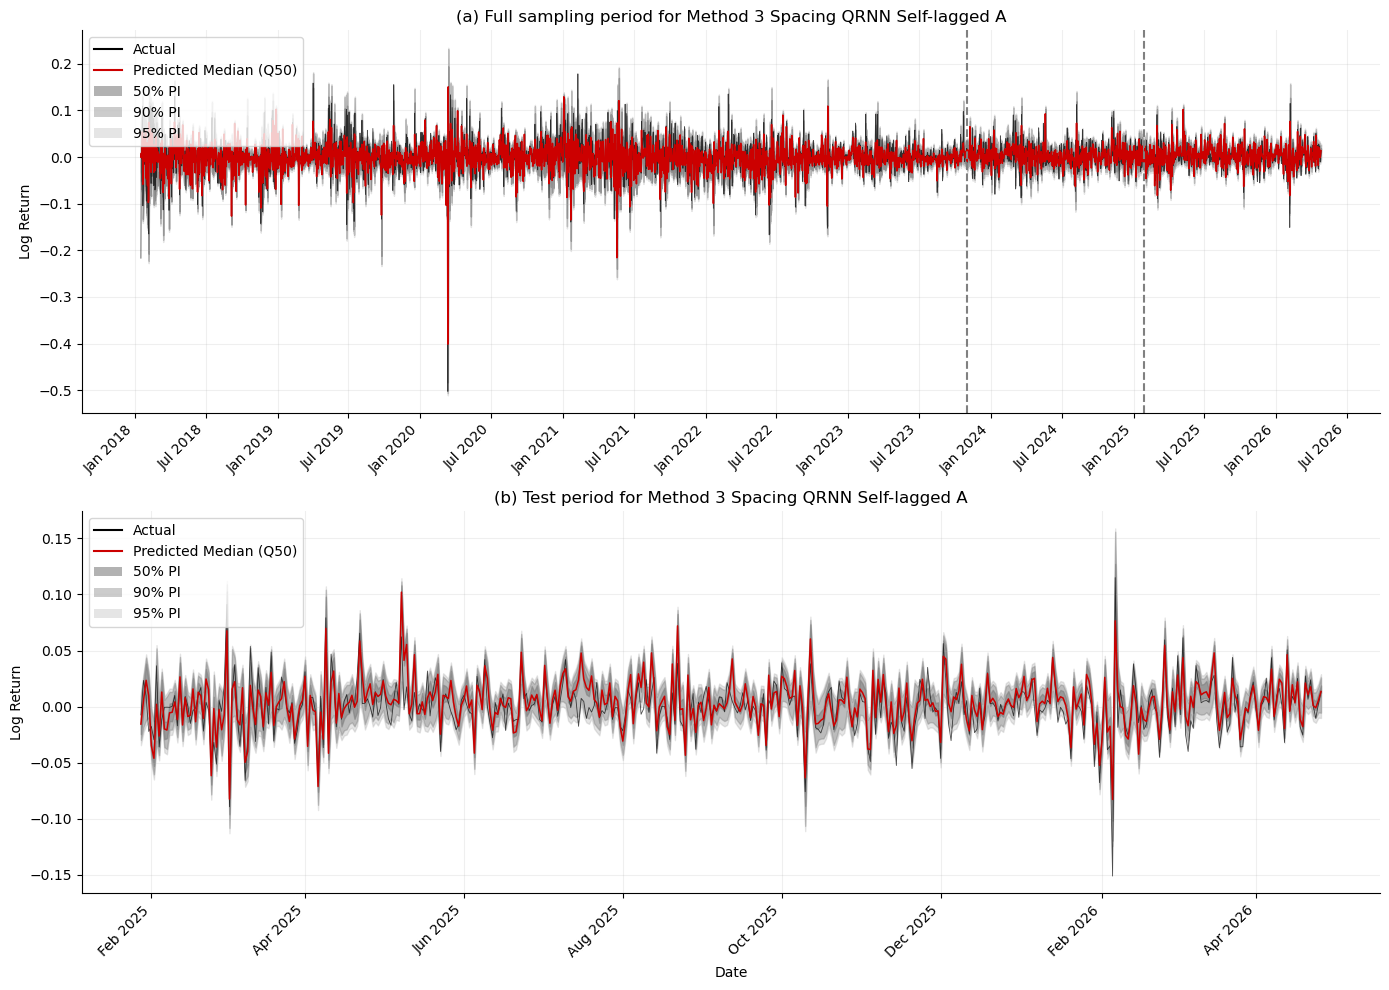

Plot saved to method3_spacing_qrnn_a_self_predictions.png

TEST METRICS -- METHOD 3 SPACING QRNN A SELF-LAGGED
 alpha       NLL  Hit_Rate      HRE
 0.025 -2.456597  0.068282 0.043282
 0.050 -2.479288  0.136564 0.086564
 0.250 -2.654464  0.480176 0.230176
 0.500 -2.789696  0.640969 0.140969
 0.750 -2.809670  0.839207 0.089207
 0.950 -2.642115  0.958150 0.008150
 0.975 -2.576475  0.982379 0.007379

Average NLL: -2.629758
Average HRE: 0.086532

CROSSOVER ANALYSIS -- FINAL METHOD 3 FORECASTS
(0.025, 0.050): 0 (0.00%) <-- TAIL
(0.050, 0.250): 0 (0.00%)
(0.250, 0.500): 0 (0.00%)
(0.500, 0.750): 0 (0.00%)
(0.750, 0.950): 0 (0.00%)
(0.950, 0.975): 0 (0.00%) <-- TAIL

Total violations: 0 (0.00%)
Tail violations: 0 (0.00%)

LEARNED SPACING DIAGNOSTICS -- TEST PERIOD
 alpha  reference_alpha direction  Mean_Delta  Minimum_Delta  Maximum_Delta  Delta_Std  Near_Zero_Count  Near_Zero_Rate
 0.750             0.50     upper    0.008292       0.002329       0.050663   0.003410                0          

In [40]:
import numpy as np
import pandas as pd
import torch
import matplotlib.pyplot as plt
import matplotlib.dates as mdates

from matplotlib.lines import Line2D
from matplotlib.patches import Patch


# ============================================================
# PLOT AND EVALUATE METHOD 3 -- SPECIFICATION 1
# QRNN A SELF-LAGGED WITH LEARNED POSITIVE SPACING
# ============================================================

m3_plot_alpha_levels = [
    0.025, 0.050, 0.250, 0.500, 0.750, 0.950, 0.975
]

m3_plot_estimation_order = [
    0.500, 0.750, 0.950, 0.975, 0.250, 0.050, 0.025
]

m3_plot_reference_level = {
    0.500: None,
    0.750: 0.500,
    0.950: 0.750,
    0.975: 0.950,
    0.250: 0.500,
    0.050: 0.250,
    0.025: 0.050,
}

m3_plot_direction = {
    0.500: None,
    0.750: 'upper',
    0.950: 'upper',
    0.975: 'upper',
    0.250: 'lower',
    0.050: 'lower',
    0.025: 'lower',
}


# ============================================================
# Reload selected models if they are not currently in memory
# ============================================================

if 'm3_spacing_final_models' not in globals():
    m3_plot_checkpoint = torch.load(
        'method3_spacing_qrnn_a_self_best.pt',
        map_location='cpu',
        weights_only=False,
    )

    m3_spacing_final_models = {}

    for alpha in m3_plot_checkpoint['estimation_order']:
        model = M3SpacingQRNNSelfA(
            input_dim=X_train.shape[1],
            config=m3_plot_checkpoint['configs'][alpha],
            direction=m3_plot_checkpoint['direction'][alpha],
        )
        model.load_state_dict(
            m3_plot_checkpoint['model_state_dicts'][alpha]
        )
        model.eval()
        m3_spacing_final_models[alpha] = model


# ============================================================
# Generate full-sample predictions sequentially
# ============================================================

def m3_plot_generate_predictions(models, y, X):
    predictions = {}
    raw_outputs = {}
    learned_deltas = {}
    sigma_values = {}

    for alpha in m3_plot_estimation_order:
        reference_alpha = m3_plot_reference_level[alpha]
        reference = (
            None
            if reference_alpha is None
            else predictions[reference_alpha]
        )

        model = models[alpha]
        model.eval()

        with torch.no_grad():
            prediction, _, raw_output, delta, sigma = model(
                y, X, reference
            )

        predictions[alpha] = prediction.detach()
        raw_outputs[alpha] = raw_output.detach()
        learned_deltas[alpha] = (
            None if delta is None else delta.detach()
        )
        sigma_values[alpha] = sigma.detach()

    return predictions, raw_outputs, learned_deltas, sigma_values


m3_plot_X_all = torch.tensor(
    df[feature_cols].values,
    dtype=torch.float32,
)

m3_plot_y_all = torch.tensor(
    df['log_return'].values,
    dtype=torch.float32,
)

(
    m3_plot_all_predictions,
    m3_plot_all_raw_outputs,
    m3_plot_all_deltas,
    m3_plot_all_sigma,
) = m3_plot_generate_predictions(
    m3_spacing_final_models,
    m3_plot_y_all,
    m3_plot_X_all,
)

m3_plot_all_predictions_np = {
    alpha: prediction.cpu().numpy()
    for alpha, prediction in m3_plot_all_predictions.items()
}

m3_plot_test_start = len(train_df) + len(val_df)
m3_plot_all_dates = df.index
m3_plot_test_dates = test_df.index
m3_plot_actual_all = df['log_return'].values
m3_plot_actual_test = test_df['log_return'].values


# ============================================================
# Two-panel forecast plot
# ============================================================

fig, axes = plt.subplots(2, 1, figsize=(14, 10))

actual_color = '#000000'
median_color = '#CC0000'
interval_color = '#808080'


def m3_plot_draw_panel(ax, dates, actual, test_start=None):
    def values(alpha):
        series = m3_plot_all_predictions_np[alpha]
        return series if test_start is None else series[test_start:]

    ax.plot(
        dates,
        actual,
        color=actual_color,
        linewidth=0.6,
        alpha=0.7,
    )
    ax.plot(
        dates,
        values(0.500),
        color=median_color,
        linewidth=1.1,
    )
    ax.fill_between(
        dates,
        values(0.025),
        values(0.975),
        color=interval_color,
        alpha=0.20,
    )
    ax.fill_between(
        dates,
        values(0.050),
        values(0.950),
        color=interval_color,
        alpha=0.40,
    )
    ax.fill_between(
        dates,
        values(0.250),
        values(0.750),
        color=interval_color,
        alpha=0.60,
    )
    ax.set_ylabel('Log Return')
    ax.grid(True, alpha=0.2)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)


m3_plot_draw_panel(
    axes[0],
    m3_plot_all_dates,
    m3_plot_actual_all,
)
axes[0].axvline(train_df.index[-1], color='gray', linestyle='--')
axes[0].axvline(val_df.index[-1], color='gray', linestyle='--')
axes[0].set_title(
    '(a) Full sampling period for Method 3 Spacing QRNN Self-lagged A'
)
axes[0].xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
axes[0].xaxis.set_major_locator(mdates.MonthLocator(interval=6))

m3_plot_draw_panel(
    axes[1],
    m3_plot_test_dates,
    m3_plot_actual_test,
    test_start=m3_plot_test_start,
)
axes[1].set_title(
    '(b) Test period for Method 3 Spacing QRNN Self-lagged A'
)
axes[1].set_xlabel('Date')
axes[1].xaxis.set_major_formatter(mdates.DateFormatter('%b %Y'))
axes[1].xaxis.set_major_locator(mdates.MonthLocator(interval=2))

legend_elements = [
    Line2D([0], [0], color=actual_color, label='Actual'),
    Line2D([0], [0], color=median_color, label='Predicted Median (Q50)'),
    Patch(facecolor=interval_color, alpha=0.60, label='50% PI'),
    Patch(facecolor=interval_color, alpha=0.40, label='90% PI'),
    Patch(facecolor=interval_color, alpha=0.20, label='95% PI'),
]

for axis in axes:
    axis.legend(handles=legend_elements, loc='upper left')
    plt.setp(axis.xaxis.get_majorticklabels(), rotation=45, ha='right')

plt.tight_layout()

m3_plot_filename = 'method3_spacing_qrnn_a_self_predictions.png'
plt.savefig(m3_plot_filename, dpi=300, bbox_inches='tight')
plt.show()
plt.close()

print(f'Plot saved to {m3_plot_filename}')


# ============================================================
# Test NLL, hit rate, and HRE
# ============================================================

m3_plot_y_test = m3_plot_y_all[m3_plot_test_start:]
m3_plot_metric_rows = []

for alpha in m3_plot_alpha_levels:
    q_test = m3_plot_all_predictions[alpha][m3_plot_test_start:]
    sigma = m3_plot_all_sigma[alpha]

    nll = m3_spacing_qrnn_loss(
        m3_plot_y_test, q_test, sigma, alpha
    ).item()
    hit_rate = (m3_plot_y_test <= q_test).float().mean().item()
    hre = abs(hit_rate - alpha)

    m3_plot_metric_rows.append({
        'alpha': alpha,
        'NLL': nll,
        'Hit_Rate': hit_rate,
        'HRE': hre,
    })

m3_plot_metrics_df = pd.DataFrame(m3_plot_metric_rows)
m3_plot_average_nll = m3_plot_metrics_df['NLL'].mean()
m3_plot_average_hre = m3_plot_metrics_df['HRE'].mean()

print('\n' + '=' * 72)
print('TEST METRICS -- METHOD 3 SPACING QRNN A SELF-LAGGED')
print('=' * 72)
print(m3_plot_metrics_df.to_string(index=False))
print(f'\nAverage NLL: {m3_plot_average_nll:.6f}')
print(f'Average HRE: {m3_plot_average_hre:.6f}')


# ============================================================
# Crossover analysis
# ============================================================

m3_plot_pairs = list(zip(
    m3_plot_alpha_levels[:-1],
    m3_plot_alpha_levels[1:],
))
m3_plot_tail_pairs = [(0.025, 0.050), (0.950, 0.975)]
m3_plot_crossover_rows = []
m3_plot_total_violations = 0
m3_plot_tail_violations = 0

print('\n' + '=' * 72)
print('CROSSOVER ANALYSIS -- FINAL METHOD 3 FORECASTS')
print('=' * 72)

for lower, upper in m3_plot_pairs:
    lower_test = m3_plot_all_predictions[lower][m3_plot_test_start:]
    upper_test = m3_plot_all_predictions[upper][m3_plot_test_start:]
    violations = int((lower_test > upper_test).sum().item())
    rate = violations / len(lower_test)

    m3_plot_total_violations += violations
    if (lower, upper) in m3_plot_tail_pairs:
        m3_plot_tail_violations += violations

    m3_plot_crossover_rows.append({
        'Lower': lower,
        'Upper': upper,
        'Violations': violations,
        'Rate': rate,
    })

    tail_label = (
        ' <-- TAIL' if (lower, upper) in m3_plot_tail_pairs else ''
    )
    print(
        f'({lower:.3f}, {upper:.3f}): '
        f'{violations} ({100 * rate:.2f}%){tail_label}'
    )

m3_plot_total_rate = m3_plot_total_violations / (
    len(m3_plot_y_test) * len(m3_plot_pairs)
)
m3_plot_tail_rate = m3_plot_tail_violations / (
    len(m3_plot_y_test) * len(m3_plot_tail_pairs)
)

print(
    f'\nTotal violations: {m3_plot_total_violations} '
    f'({100 * m3_plot_total_rate:.2f}%)'
)
print(
    f'Tail violations: {m3_plot_tail_violations} '
    f'({100 * m3_plot_tail_rate:.2f}%)'
)


# ============================================================
# Learned-spacing diagnostics
# ============================================================

m3_plot_delta_rows = []

for alpha in m3_plot_estimation_order:
    if alpha == 0.500:
        continue

    delta_test = m3_plot_all_deltas[alpha][m3_plot_test_start:]

    m3_plot_delta_rows.append({
        'alpha': alpha,
        'reference_alpha': m3_plot_reference_level[alpha],
        'direction': m3_plot_direction[alpha],
        'Mean_Delta': delta_test.mean().item(),
        'Minimum_Delta': delta_test.min().item(),
        'Maximum_Delta': delta_test.max().item(),
        'Delta_Std': delta_test.std().item(),
        'Near_Zero_Count': int((delta_test <= 1e-5).sum().item()),
        'Near_Zero_Rate': (delta_test <= 1e-5).float().mean().item(),
    })

m3_plot_delta_df = pd.DataFrame(m3_plot_delta_rows)

print('\n' + '=' * 72)
print('LEARNED SPACING DIAGNOSTICS -- TEST PERIOD')
print('=' * 72)
print(m3_plot_delta_df.to_string(index=False))


# ============================================================
# Detailed predictions by test date
# ============================================================

m3_plot_prediction_df = pd.DataFrame({
    'Date': pd.to_datetime(m3_plot_test_dates),
    'Actual': m3_plot_actual_test,
})

for alpha in m3_plot_alpha_levels:
    m3_plot_prediction_df[f'Q_{alpha:.3f}'] = (
        m3_plot_all_predictions_np[alpha][m3_plot_test_start:]
    )

for lower, upper in m3_plot_pairs:
    m3_plot_prediction_df[
        f'Gap_{lower:.3f}_{upper:.3f}'
    ] = (
        m3_plot_prediction_df[f'Q_{upper:.3f}']
        - m3_plot_prediction_df[f'Q_{lower:.3f}']
    )


# ============================================================
# Save outputs
# ============================================================

m3_plot_metrics_df.to_csv(
    'method3_spacing_qrnn_a_self_test_metrics.csv',
    index=False,
)
pd.DataFrame(m3_plot_crossover_rows).to_csv(
    'method3_spacing_qrnn_a_self_crossover.csv',
    index=False,
)
m3_plot_delta_df.to_csv(
    'method3_spacing_qrnn_a_self_delta_summary.csv',
    index=False,
)
m3_plot_prediction_df.to_csv(
    'method3_spacing_qrnn_a_self_test_predictions.csv',
    index=False,
)

print('\nSaved Method 3 outputs:')
print('  method3_spacing_qrnn_a_self_predictions.png')
print('  method3_spacing_qrnn_a_self_test_metrics.csv')
print('  method3_spacing_qrnn_a_self_crossover.csv')
print('  method3_spacing_qrnn_a_self_delta_summary.csv')
print('  method3_spacing_qrnn_a_self_test_predictions.csv')
